## BFS

In [63]:
import matplotlib.pyplot as plt
import networkx as nx

def evaluacion(iteracion, G, color, dist, pred, Q):
    plt.figure(figsize=(10, 8))

    # ---- Convertir G a grafo de networkx ----
    G_nx = nx.DiGraph()
    for u in G:
        for v in G[u]:
            G_nx.add_edge(u, v)

    # ---- Layout estable ----
    pos = nx.spring_layout(G_nx, seed=10)

    # ---- Colores BFS ----
    color_map = {
        "White": "white",
        "Gray": "silver",
        "Black": "black"
    }

    node_colors = [
        color_map.get(color.get(n, "White"), "lightgray")
        for n in G_nx.nodes()
    ]

    # ---- Etiquetas de nodo: nombre + distancia ----
    def dist_text(x):
        if x is None: return "?"
        if x == float("inf"): return "∞"
        return str(x)

    labels = {n: f"{n}\nd={dist_text(dist.get(n))}" for n in G_nx.nodes()}

    # ---- Dibujar nodos ----
    nx.draw_networkx_nodes(
        G_nx, pos,
        node_color=node_colors,
        node_size=1100,
        edgecolors='black'
    )

    # ---- Aristas normales ----
    nx.draw_networkx_edges(
        G_nx, pos,
        arrows=True,
        arrowstyle='->',
        arrowsize=15,
        width=2,
        min_source_margin=15,
        min_target_margin=15
    )

    # ---- Aristas del árbol BFS (predecesores) ----
    pred_edges = []
    for v in pred:
        u = pred[v]
        if u is not None:
            pred_edges.append((u, v))

    nx.draw_networkx_edges(
        G_nx, pos,
        edgelist=pred_edges,
        style='dashed',
        width=3,
        edge_color='red',
        arrows=True,
        arrowstyle='->',
        arrowsize=20,
        min_source_margin=15,
        min_target_margin=15
    )

    # ---- Etiquetas ----
    nx.draw_networkx_labels(
        G_nx, pos,
        labels=labels,
        font_color="darkgoldenrod",
        font_size=10
    )

    # ---- Título ----
    plt.title(f"Evaluación — Iteración {iteracion}", fontsize=14)

    # ---- TABLA DE DISTANCIAS Y PREDECESORES ----

    nodes = list(dist.keys())

    column_labels = nodes
    row_labels = ["Distancia", "Predecesor"]

    cell_text = [
        [dist_text(dist[n]) for n in nodes],
        [pred[n] if pred[n] is not None else "-" for n in nodes]
    ]

    table = plt.table(
        cellText=cell_text,
        colLabels=column_labels,
        rowLabels=row_labels,
        loc='bottom',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.3)

    # Ajustes para que la tabla no pise el grafo
    plt.subplots_adjust(left=0.08, bottom=0.28)

    plt.axis("off")
    plt.tight_layout()
    print("COLA (FIFO):")
    print("  ", list(Q))
    plt.show()
    


In [64]:
def evaluacion0(ite, G, color, dist, pred, Q):

    print("\n" + "="*60)
    print(f"                ITERACIÓN {ite}")
    print("="*60 + "\n")

    # # ---- Grafo con adyacencias ----
    # print("GRAFO (lista de adyacencia):")
    # for u in G:
    #     print(f"  {u} -> {G[u]}")
    # print("\n" + "-"*60)

    # ---- Tabla de estados ----
    print("ESTADOS DE LOS NODOS:\n")
    print(f"{'Nodo':<8} {'Color':<10} {'Distancia':<12} {'Predecesor':<12}")
    print("-"*60)

    nodos = sorted(G.keys())

    for u in nodos:
        col = str(color.get(u, "-"))
        d   = str(dist.get(u, "-"))
        p   = str(pred.get(u, "-"))
        print(f"{u:<8} {col:<10} {d:<12} {p:<12}")

    print("\n" + "-"*60)

    # ---- Cola ----
    print("COLA (FIFO):")
    print("  ", list(Q))

    print("="*60 + "\n")


In [65]:
from collections import deque

def BFS(G, s):
    # Inicialización
    color = {}      # Cu (White, Gray, Black)
    d = {}          # du (distancia)
    pi = {}         # πu (predecesor)

    for v in G:
        if v != s:
            color[v] = "White"
            d[v] = float("inf")
            pi[v] = None

    # Inicializar nodo fuente
    color[s] = "Gray"
    d[s] = 0
    pi[s] = None

    Q = deque([s])  # Cola FIFO

    evaluacion(0, G, color, d, pi, Q)

    # Bucle principal BFS
    ite = 1
    while Q:
        u = Q[0]   # HEAD(Q)
        for v in G[u]:  # Adj(u)
            if color[v] == "White":
                color[v] = "Gray"
                d[v] = d[u] + 1
                pi[v] = u
                Q.append(v)  # ENQUEUE(Q, v)

        Q.popleft()      # DEQUEUE(Q)
        color[u] = "Black"

        evaluacion(ite, G, color, d, pi, Q)
        ite += 1

        

    return color, d, pi



COLA (FIFO):
   ['u4']


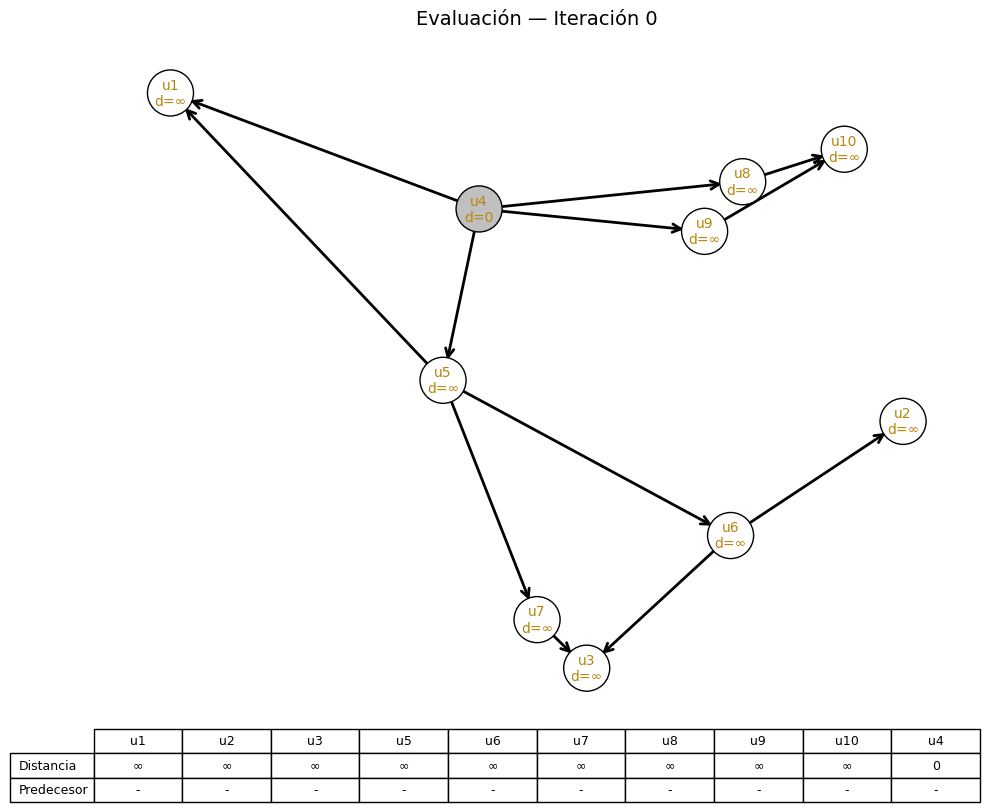

COLA (FIFO):
   ['u1', 'u5', 'u8', 'u9']


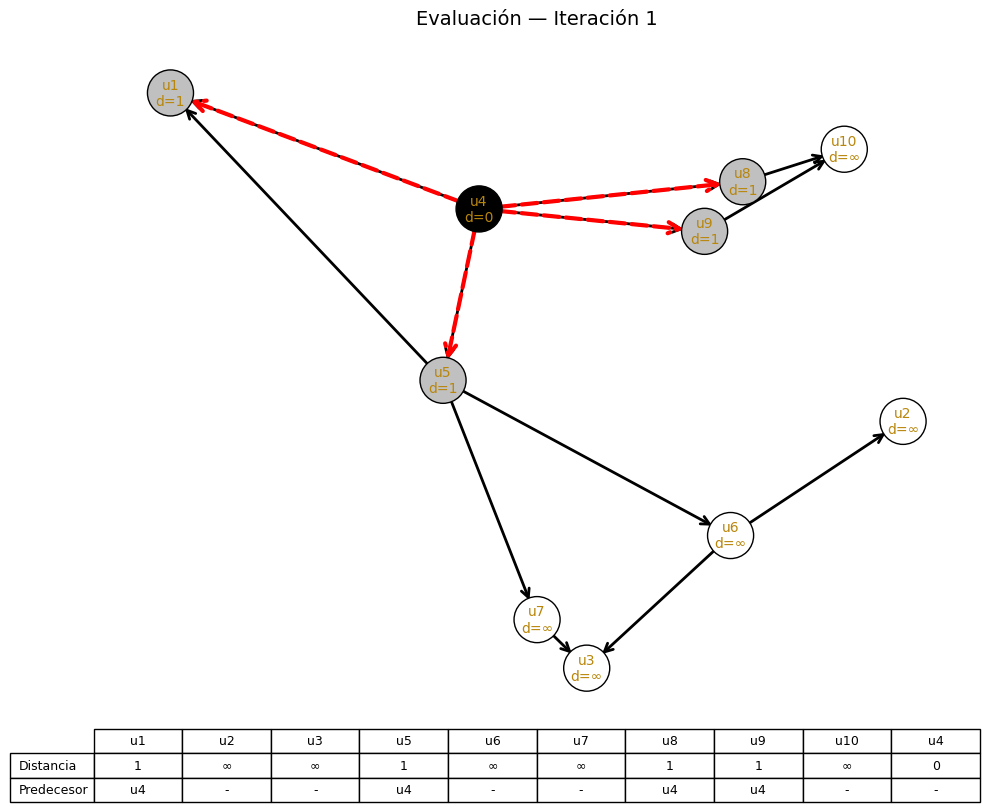

COLA (FIFO):
   ['u5', 'u8', 'u9']


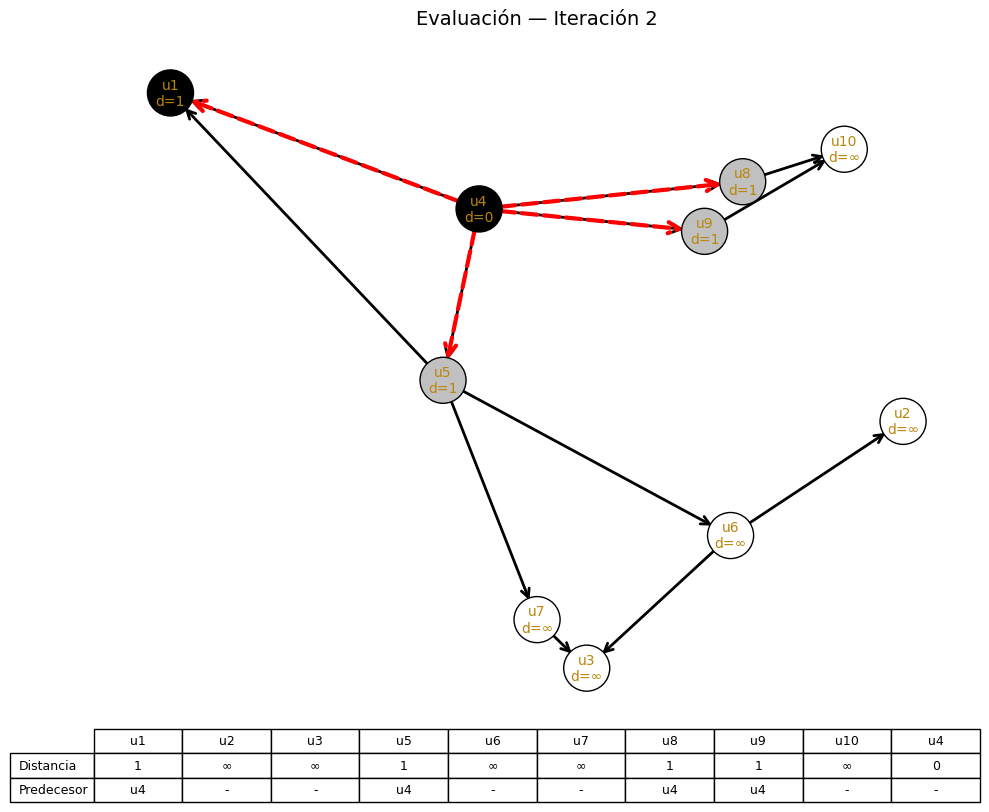

COLA (FIFO):
   ['u8', 'u9', 'u6', 'u7']


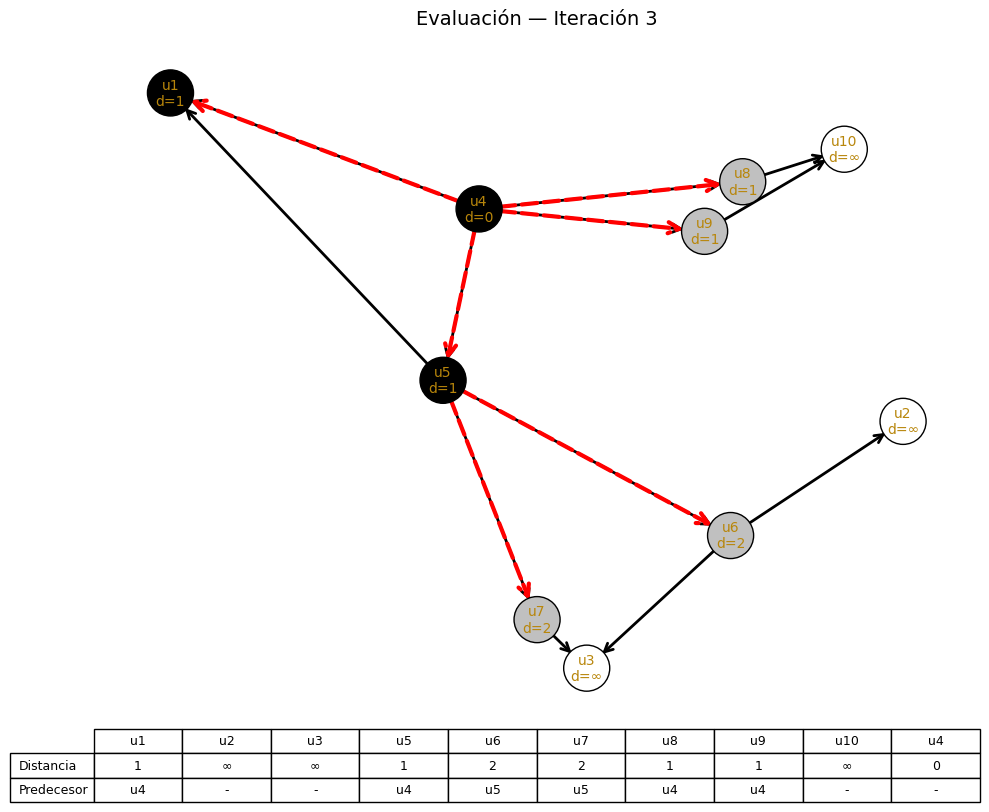

COLA (FIFO):
   ['u9', 'u6', 'u7', 'u10']


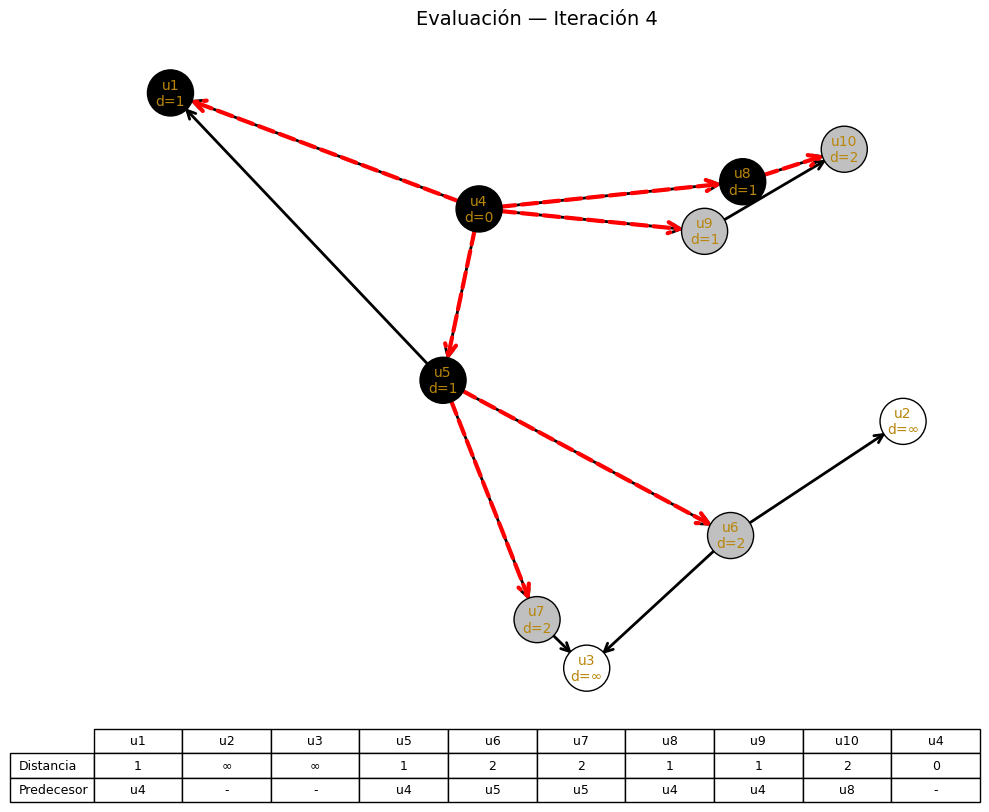

COLA (FIFO):
   ['u6', 'u7', 'u10']


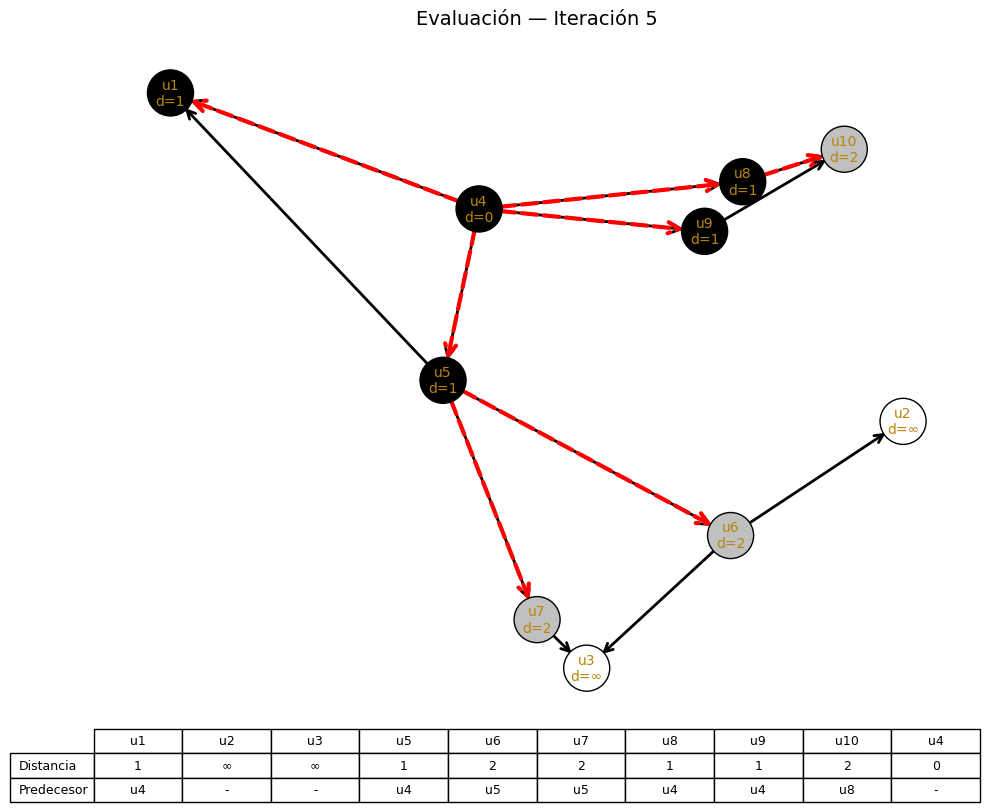

COLA (FIFO):
   ['u7', 'u10', 'u2', 'u3']


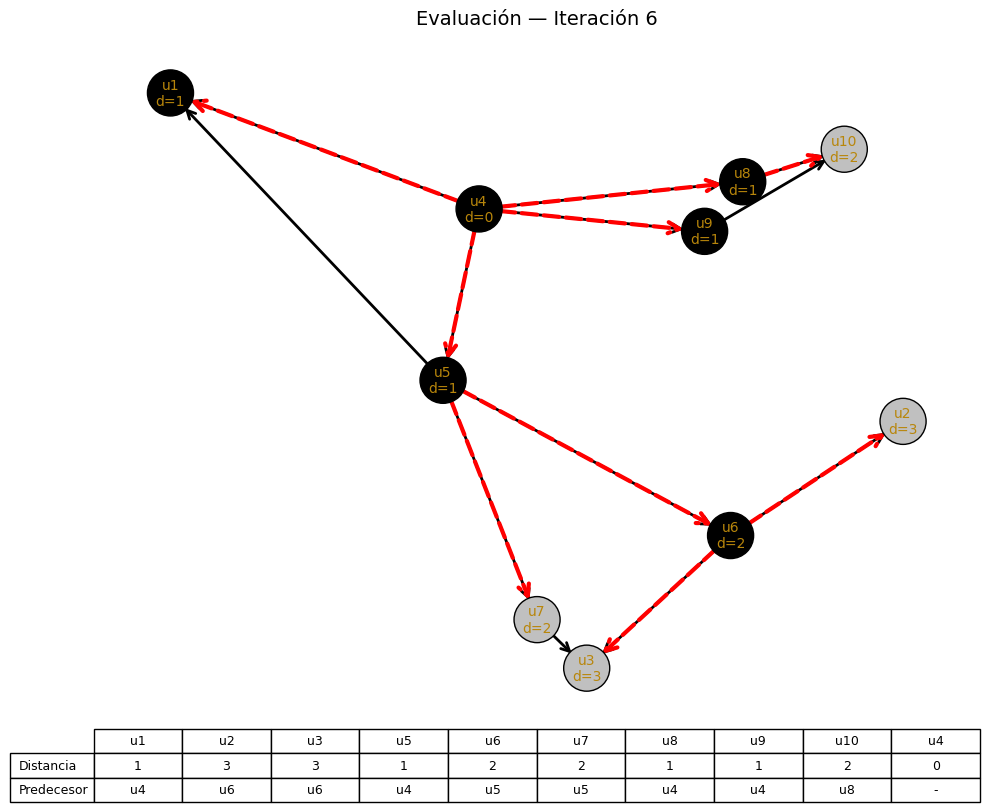

COLA (FIFO):
   ['u10', 'u2', 'u3']


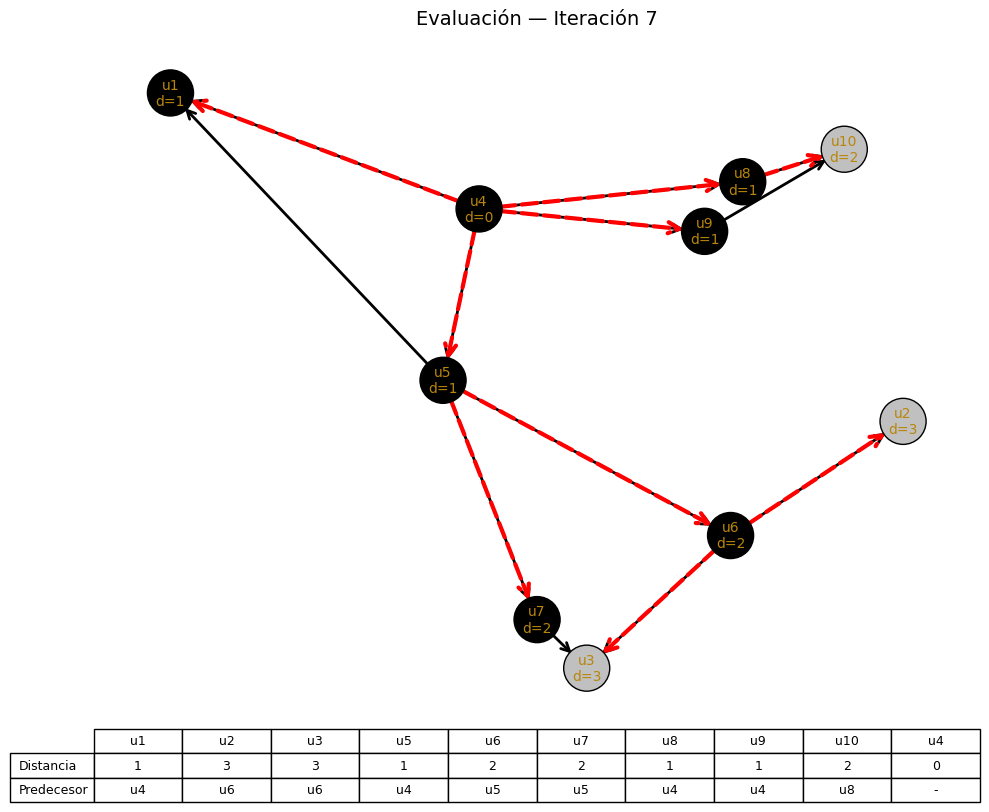

COLA (FIFO):
   ['u2', 'u3']


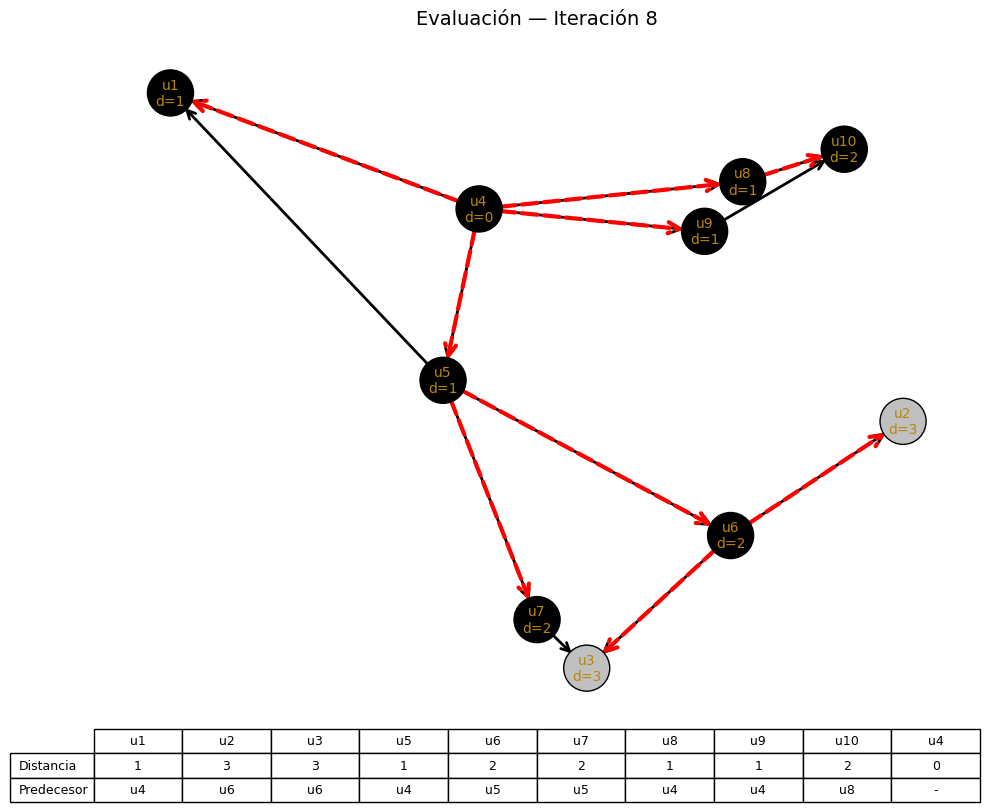

COLA (FIFO):
   ['u3']


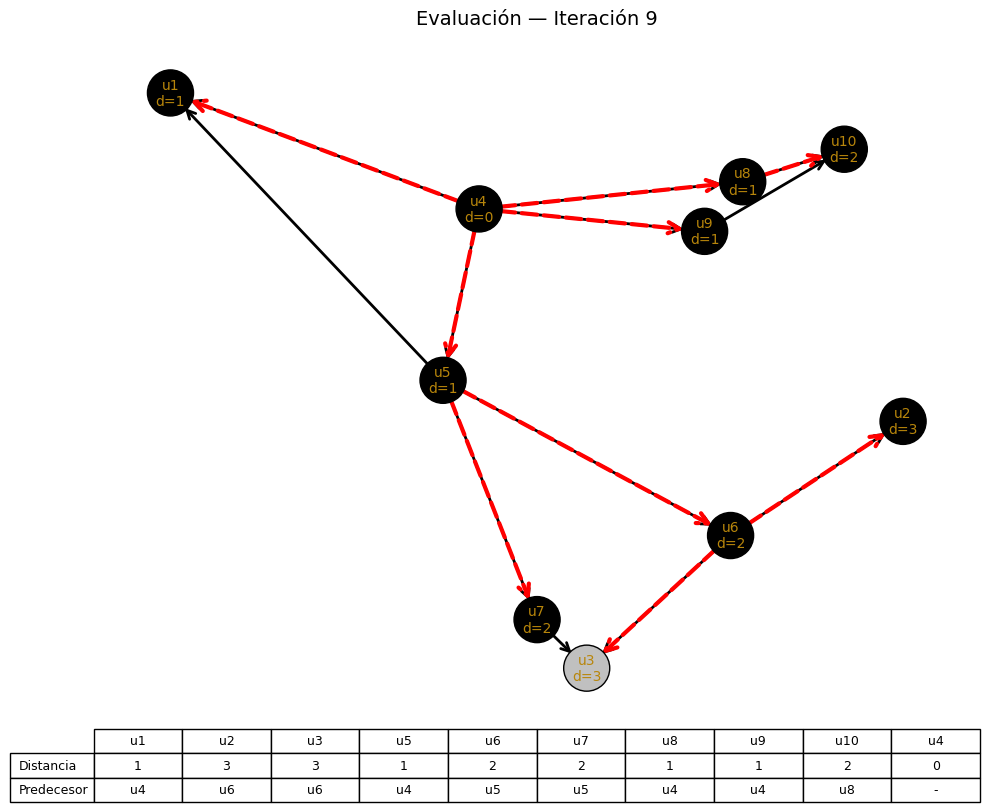

COLA (FIFO):
   []


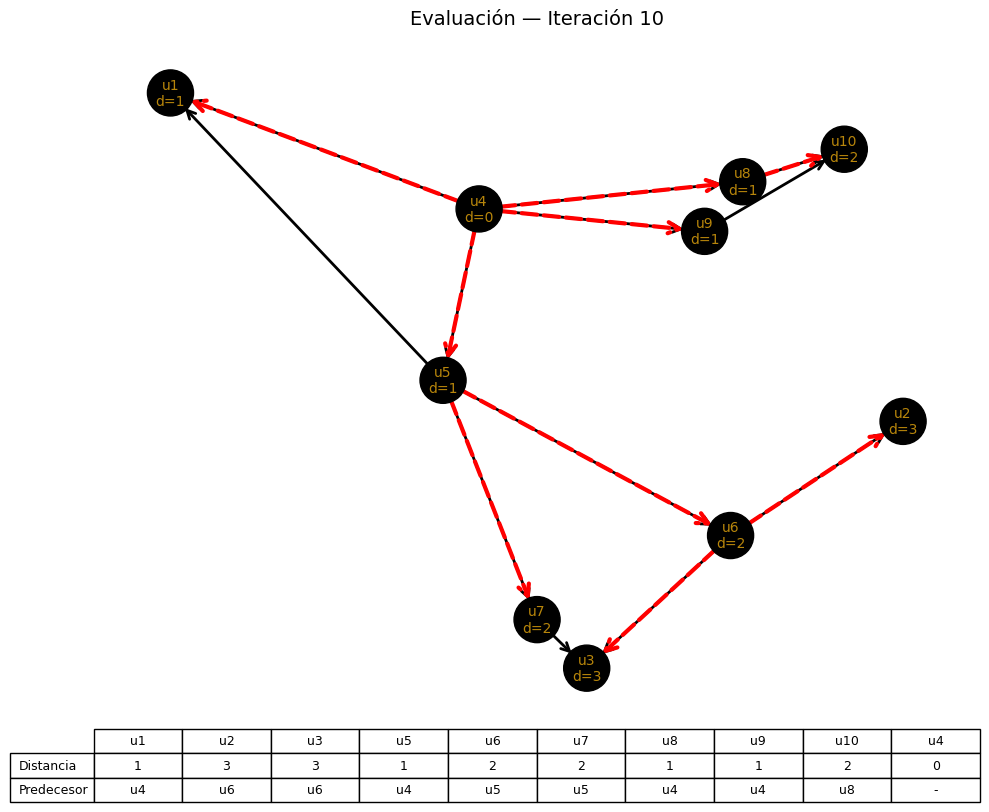

In [66]:
G = {
    "u1": [],
    "u2": [],
    "u3": [],
    "u4": ["u1","u5","u8","u9"],
    "u5": ["u1","u6","u7"],
    "u6": ["u2", "u3"],
    "u7": ["u3"],
    "u8": ["u10"],
    "u9": ["u10"],
    "u10": []
}

# Ejecutar BFS desde A
color, dist, pred = BFS(G, "u4")


## DFS

In [110]:
import matplotlib.pyplot as plt
import networkx as nx

def evaluacion_dfs(iteracion, G, C, pi, d, f):
    plt.figure(figsize=(10, 8))

    # ---- Convertir G a grafo de networkx ----
    G_nx = nx.DiGraph()
    for u in G:
        for v in G[u]:
            G_nx.add_edge(u, v)

    # ---- Layout estable ----
    pos = nx.spring_layout(G_nx, seed=10)
    print(f"pos: {pos}")


    # ---- Colores DFS ----
    color_map = {
        "White": "white",
        "Gray": "silver",
        "Black": "black"
    }

    node_colors = [
        color_map.get(C.get(n, "White"), "lightgray")
        for n in G_nx.nodes()
    ]

    def tfmt_from(mapping, node):
        """
        Devuelve una representación segura y legible del valor mapping[node].
        - Si la clave no existe o es None -> "?"
        - Si es float('inf') -> "∞"
        - Si es 0 (valor inicial) -> "-"  (opcional, cambia según prefieras)
        - En otro caso -> str(valor)
        """
        v = mapping.get(node, None)
        if v is None:
            return "?"
        try:
            # detectar infinito
            if v == float("inf"):
                return "∞"
        except Exception:
            pass
        # Si consideras que 0 significa "no asignado", muestra "-", si no, muestra "0"
        if v == 0:
            return "-"        # <- cambia a "0" si prefieres ver el cero
        return str(v)

    labels = {
        n: f"{n}\n({tfmt_from(d, n)},{tfmt_from(f, n)})"
        for n in G_nx.nodes()
    }

    # ---- Dibujar nodos ----
    nx.draw_networkx_nodes(
        G_nx, pos,
        node_color=node_colors,
        node_size=1100,
        edgecolors='black'
    )

    # ---- Aristas normales ----
    nx.draw_networkx_edges(
        G_nx, pos,
        arrows=True,
        arrowstyle='->',
        arrowsize=15,
        width=2,
        min_source_margin=15,
        min_target_margin=15
    )

    # ---- Aristas del árbol DFS (predecesores) ----
    tree_edges = []
    for v in pi:
        u = pi[v]
        if u is not None:
            tree_edges.append((u, v))

    nx.draw_networkx_edges(
        G_nx, pos,
        edgelist=tree_edges,
        style='dashed',
        width=3,
        edge_color='red',
        arrows=True,
        arrowstyle='->',
        arrowsize=20,
        min_source_margin=15,
        min_target_margin=15
    )

    # ---- Etiquetas ----
    nx.draw_networkx_labels(
        G_nx, pos,
        labels=labels,
        font_color="darkgoldenrod",
        font_size=10
    )

    # ---- Título ----
    plt.title(f"Evaluación DFS — Iteración {iteracion}", fontsize=14)

        # ---- TABLA DE π, d y f ----

    nodes = list(C.keys())
    column_labels = nodes
    row_labels = ["π", "d", "f"]

    cell_text = [
        [pi.get(n, "-") if pi.get(n) is not None else "-" for n in nodes],
        [tfmt_from(d, n) for n in nodes],
        [tfmt_from(f, n) for n in nodes]
    ]

    table = plt.table(
        cellText=cell_text,
        colLabels=column_labels,
        rowLabels=row_labels,
        loc='bottom',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.3)

    # Ajustes para que la tabla no pise el grafo
    plt.subplots_adjust(left=0.08, bottom=0.28)

    plt.axis("off")
    plt.tight_layout()
    plt.show()



In [111]:
import matplotlib.pyplot as plt
import networkx as nx

def evaluacion_dfs_edges(iteracion, G, C, pi, d, f):
    plt.figure(figsize=(10, 8))

    # ============================================================
    #   CONVERTIR A GRAFO DE NETWORKX
    # ============================================================
    G_nx = nx.DiGraph()
    for u in G:
        for v in G[u]:
            G_nx.add_edge(u, v)

    pos = nx.spring_layout(G_nx, seed=10)

    # ============================================================
    #   COLORES DE LOS NODOS SEGÚN DFS
    # ============================================================
    color_map = {
        "White": "lightgray",
        "Gray": "orange",
        "Black": "black"
    }

    node_colors = [
        color_map.get(C.get(n, "White"), "lightgray")
        for n in G_nx.nodes()
    ]

    # ============================================================
    #   FORMATEO DE d y f
    # ============================================================
    def tfmt_from(mapping, node):
        v = mapping.get(node, None)
        if v is None:
            return "?"
        if v == float("inf"):
            return "∞"
        if v == 0:
            return "-"
        return str(v)

    labels = {
        n: f"{n}\n({tfmt_from(d,n)},{tfmt_from(f,n)})"
        for n in G_nx.nodes()
    }

    # ============================================================
    #   CLASIFICACIÓN DE ARISTAS SEGÚN d(u), f(u)
    # ============================================================
    tree_edges = []
    forward_edges = []
    back_edges = []
    cross_edges = []

    for u in G:
        for v in G[u]:
            du, fu = d[u], f[u]
            dv, fv = d[v], f[v]

            # ---- Tree edge ----
            if pi.get(v) == u:
                tree_edges.append((u, v))
            # ---- Forward edge: du < dv < fv < fu ----
            elif du < dv and fv < fu:
                forward_edges.append((u, v))
            # ---- Back edge: dv < du < fu < fv ----
            elif dv < du and fu < fv:
                back_edges.append((u, v))
            # ---- Cross edge: dv < fv < du < fu ----
            elif dv < fv and fv < du and du < fu:
                cross_edges.append((u, v))

    # ============================================================
    #   DIBUJAR NODOS
    # ============================================================
    nx.draw_networkx_nodes(
        G_nx, pos,
        node_color=node_colors,
        node_size=1100,
        edgecolors='black'
    )

    # ============================================================
    #   DIBUJAR ARISTAS CLASIFICADAS
    # ============================================================
    nx.draw_networkx_edges(G_nx, pos,
        edgelist=tree_edges,
        edge_color="red", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_edges(G_nx, pos,
        edgelist=forward_edges,
        edge_color="green", style="dashed", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_edges(G_nx, pos,
        edgelist=back_edges,
        edge_color="blue", style="dotted", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_edges(G_nx, pos,
        edgelist=cross_edges,
        edge_color="purple", style="dashdot", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    # ============================================================
    #   ETIQUETAS
    # ============================================================
    nx.draw_networkx_labels(
        G_nx, pos, labels=labels,
        font_color="white", font_size=10
    )

    # ============================================================
    #   TABLA π, d, f
    # ============================================================
    nodes = list(C.keys())
    column_labels = nodes
    row_labels = ["π", "d", "f"]

    cell_text = [
        [pi.get(n, "-") if pi.get(n) is not None else "-" for n in nodes],
        [tfmt_from(d, n) for n in nodes],
        [tfmt_from(f, n) for n in nodes]
    ]

    table = plt.table(
        cellText=cell_text,
        colLabels=column_labels,
        rowLabels=row_labels,
        loc='bottom',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.3)

    plt.subplots_adjust(left=0.08, bottom=0.28)

    plt.axis("off")
    plt.title(f"Evaluación DFS — Iteración {iteracion}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [112]:
def DFS(G):
    """
    G es un diccionario: {u: [v1, v2, ...]}
    """

    global t
    t = 0

    # Inicialización
    C = {}   # colores
    pi = {}  # predecesores
    d = {}   # tiempo de descubrimiento
    f = {}   # tiempo de finalización

    for u in G:
        C[u] = "White"
        pi[u] = None

    evaluacion_dfs(t, G, C, pi, d, f)
    # Recorridos DFS
    
    for u in G:
        if C[u] == "White":
            DFS_VISIT(G, u, C, pi, d, f)    

    evaluacion_dfs_edges("final", G, C, pi, d, f)
    return C, pi, d, f


def DFS_VISIT(G, u, C, pi, d, f):
    global t

    C[u] = "Gray"
    t = t + 1
    d[u] = t
    evaluacion_dfs(t, G, C, pi, d, f)
    for v in G[u]:
        if C[v] == "White":
            pi[v] = u
            DFS_VISIT(G, v, C, pi, d, f)
    C[u] = "Black"
    t = t + 1
    f[u] = t
    evaluacion_dfs(t, G, C, pi, d, f)



pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


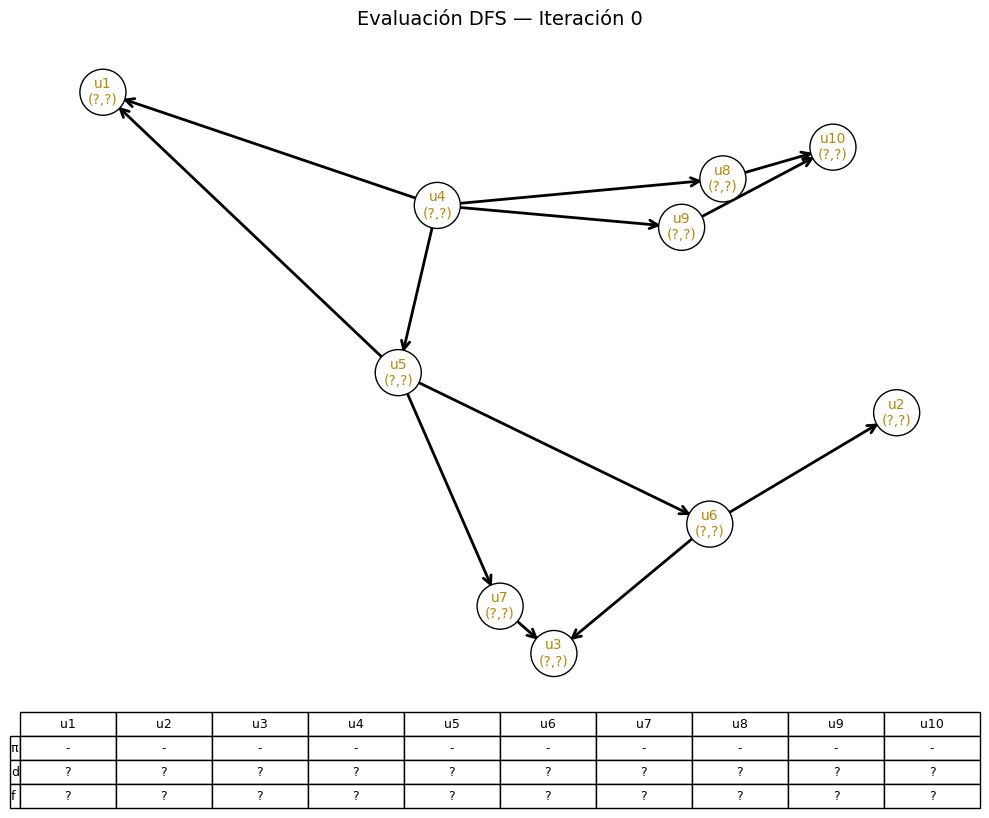

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


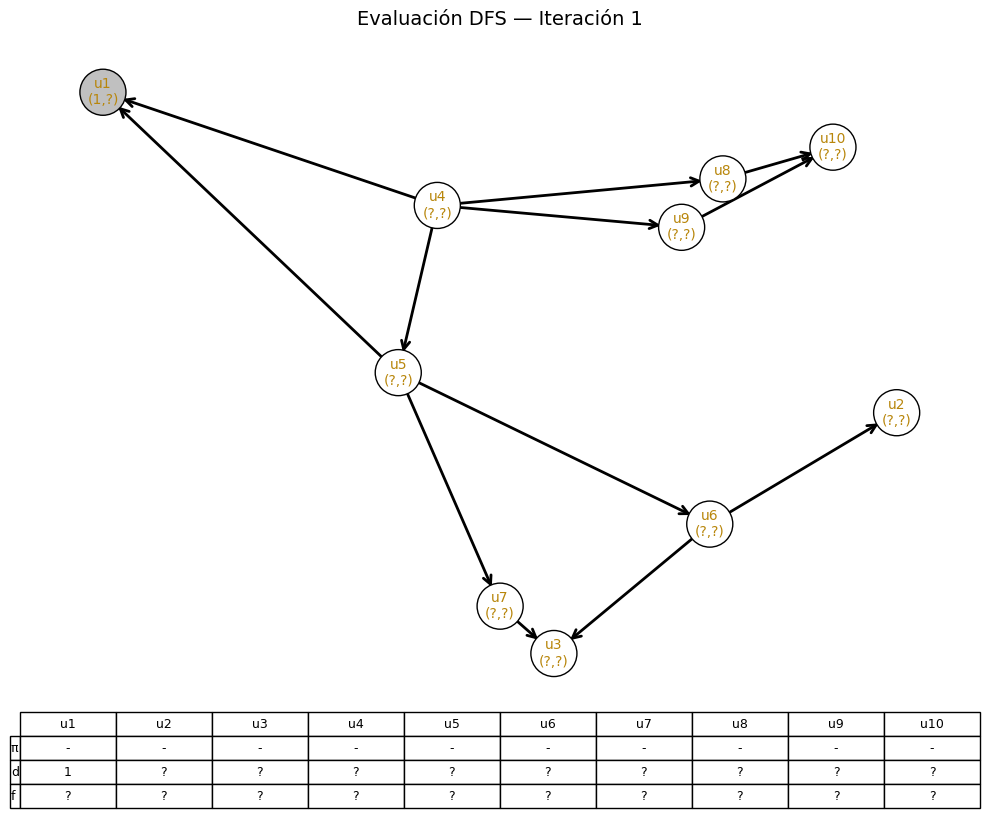

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


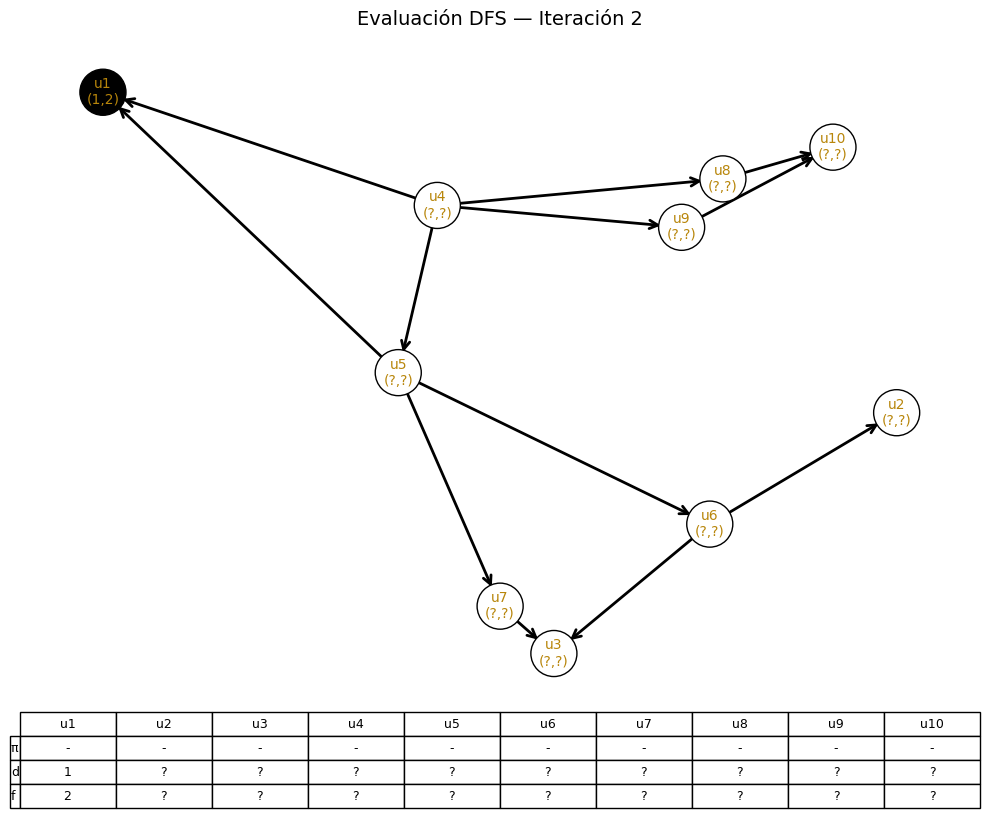

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


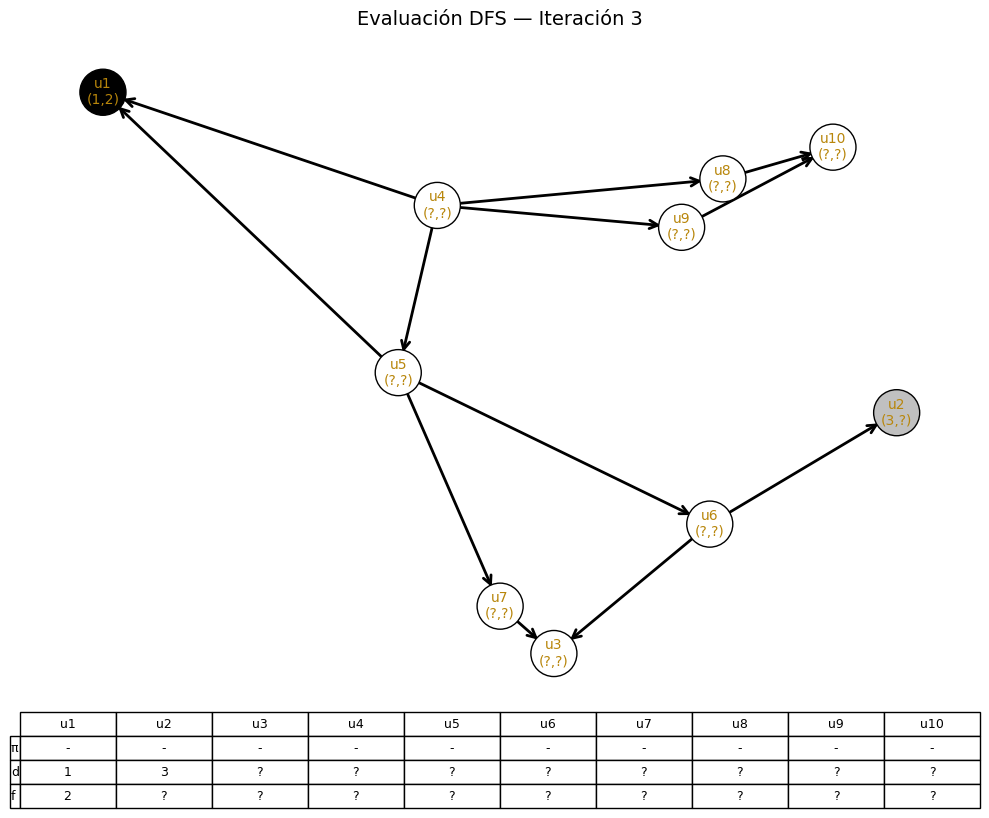

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


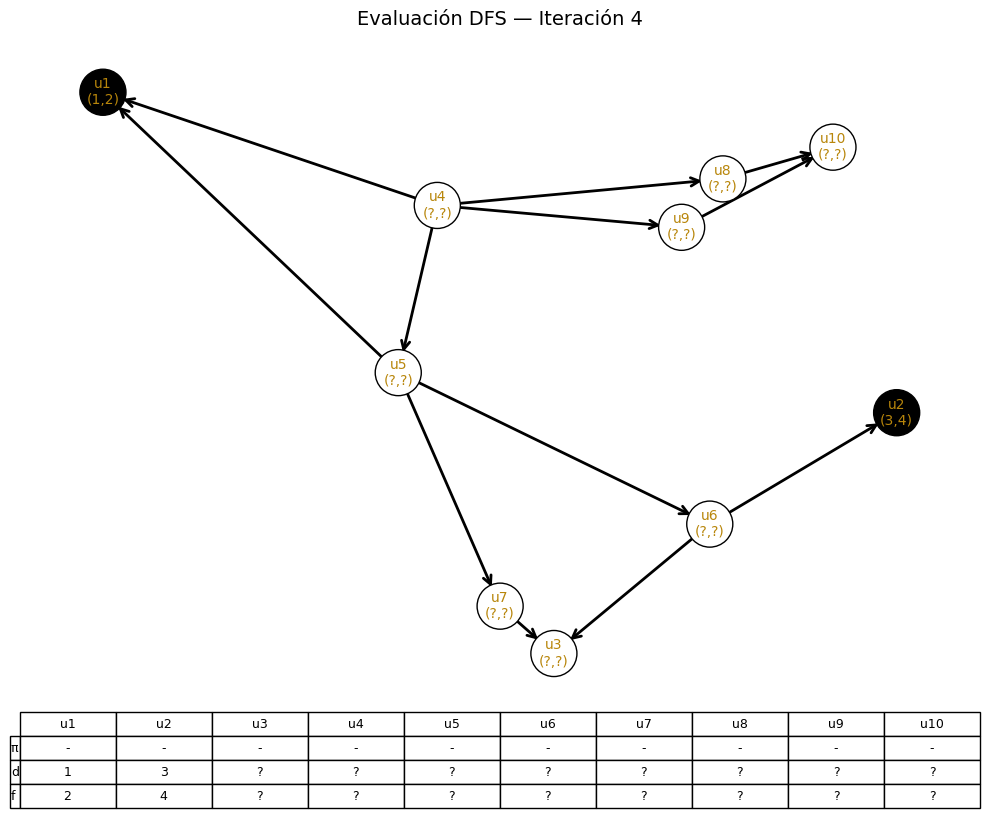

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


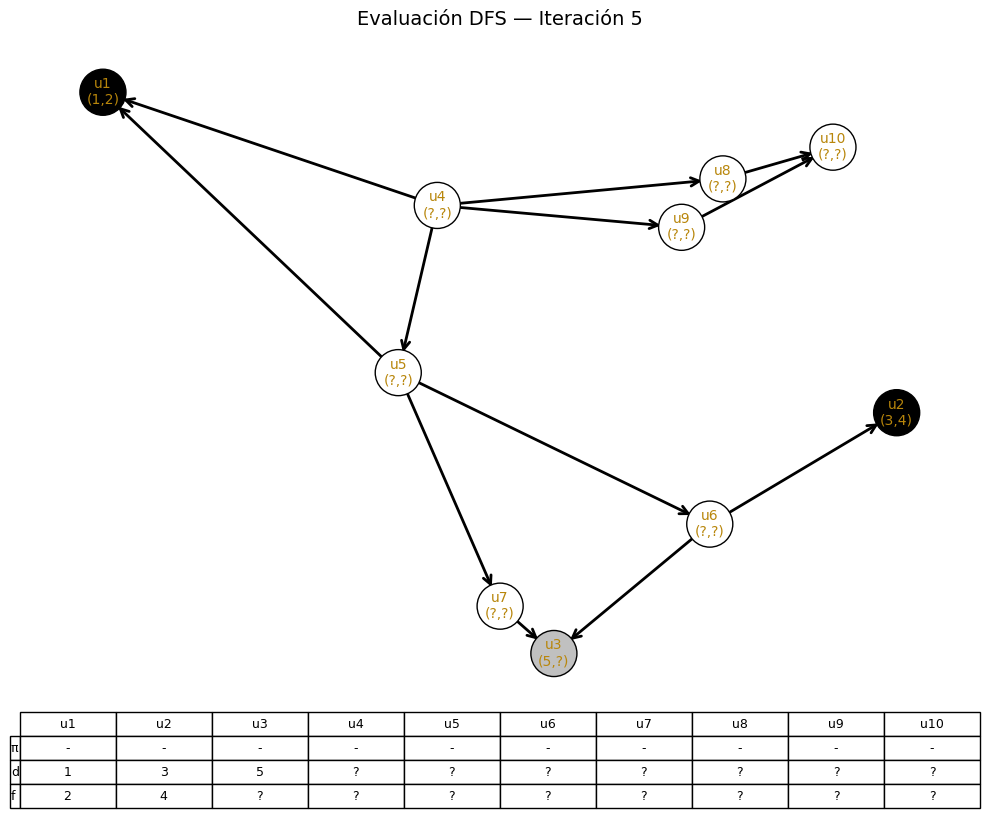

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


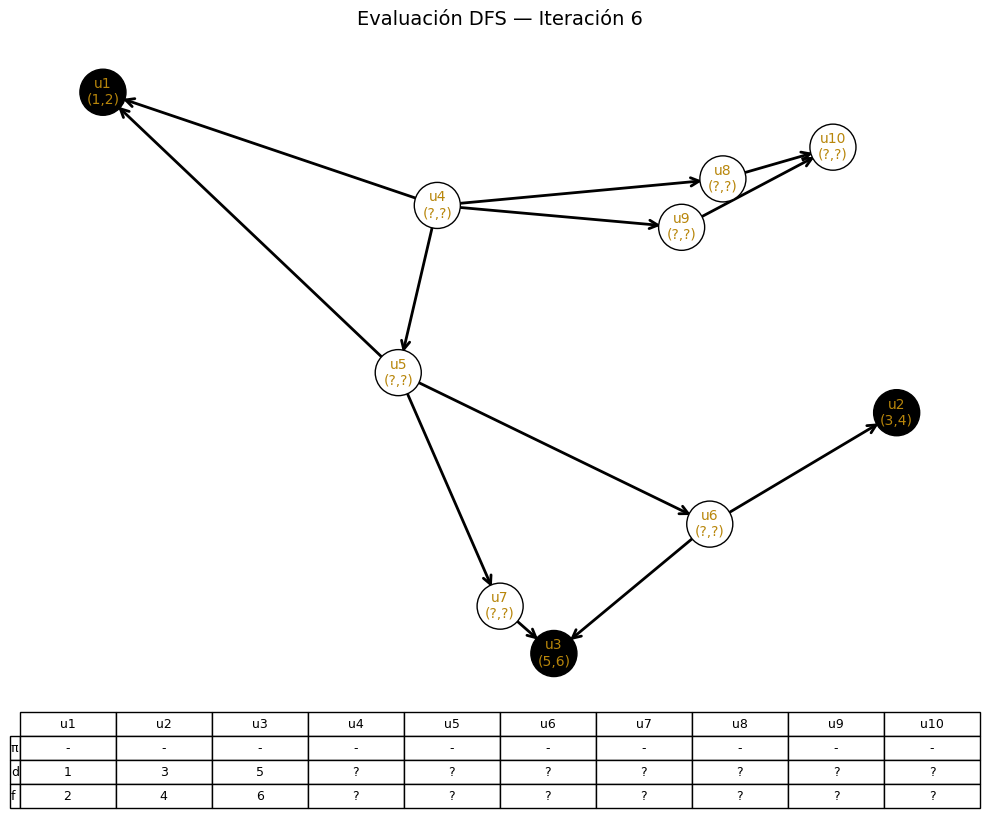

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


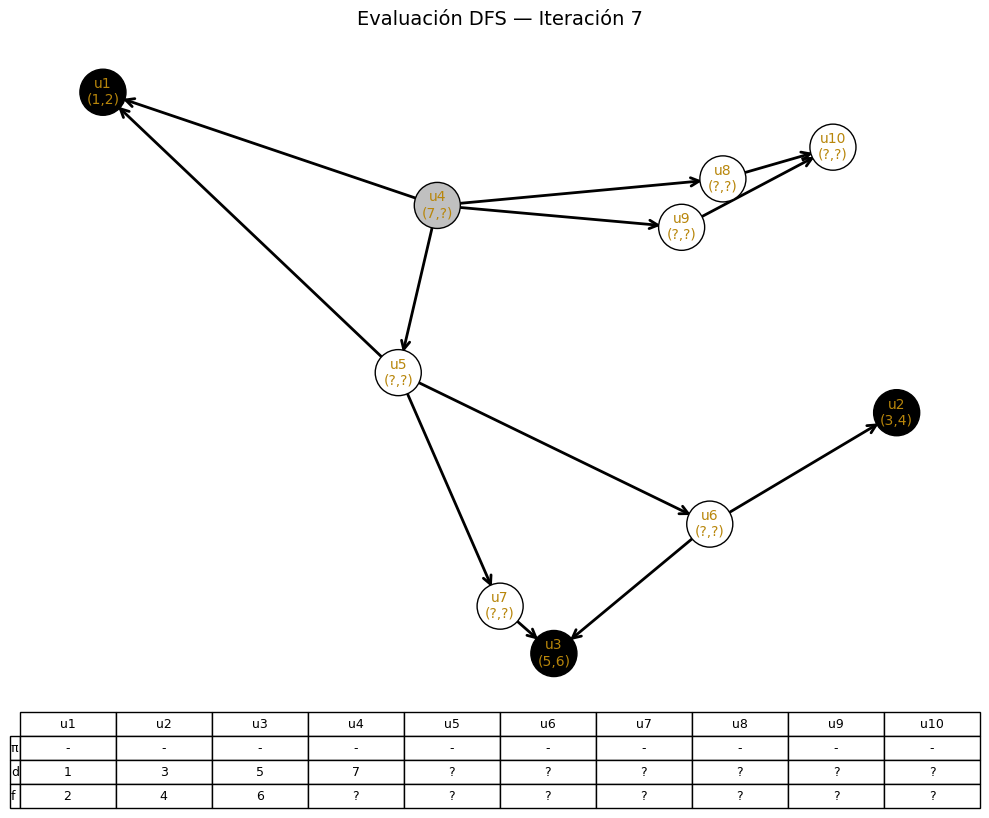

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


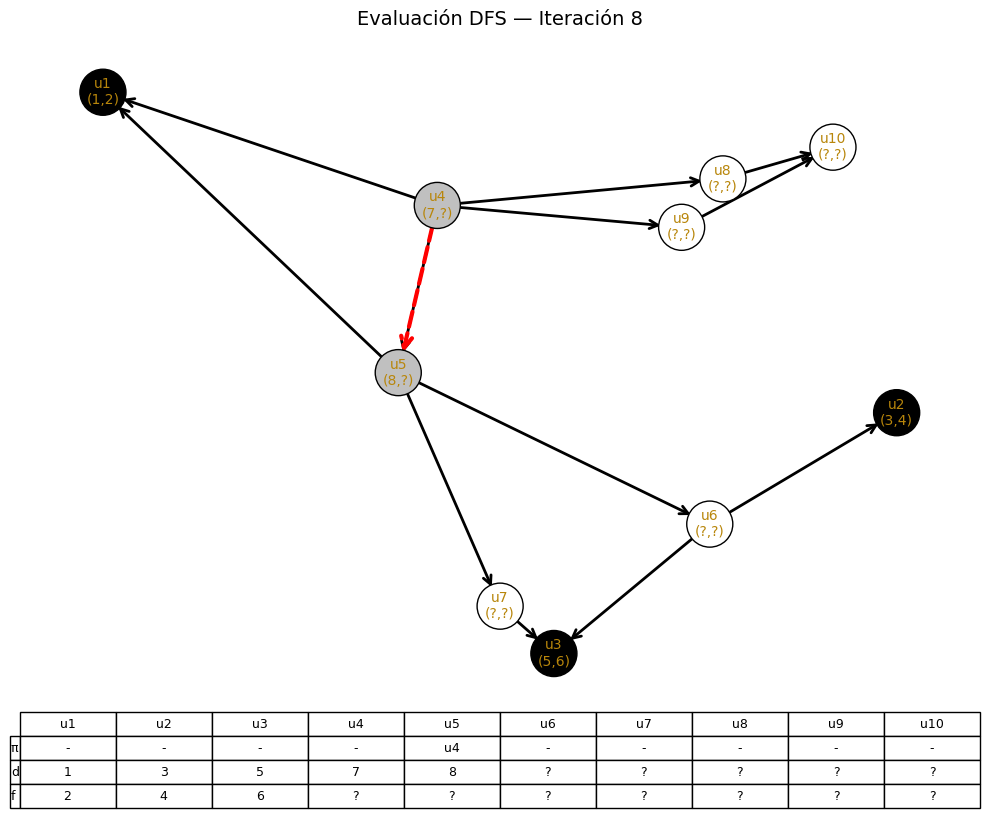

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


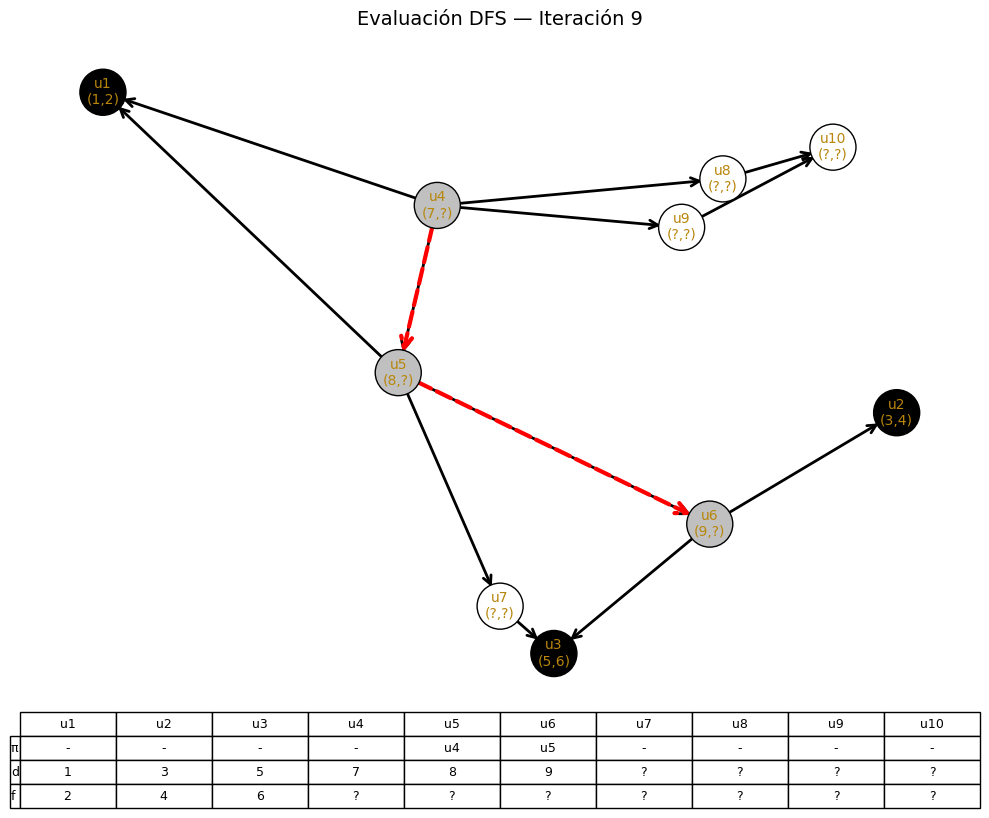

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


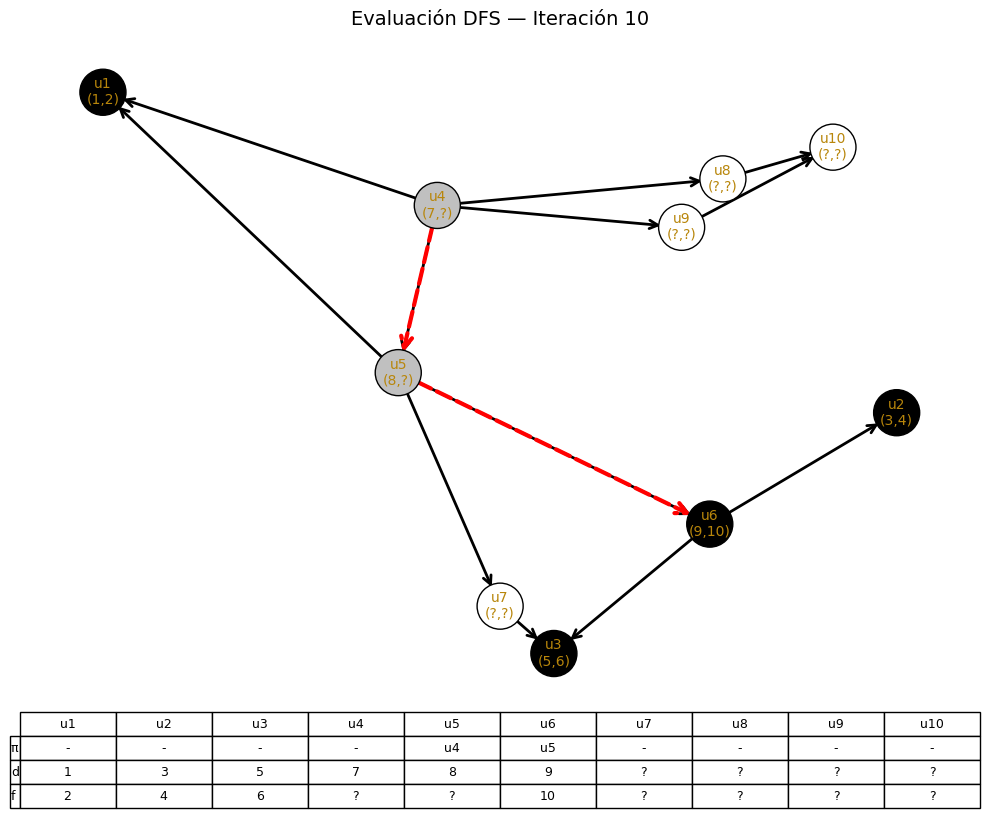

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


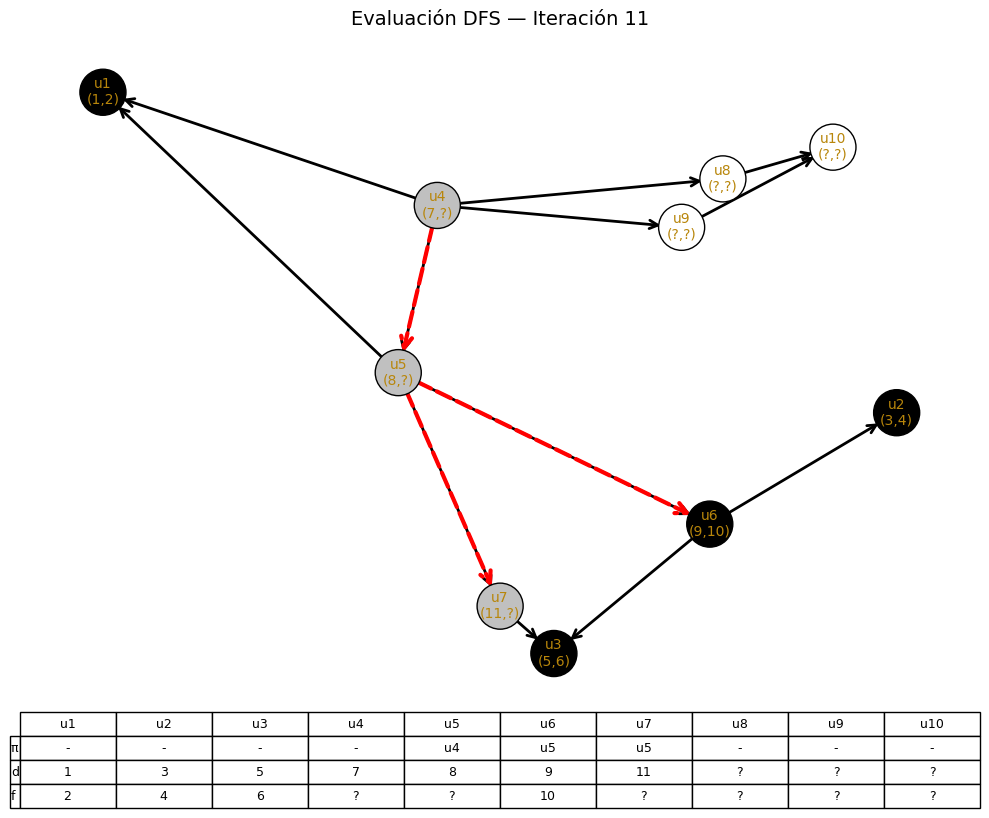

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


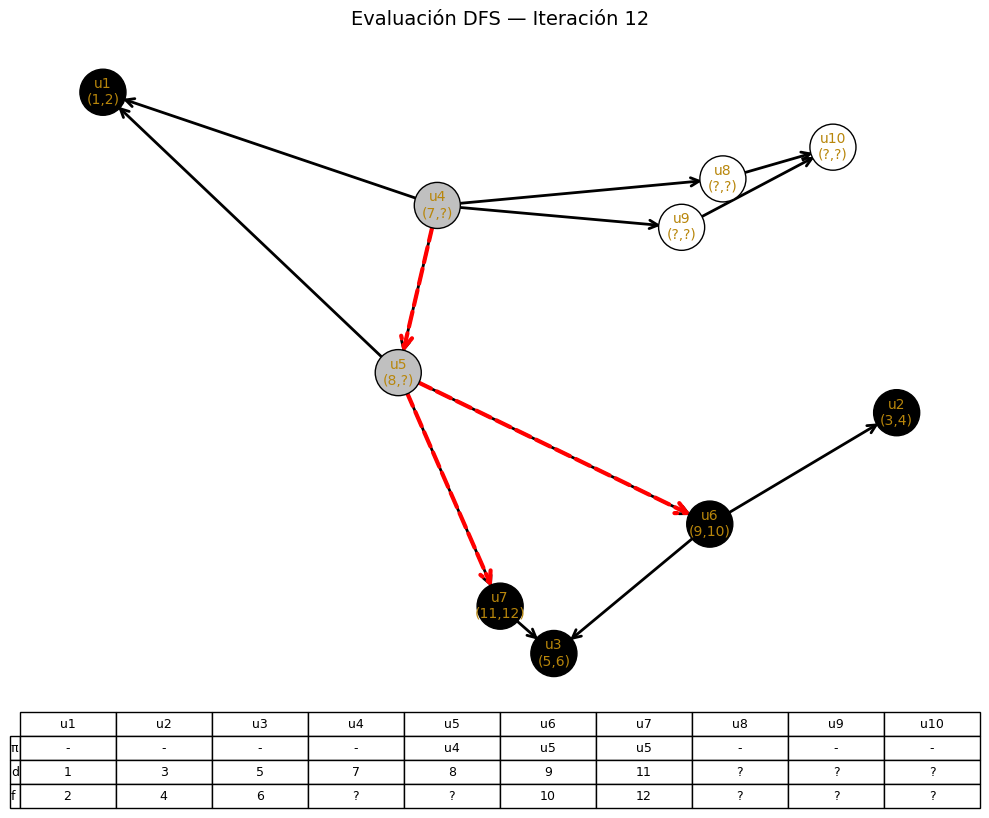

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


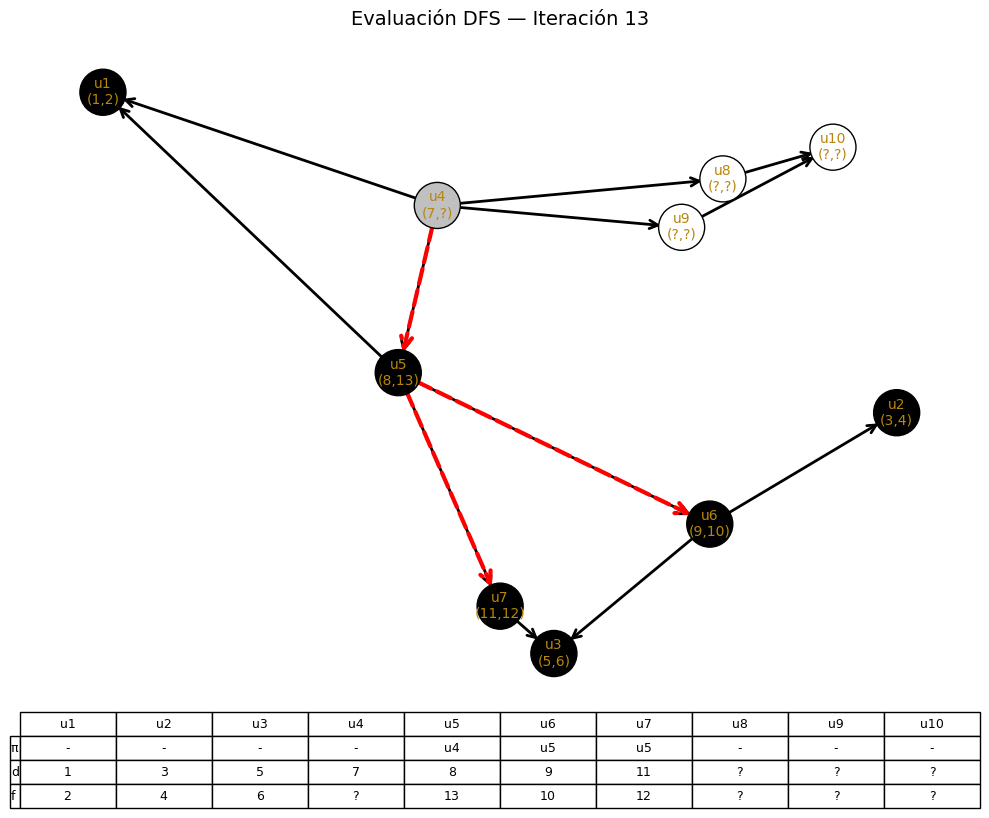

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


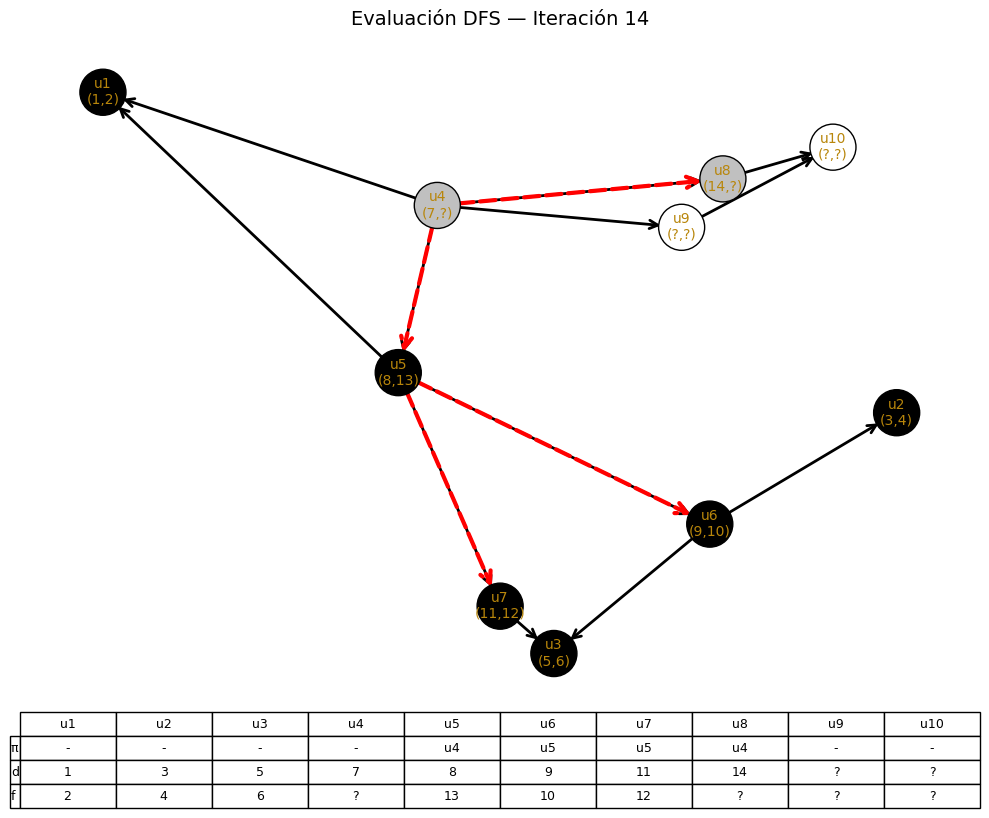

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


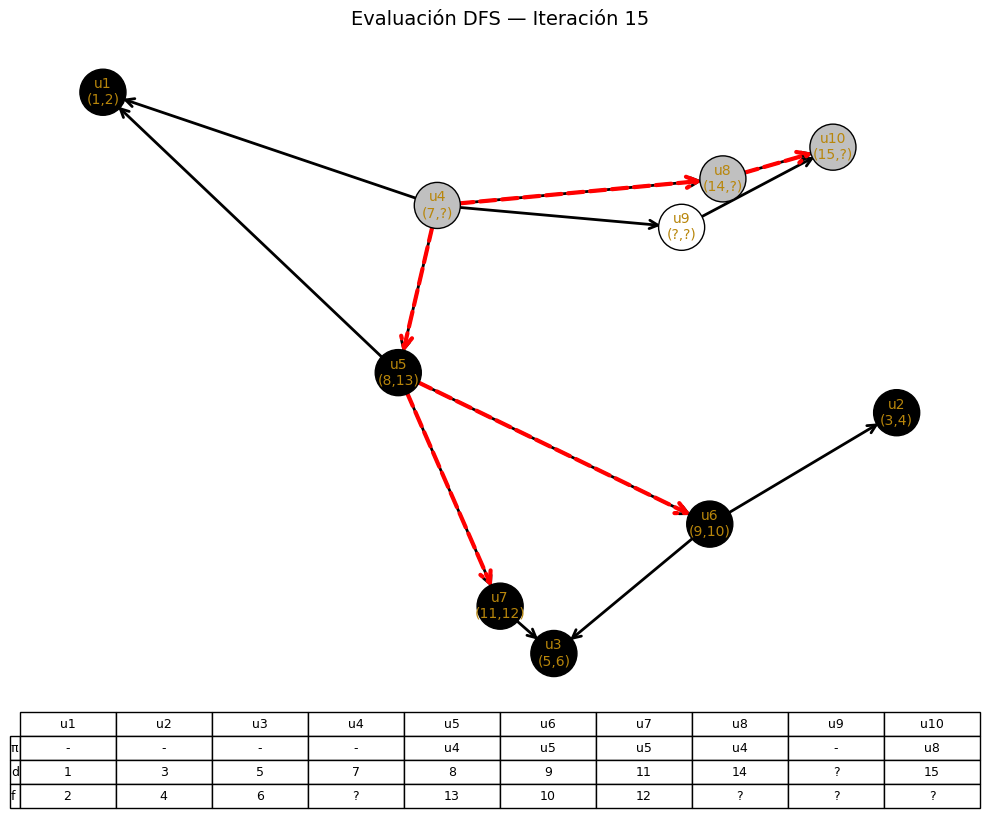

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


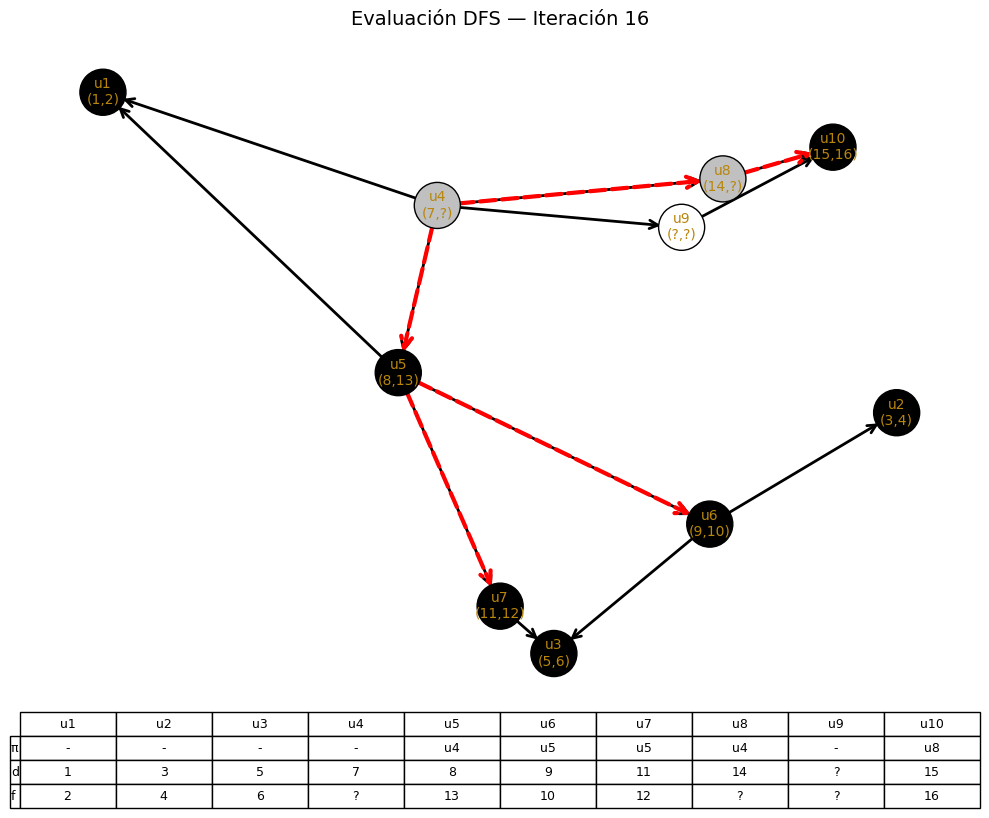

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


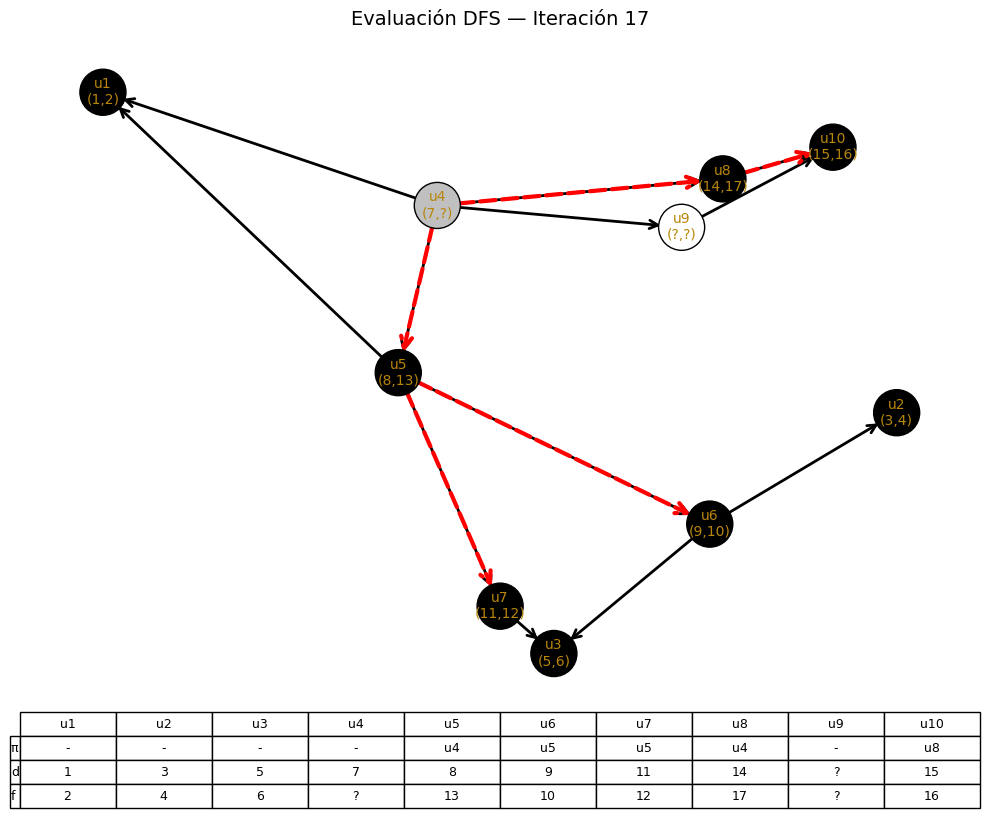

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


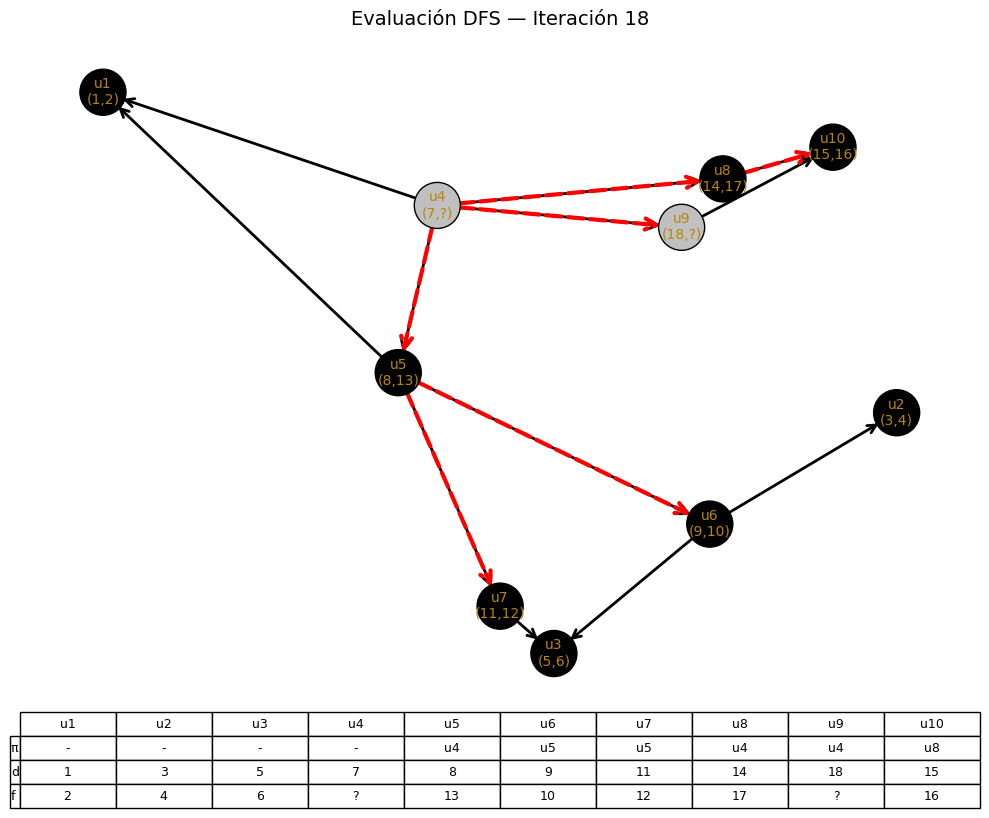

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


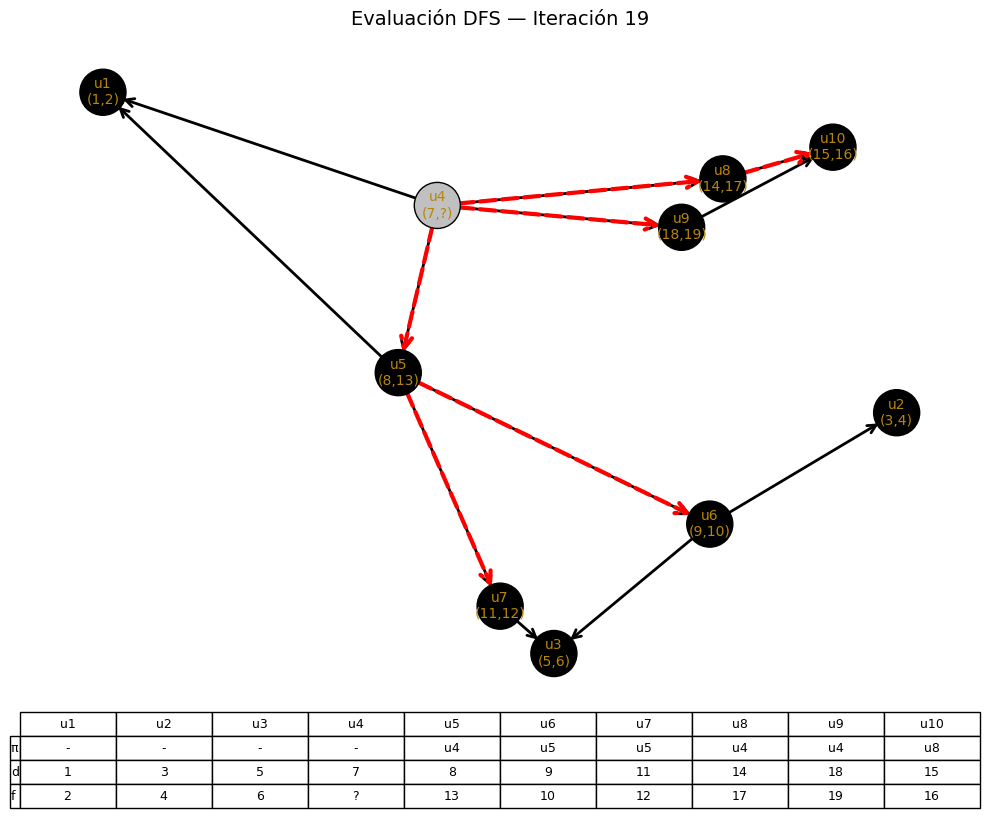

pos: {'u4': array([-0.28447425,  0.43847719]), 'u1': array([-0.93452791,  0.80182164]), 'u5': array([-0.36041391, -0.09830535]), 'u8': array([0.27072616, 0.52367312]), 'u9': array([0.19048848, 0.36829081]), 'u6': array([ 0.2452119 , -0.58457109]), 'u7': array([-0.16237657, -0.84796352]), 'u2': array([ 0.60852263, -0.22693411]), 'u3': array([-0.05782809, -1.        ]), 'u10': array([0.48467156, 0.6255113 ])}


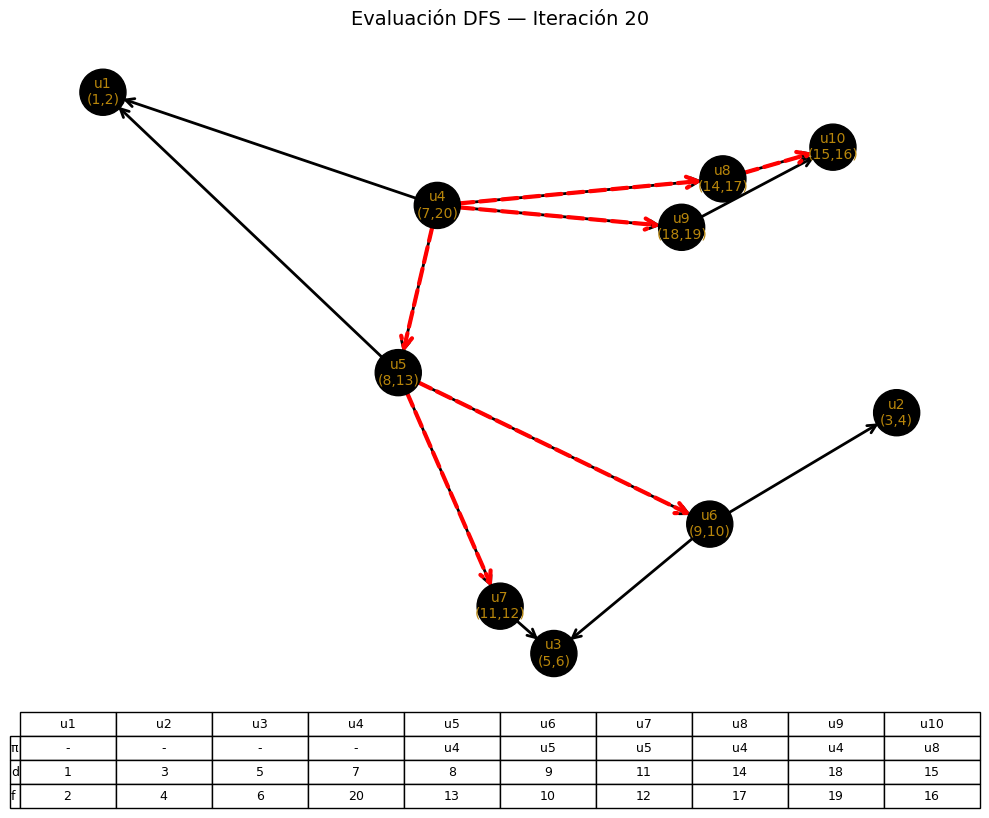

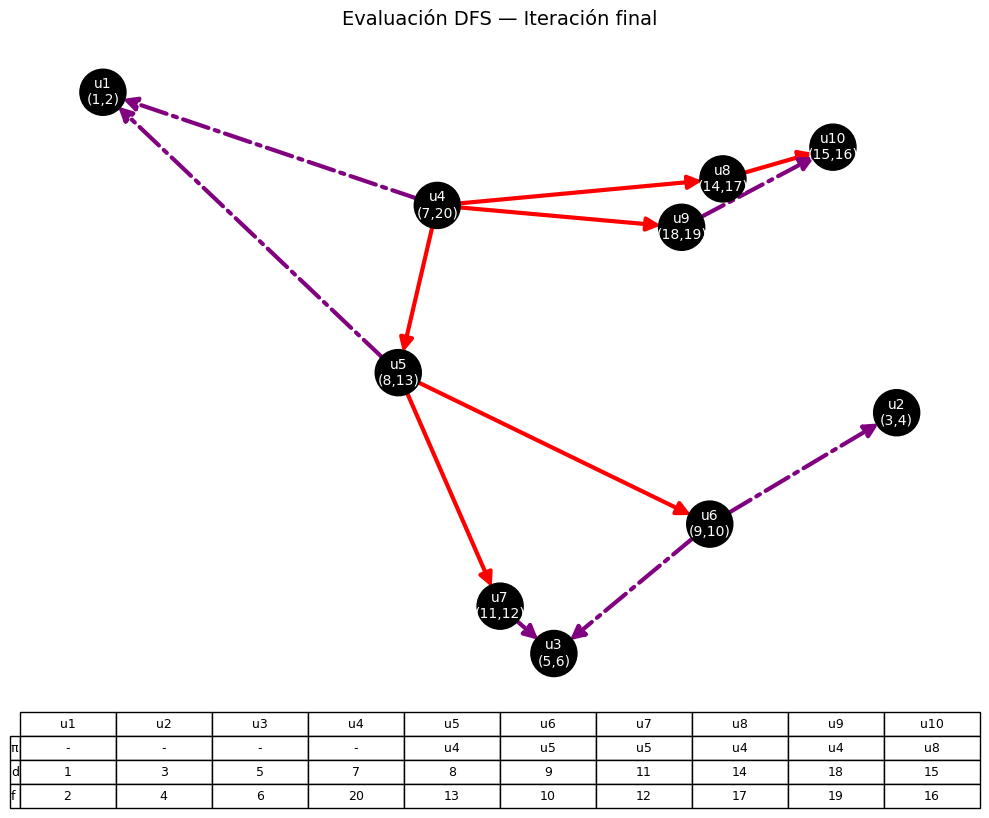

In [113]:
G = {
    "u1": [],
    "u2": [],
    "u3": [],
    "u4": ["u1","u5","u8","u9"],
    "u5": ["u1","u6","u7"],
    "u6": ["u2", "u3"],
    "u7": ["u3"],
    "u8": ["u10"],
    "u9": ["u10"],
    "u10": []
}

C, pi, d, f = DFS(G)


### Strong components


In [120]:
import matplotlib.pyplot as plt
import networkx as nx

def evaluacion_dfs(iteracion, G, C, pi, d, f):
    plt.figure(figsize=(10, 8))

    # ---- Convertir G a grafo de networkx ----
    G_nx = nx.DiGraph()
    for u in G:
        for v in G[u]:
            G_nx.add_edge(u, v)

    # ---- Layout estable ----
    pos = {
        "u4":  (-0.28447425,  0.43847719),
        "u1":  (-0.93452791,  0.80182164),
        "u5":  (-0.36041391, -0.09830535),
        "u8":  ( 0.27072616,  0.52367312),
        "u9":  ( 0.19048848,  0.36829081),
        "u6":  ( 0.24521190, -0.58457109),
        "u7":  (-0.16237657, -0.84796352),
        "u2":  ( 0.60852263, -0.22693411),
        "u3":  (-0.05782809, -1.00000000),
        "u10": ( 0.48467156,  0.62551130)
    }


    # ---- Colores DFS ----
    color_map = {
        "White": "white",
        "Gray": "silver",
        "Black": "black"
    }

    node_colors = [
        color_map.get(C.get(n, "White"), "lightgray")
        for n in G_nx.nodes()
    ]

    def tfmt_from(mapping, node):
        """
        Devuelve una representación segura y legible del valor mapping[node].
        - Si la clave no existe o es None -> "?"
        - Si es float('inf') -> "∞"
        - Si es 0 (valor inicial) -> "-"  (opcional, cambia según prefieras)
        - En otro caso -> str(valor)
        """
        v = mapping.get(node, None)
        if v is None:
            return "?"
        try:
            # detectar infinito
            if v == float("inf"):
                return "∞"
        except Exception:
            pass
        # Si consideras que 0 significa "no asignado", muestra "-", si no, muestra "0"
        if v == 0:
            return "-"        # <- cambia a "0" si prefieres ver el cero
        return str(v)

    labels = {
        n: f"{n}\n({tfmt_from(d, n)},{tfmt_from(f, n)})"
        for n in G_nx.nodes()
    }

    # ---- Dibujar nodos ----
    nx.draw_networkx_nodes(
        G_nx, pos,
        node_color=node_colors,
        node_size=1100,
        edgecolors='black'
    )

    # ---- Aristas normales ----
    nx.draw_networkx_edges(
        G_nx, pos,
        arrows=True,
        arrowstyle='->',
        arrowsize=15,
        width=2,
        min_source_margin=15,
        min_target_margin=15
    )

    # ---- Aristas del árbol DFS (predecesores) ----
    tree_edges = []
    for v in pi:
        u = pi[v]
        if u is not None:
            tree_edges.append((u, v))

    nx.draw_networkx_edges(
        G_nx, pos,
        edgelist=tree_edges,
        style='dashed',
        width=3,
        edge_color='red',
        arrows=True,
        arrowstyle='->',
        arrowsize=20,
        min_source_margin=15,
        min_target_margin=15
    )

    # ---- Etiquetas ----
    nx.draw_networkx_labels(
        G_nx, pos,
        labels=labels,
        font_color="darkgoldenrod",
        font_size=10
    )

    # ---- Título ----
    plt.title(f"Evaluación DFS — Iteración {iteracion}", fontsize=14)

        # ---- TABLA DE π, d y f ----

    nodes = list(C.keys())
    column_labels = nodes
    row_labels = ["π", "d", "f"]

    cell_text = [
        [pi.get(n, "-") if pi.get(n) is not None else "-" for n in nodes],
        [tfmt_from(d, n) for n in nodes],
        [tfmt_from(f, n) for n in nodes]
    ]

    table = plt.table(
        cellText=cell_text,
        colLabels=column_labels,
        rowLabels=row_labels,
        loc='bottom',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.3)

    # Ajustes para que la tabla no pise el grafo
    plt.subplots_adjust(left=0.08, bottom=0.28)

    plt.axis("off")
    plt.tight_layout()
    plt.show()



In [123]:
import matplotlib.pyplot as plt
import networkx as nx

def evaluacion_dfs_edges(iteracion, G, C, pi, d, f):
    plt.figure(figsize=(10, 8))

    # ============================================================
    #   CONVERTIR A GRAFO DE NETWORKX
    # ============================================================
    G_nx = nx.DiGraph()
    for u in G:
        for v in G[u]:
            G_nx.add_edge(u, v)

    pos = {
        "u4":  (-0.28447425,  0.43847719),
        "u1":  (-0.93452791,  0.80182164),
        "u5":  (-0.36041391, -0.09830535),
        "u8":  ( 0.27072616,  0.52367312),
        "u9":  ( 0.19048848,  0.36829081),
        "u6":  ( 0.24521190, -0.58457109),
        "u7":  (-0.16237657, -0.84796352),
        "u2":  ( 0.60852263, -0.22693411),
        "u3":  (-0.05782809, -1.00000000),
        "u10": ( 0.48467156,  0.62551130)
    }

    # ============================================================
    #   COLORES DE LOS NODOS SEGÚN DFS
    # ============================================================
    color_map = {
        "White": "lightgray",
        "Gray": "orange",
        "Black": "black"
    }

    node_colors = [
        color_map.get(C.get(n, "White"), "lightgray")
        for n in G_nx.nodes()
    ]

    # ============================================================
    #   FORMATEO DE d y f
    # ============================================================
    def tfmt_from(mapping, node):
        v = mapping.get(node, None)
        if v is None:
            return "?"
        if v == float("inf"):
            return "∞"
        if v == 0:
            return "-"
        return str(v)

    labels = {
        n: f"{n}\n({tfmt_from(d,n)},{tfmt_from(f,n)})"
        for n in G_nx.nodes()
    }

    # ============================================================
    #   CLASIFICACIÓN DE ARISTAS SEGÚN d(u), f(u)
    # ============================================================
    tree_edges = []
    forward_edges = []
    back_edges = []
    cross_edges = []

    for u in G:
        for v in G[u]:
            du, fu = d[u], f[u]
            dv, fv = d[v], f[v]

            # ---- Tree edge ----
            if pi.get(v) == u:
                tree_edges.append((u, v))
            # ---- Forward edge: du < dv < fv < fu ----
            elif du < dv and fv < fu:
                forward_edges.append((u, v))
            # ---- Back edge: dv < du < fu < fv ----
            elif dv < du and fu < fv:
                back_edges.append((u, v))
            # ---- Cross edge: dv < fv < du < fu ----
            elif dv < fv and fv < du and du < fu:
                cross_edges.append((u, v))

    # ============================================================
    #   DIBUJAR NODOS
    # ============================================================
    nx.draw_networkx_nodes(
        G_nx, pos,
        node_color=node_colors,
        node_size=1100,
        edgecolors='black'
    )

    # ============================================================
    #   DIBUJAR ARISTAS CLASIFICADAS
    # ============================================================
    nx.draw_networkx_edges(G_nx, pos,
        edgelist=tree_edges,
        edge_color="red", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_edges(G_nx, pos,
        edgelist=forward_edges,
        edge_color="green", style="dashed", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_edges(G_nx, pos,
        edgelist=back_edges,
        edge_color="blue", style="dotted", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    nx.draw_networkx_edges(G_nx, pos,
        edgelist=cross_edges,
        edge_color="purple", style="dashdot", width=3, arrowsize=20, min_source_margin=15,
        min_target_margin=15
    )

    # ============================================================
    #   ETIQUETAS
    # ============================================================
    nx.draw_networkx_labels(
        G_nx, pos, labels=labels,
        font_color="white", font_size=10
    )

    # ============================================================
    #   TABLA π, d, f
    # ============================================================
    nodes = list(C.keys())
    column_labels = nodes
    row_labels = ["π", "d", "f"]

    cell_text = [
        [pi.get(n, "-") if pi.get(n) is not None else "-" for n in nodes],
        [tfmt_from(d, n) for n in nodes],
        [tfmt_from(f, n) for n in nodes]
    ]

    table = plt.table(
        cellText=cell_text,
        colLabels=column_labels,
        rowLabels=row_labels,
        loc='bottom',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.3)

    plt.subplots_adjust(left=0.08, bottom=0.28)

    plt.axis("off")
    plt.title(f"Evaluación DFS — Iteración {iteracion}", fontsize=14)
    plt.tight_layout()
    plt.show()


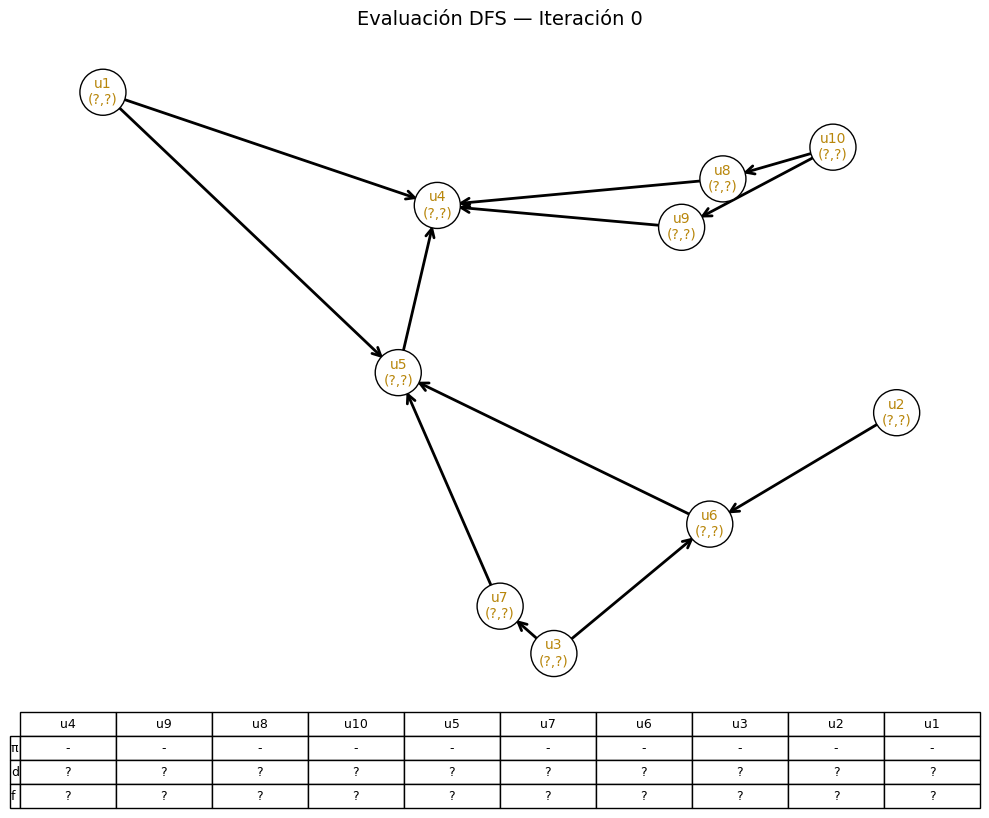

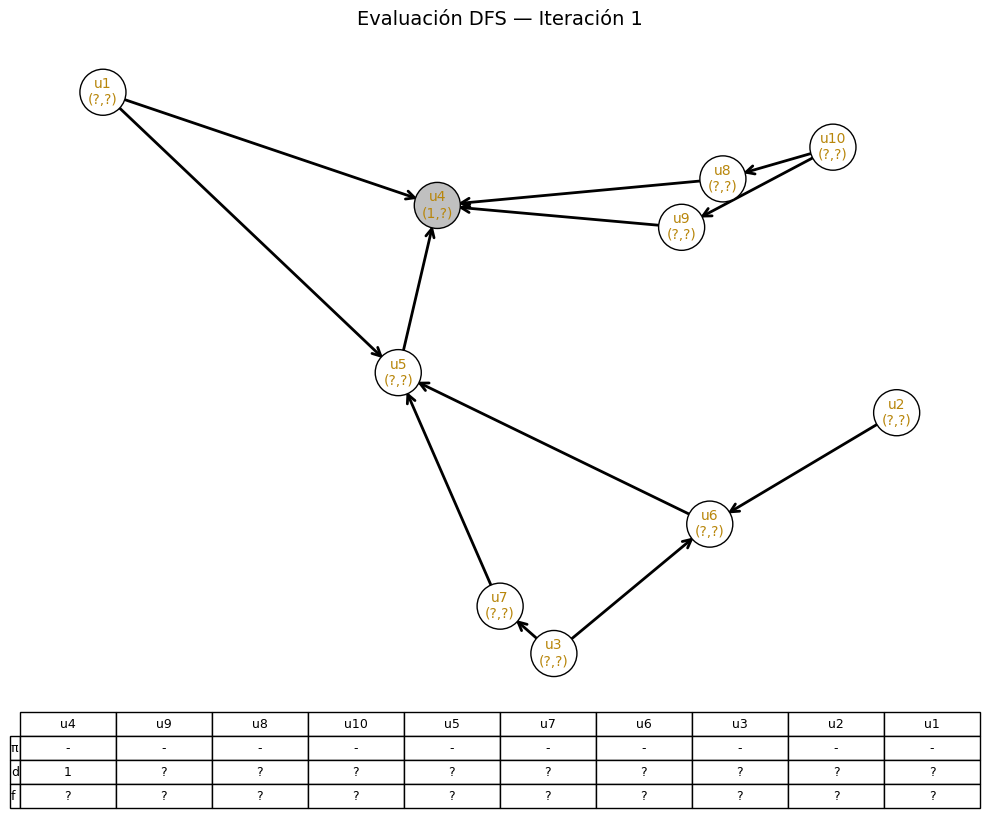

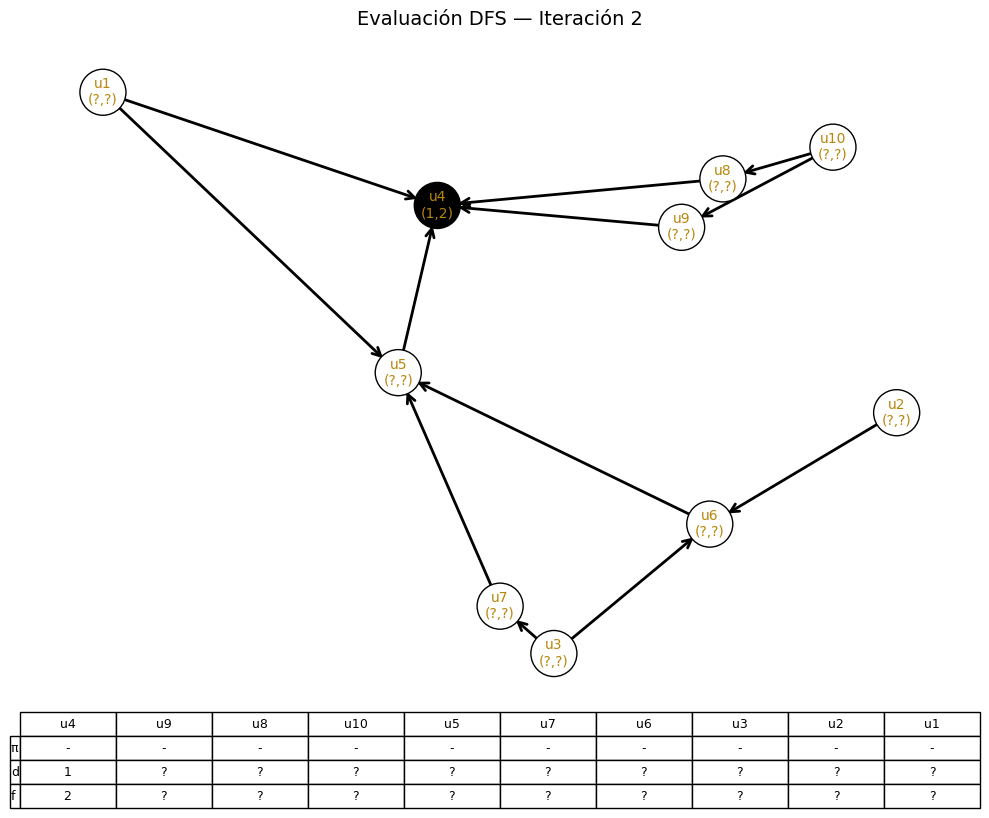

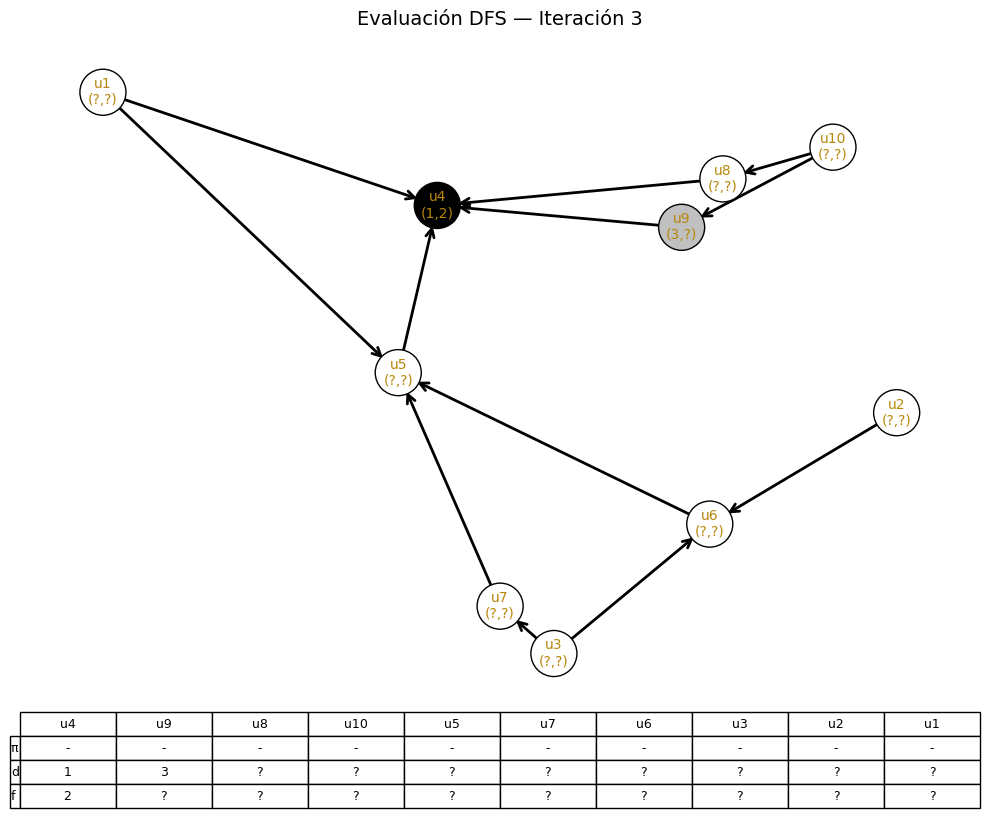

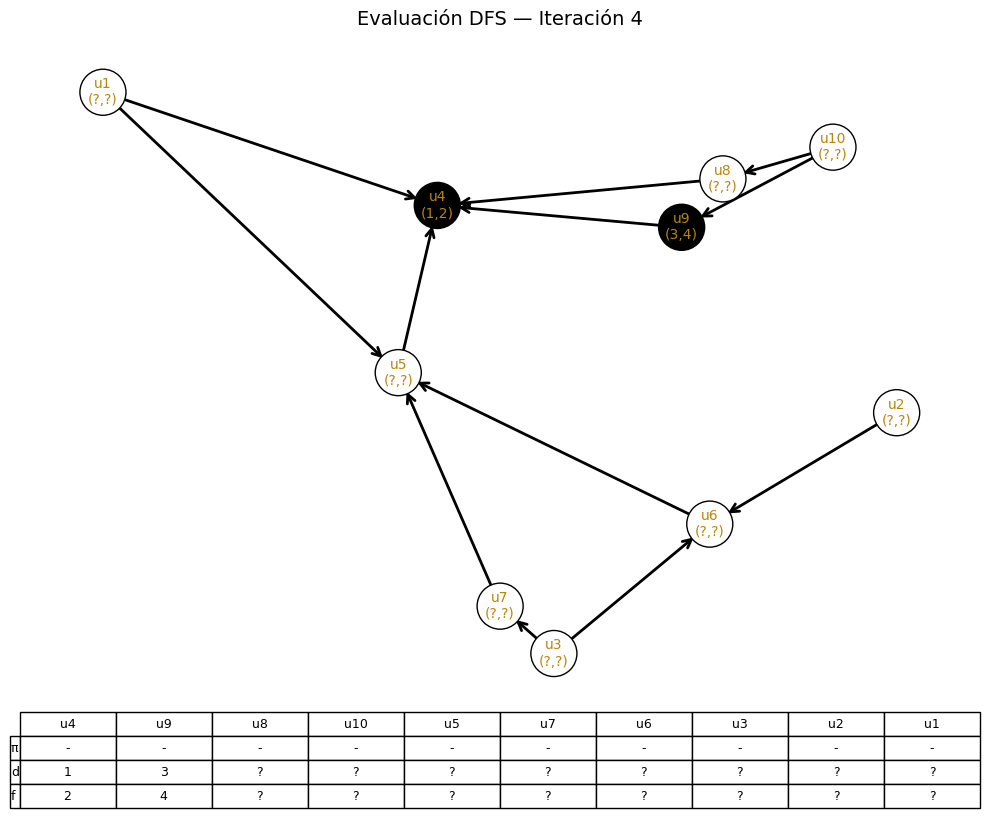

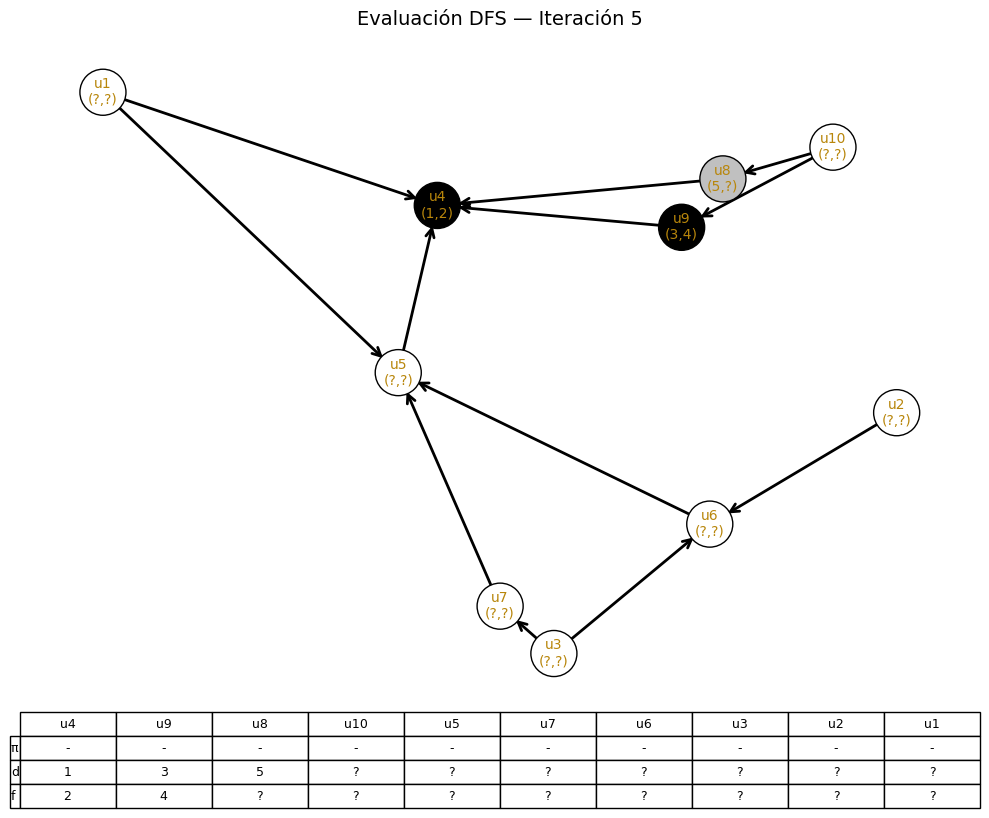

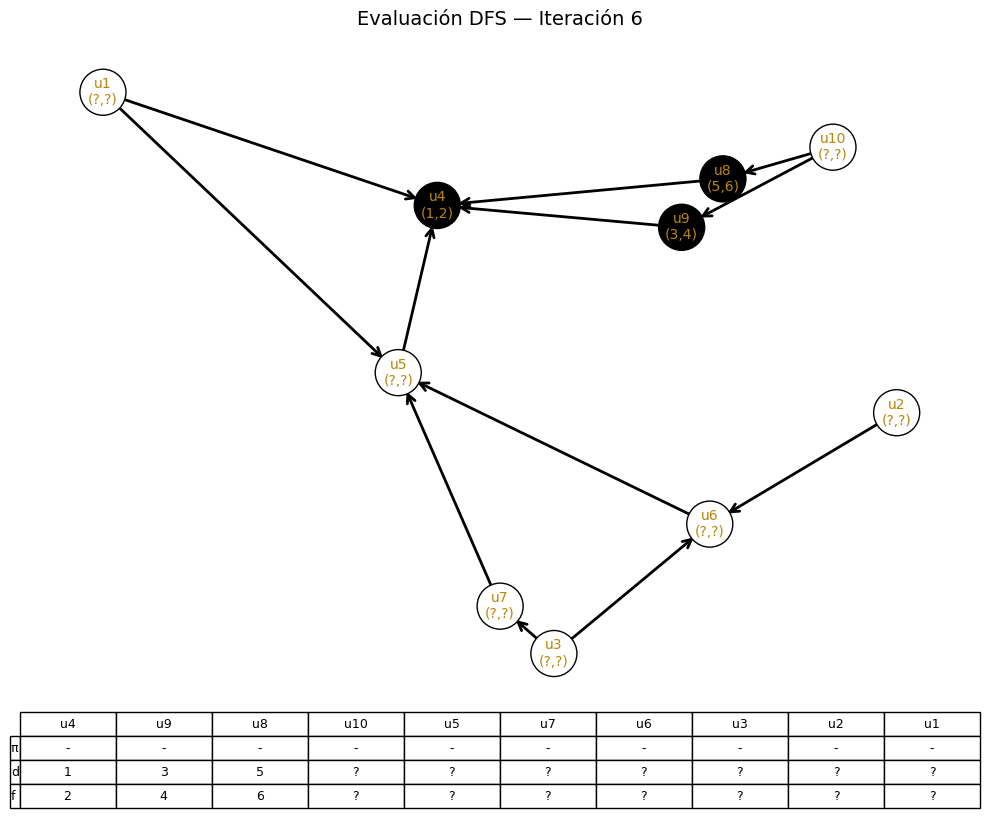

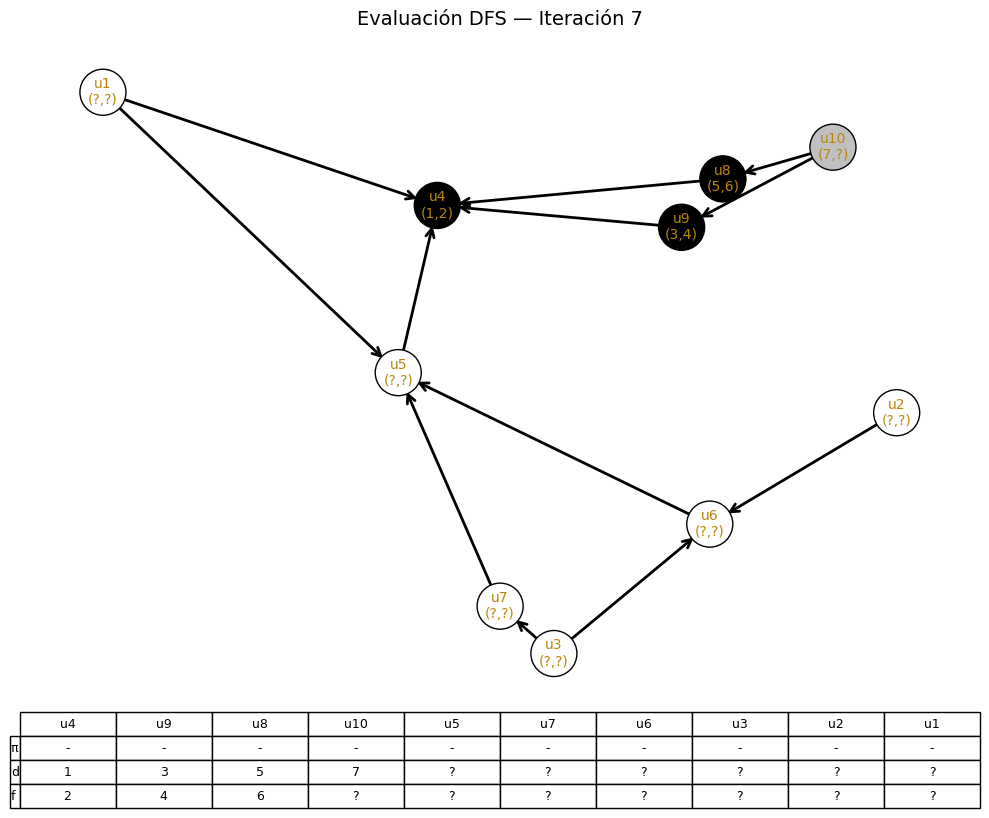

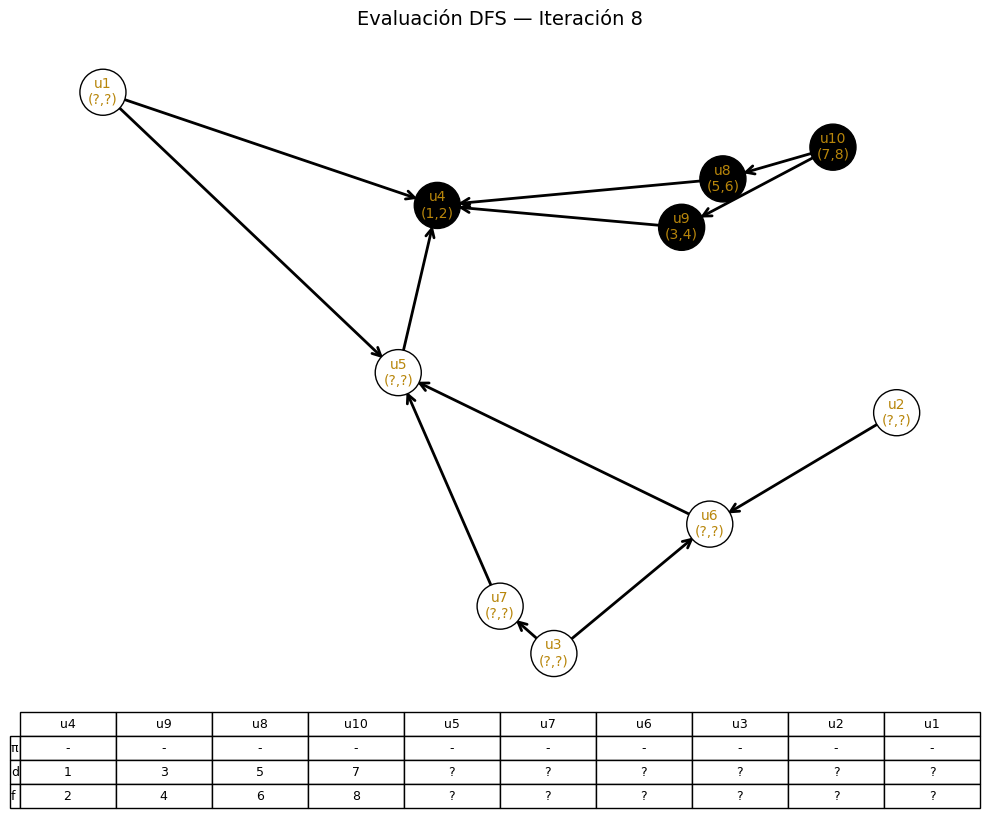

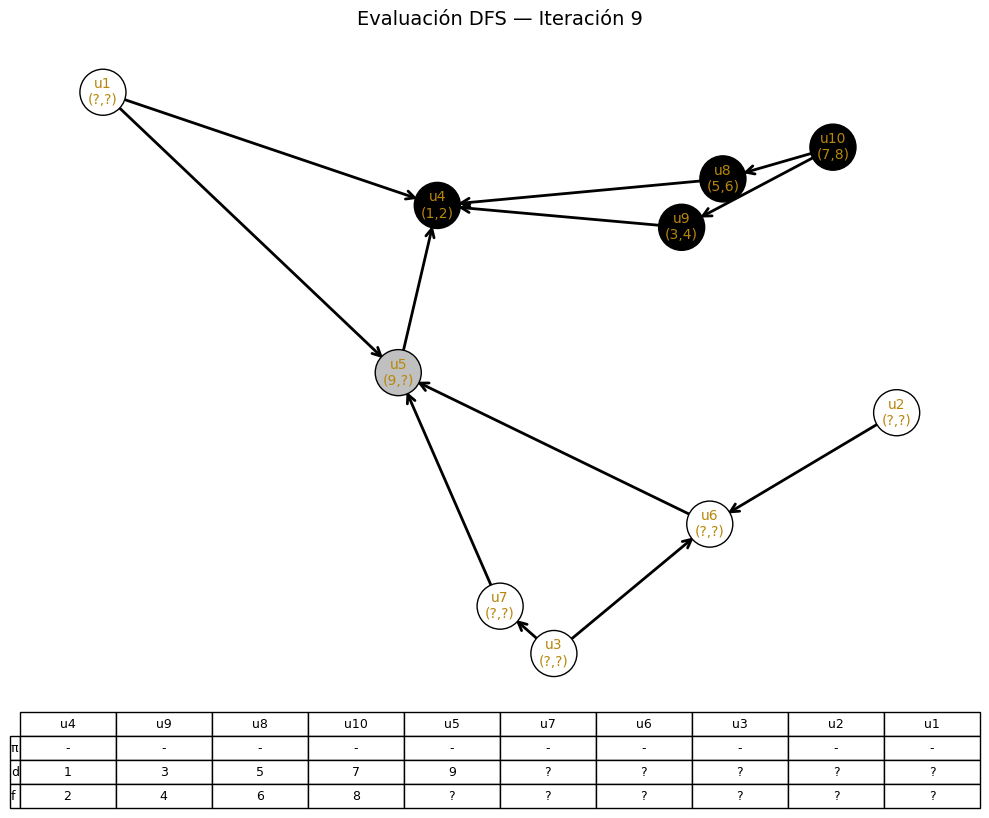

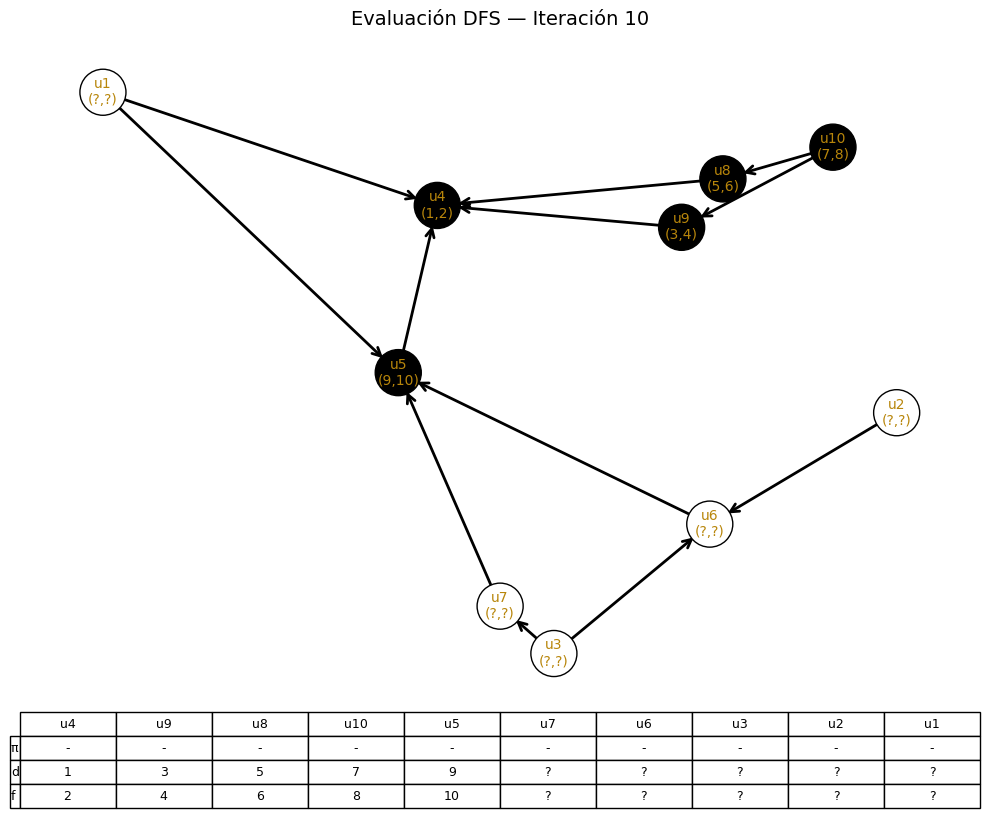

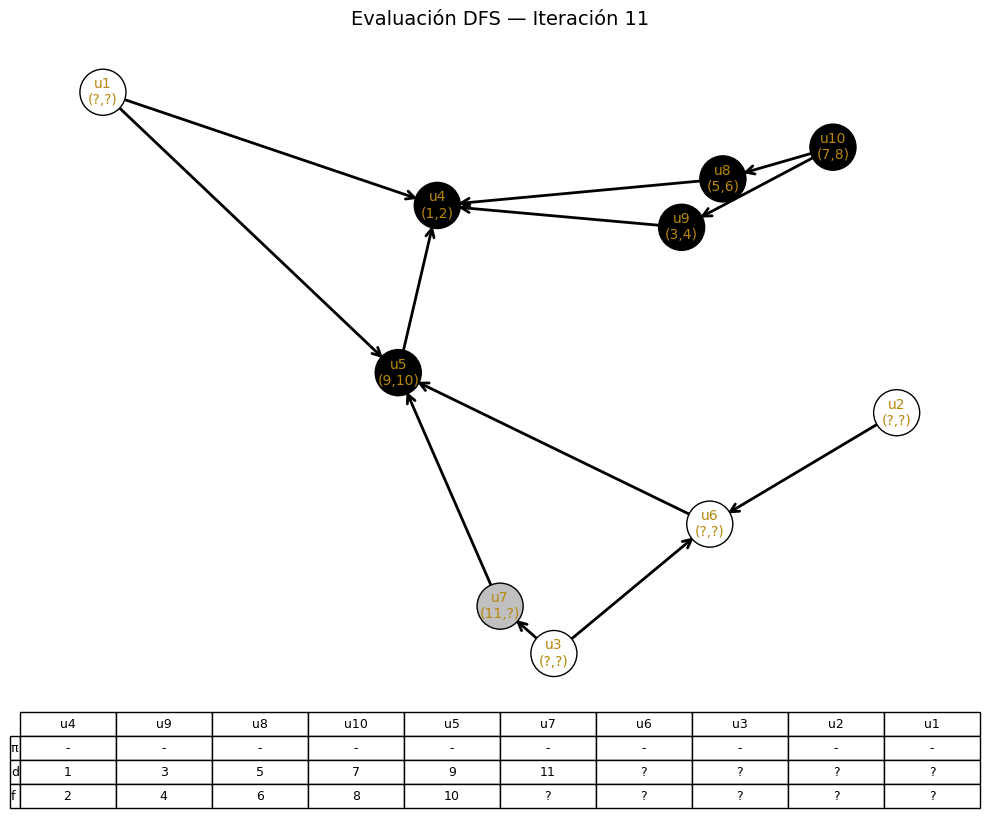

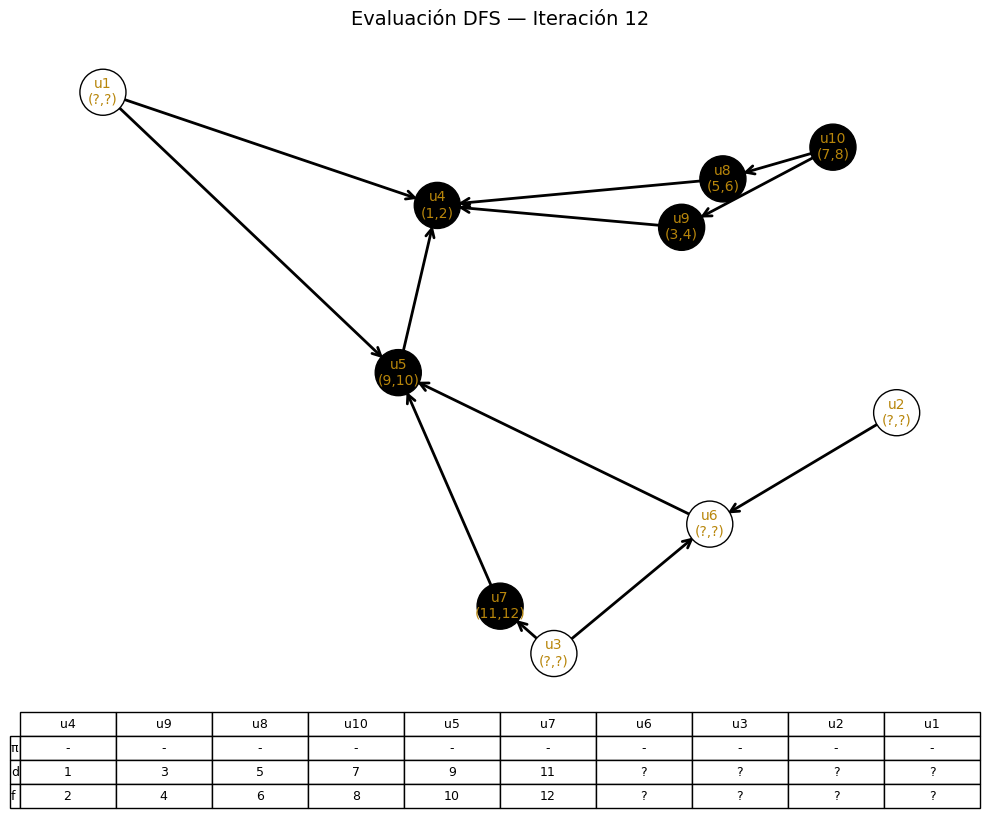

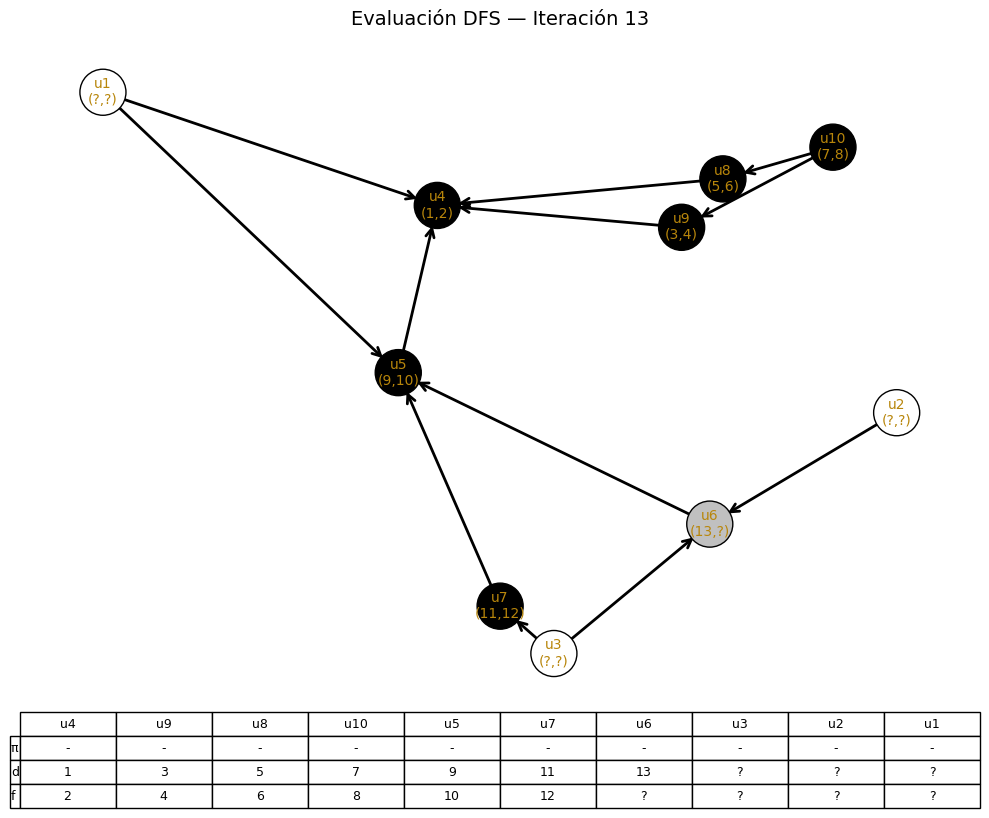

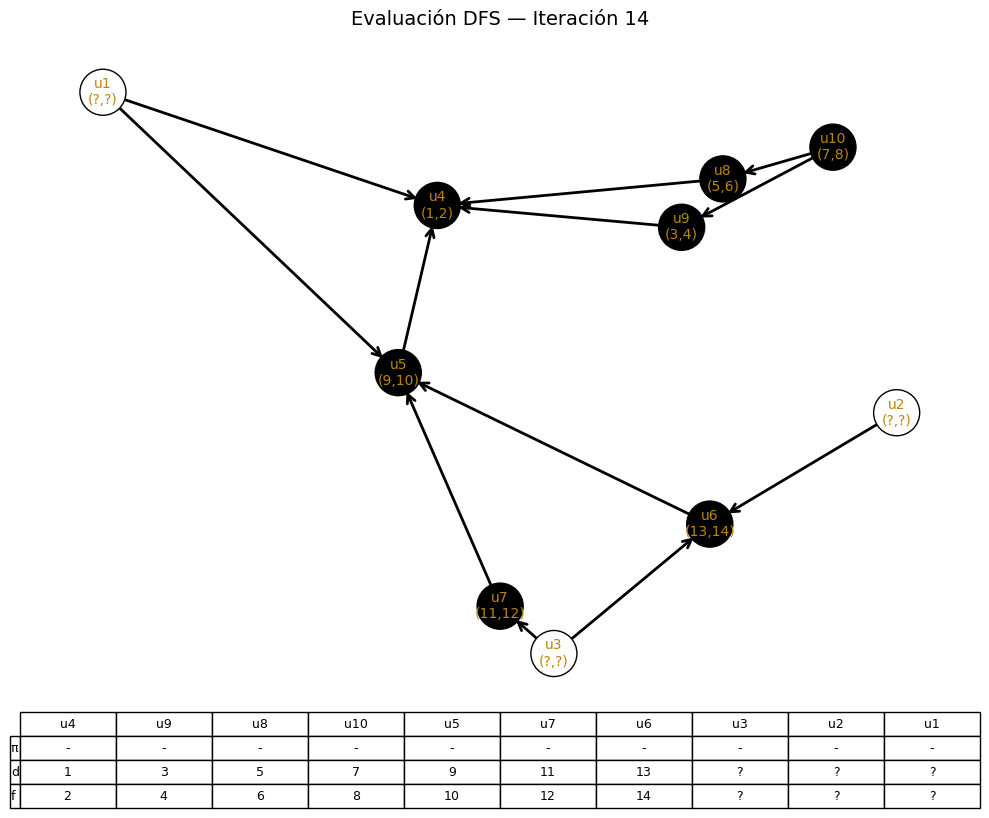

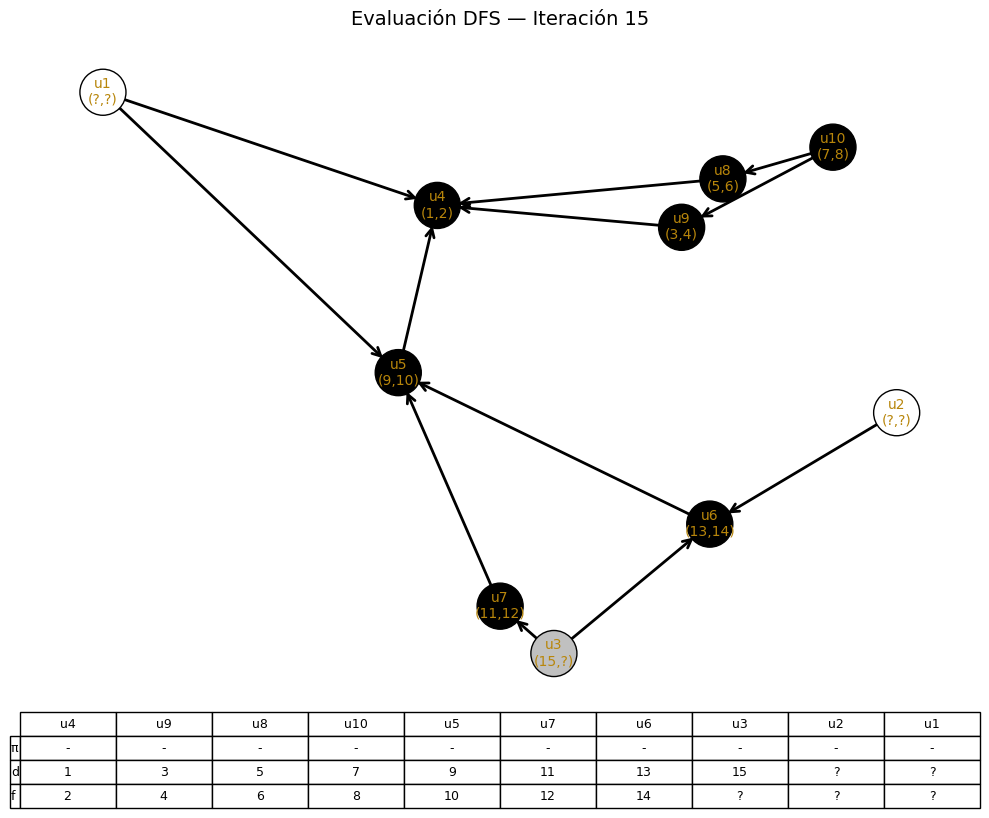

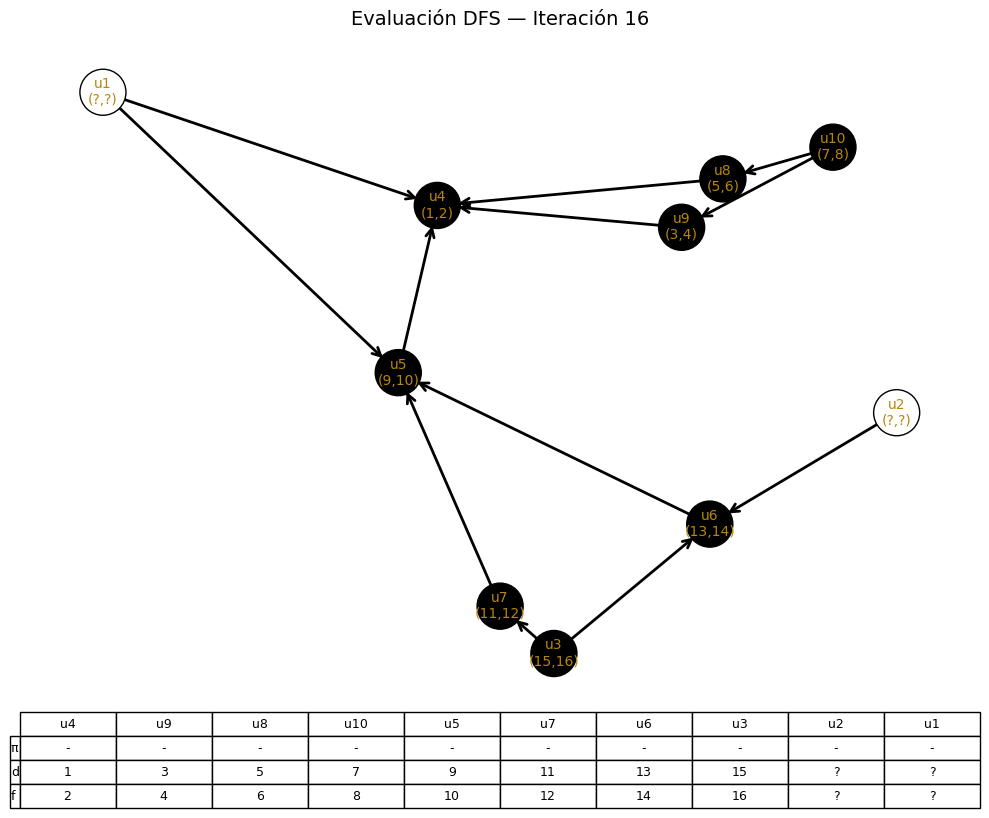

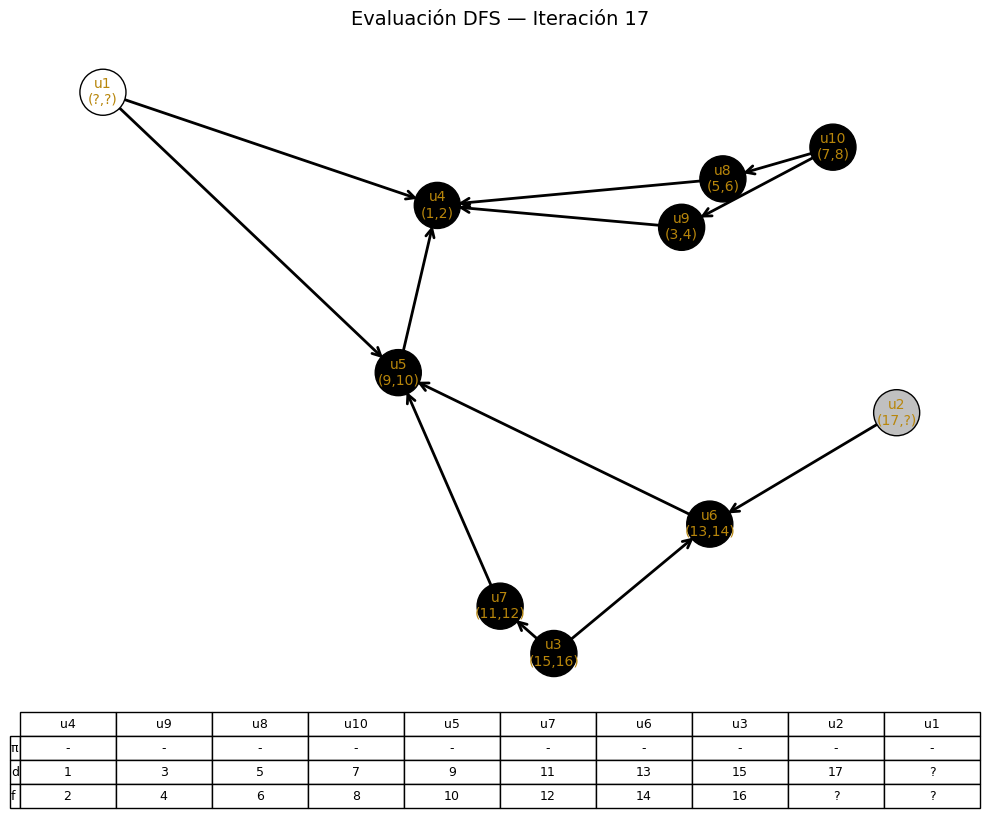

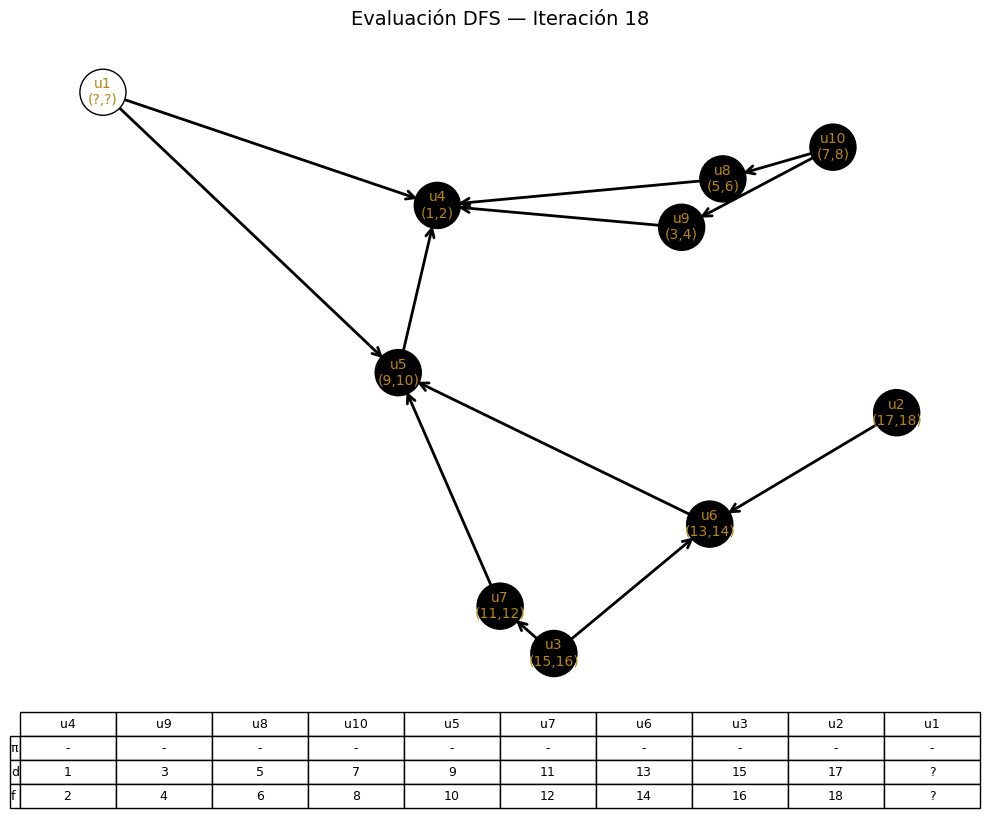

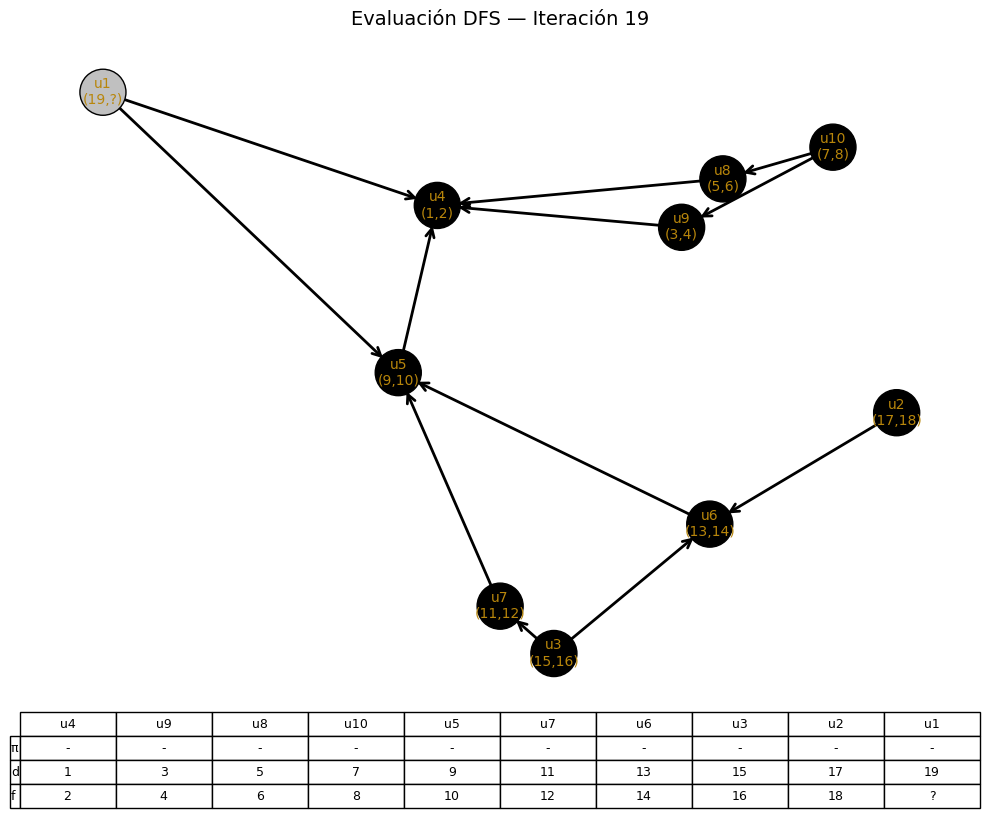

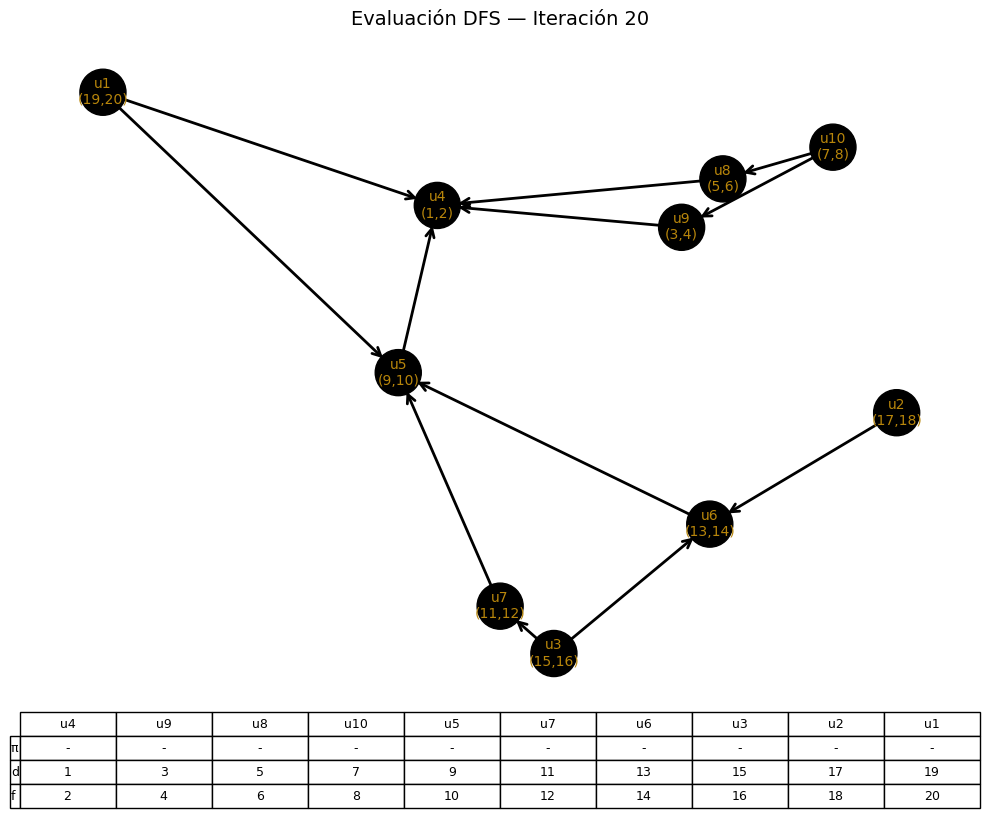

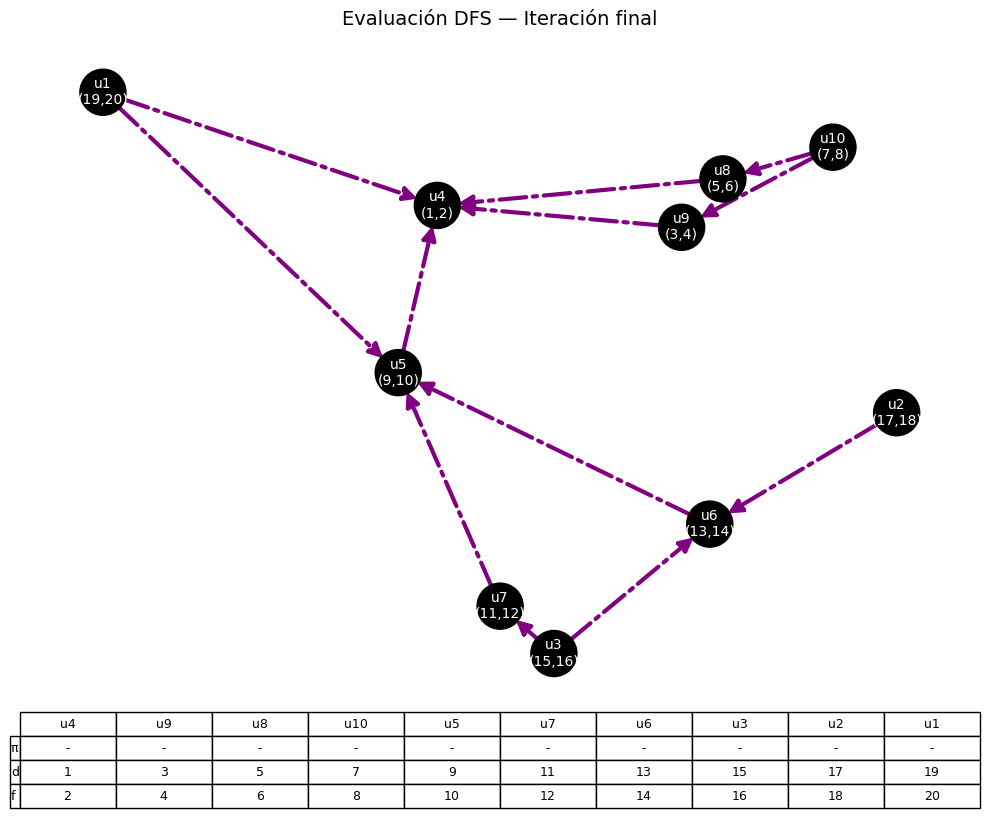

In [124]:
# orden segun f de DFS(G): 
# u4: 20, u9: 19, u8: 17, u10: 16, u5: 13, u7:12, u6:10, u3: 6, u2:4, u1: 2 

Gt = {
    "u4": [],
    "u9": ["u4"],
    "u8": ["u4"],
    "u10": ["u8", "u9"],
    "u5": ["u4"],
    "u7": ["u5"],
    "u6": ["u5"],
    "u3": ["u6", "u7"],
    "u2": ["u6"],
    "u1": ["u4", "u5"],
}

C, pi, d, f = DFS(Gt)

## Kruskal

In [131]:
import matplotlib.pyplot as plt
import networkx as nx
import random

def dibujar_grafo(G, w, A, ds, title="Grafo"):
    """
    G: grafo no dirigido con:
        G["V"] = lista de nodos
        G["E"] = lista de aristas (u,v)
    w: diccionario de pesos
    A: aristas del MST seleccionadas hasta el momento
    ds: estructura DisjointSet después de varias operaciones
    """

    # Construimos grafo de networkx
    G_nx = nx.Graph()
    for (u, v) in G["E"]:
        peso = w[(u, v)]
        G_nx.add_edge(u, v, weight=peso)

    # Layout fijo
    pos = {
        "u4":  (-0.28447425,  0.43847719),
        "u1":  (-0.93452791,  0.80182164),
        "u5":  (-0.36041391, -0.09830535),
        "u8":  ( 0.18048848,  0.80182164),
        "u9":  ( 0.19048848,  0.36829081),
        "u6":  ( 0.24521190, -0.58457109),
        "u7":  (-0.16237657, -0.58457109),
        "u2":  ( 0.60852263, -0.22693411),
        "u3":  (-0.05782809, -1.00000000),
        "u10": ( 0.48467156,  0.62551130)
    }

    # -----------------------------------------------
    # 1. Detección de componentes disjuntos (coloreo)
    # -----------------------------------------------
    comp_color = {}
    color_map = {}

    nodelist = list(G_nx.nodes())
    edgelist = list(G_nx.edges())
    print(f"node_list: {nodelist}")
    print(f"edgelist : {edgelist}")

    palette = plt.cm.tab10.colors  # lista de colores
    palette_size = len(palette)
    
    # Asignar color a cada componente disjunto
    for node in nodelist:
        rep = ds.find_set(node)
        if rep not in comp_color:
            # generar un color
            comp_index = len(comp_color) % palette_size
            comp_color[rep] = palette[comp_index]
        color_map[node] = comp_color[rep]

    node_colors = [color_map[n] for n in nodelist]

    ##

    ##

    # -----------------------------------------------
    # 2. Colores de aristas
    #   - A: rojo
    #   - resto: gris
    # -----------------------------------------------

    edge_colors = []
    for e in edgelist:
        if e in A or (e[1], e[0]) in A:   # por si viene invertida
            edge_colors.append("red")
        else:
            edge_colors.append("gray")
    print(f"edges: {G["E"]}")
    print(f"edge_colors: {edge_colors}")
    # -----------------------------------------------
    # 3. Dibujar nodos y aristas
    # -----------------------------------------------
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(
        G_nx, pos,
        node_color=node_colors,
        edgecolors="black",
        node_size=900
    )

    nx.draw_networkx_edges(
        G_nx, pos,
        edge_color=edge_colors,
        width=3
    )

    # Etiquetas de nodos
    nx.draw_networkx_labels(
        G_nx, pos,
        font_size=10,
        font_color="white"
    )

    # -----------------------------------------------
    # 4. Etiquetas de peso en las aristas
    # -----------------------------------------------
    edge_labels = {(u, v): w[(u, v)] for (u, v) in G["E"]}
    nx.draw_networkx_edge_labels(
        G_nx, pos,
        edge_labels=edge_labels,
        font_color="black"
    )

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()


edges_sorted:[('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u5', 'u7'), ('u9', 'u10'), ('u6', 'u2'), ('u4', 'u8'), ('u4', 'u1'), ('u4', 'u9'), ('u8', 'u10')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray']


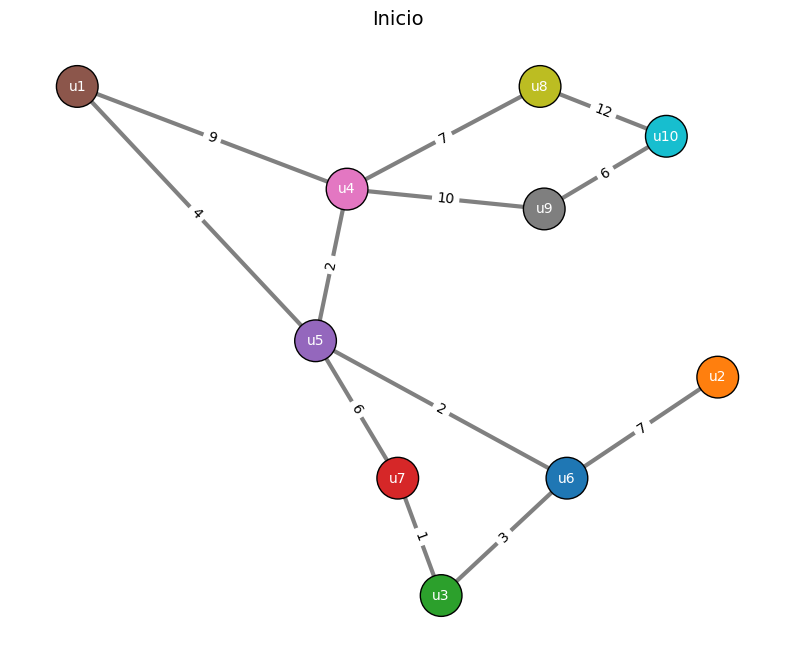

A: [('u7', 'u3')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'gray', 'gray', 'red', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray']


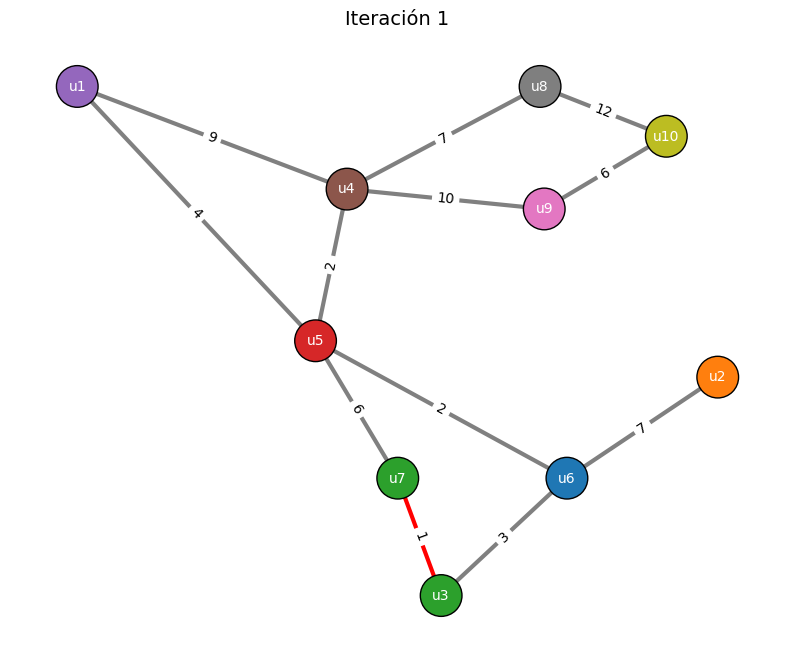

A: [('u7', 'u3'), ('u5', 'u6')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'gray', 'red', 'red', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray']


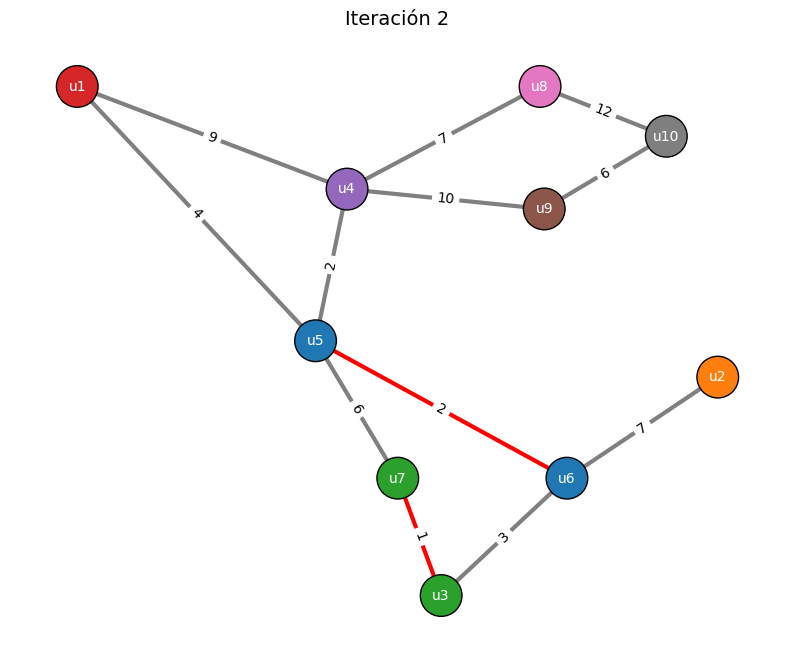

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'gray', 'red', 'red', 'gray', 'gray', 'red', 'gray', 'gray', 'gray', 'gray', 'gray']


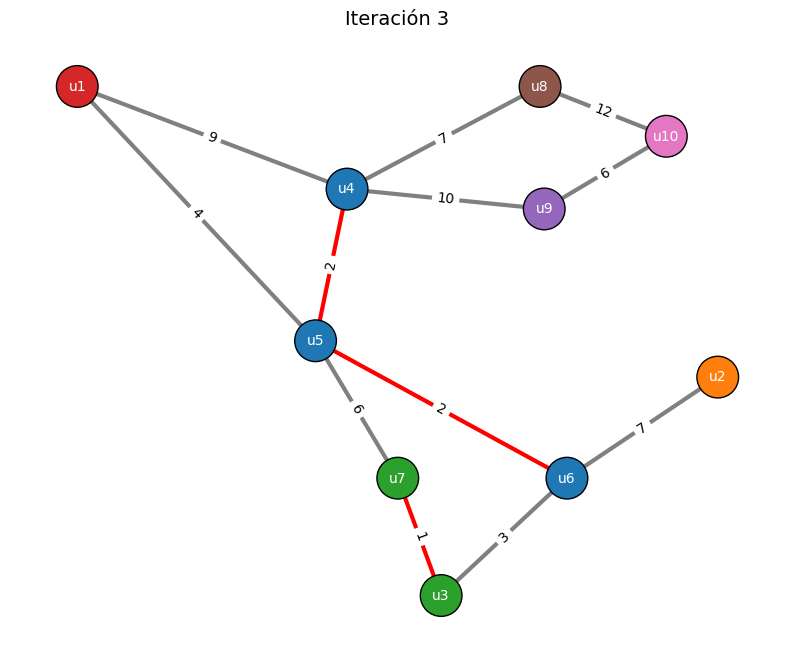

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'red', 'red', 'red', 'gray', 'gray', 'red', 'gray', 'gray', 'gray', 'gray', 'gray']


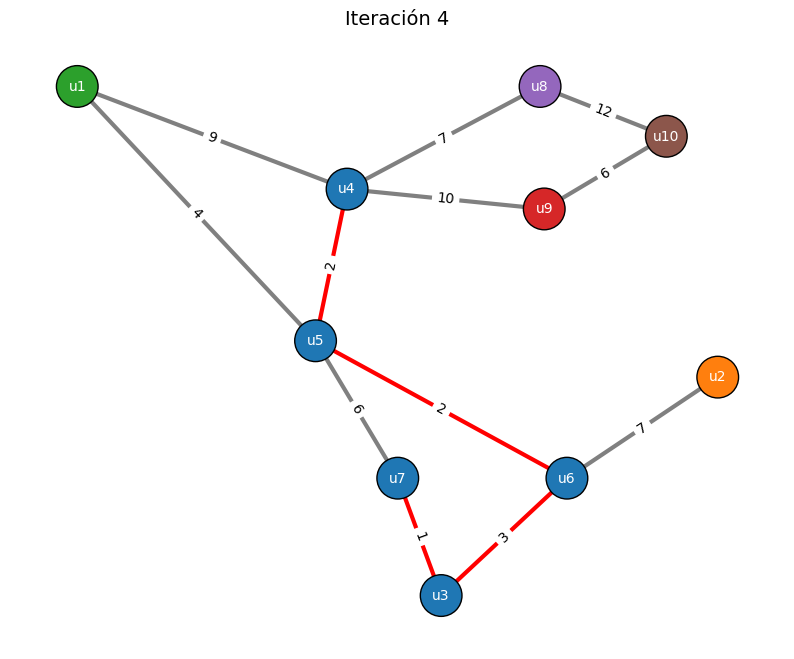

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'gray', 'gray', 'gray', 'gray']


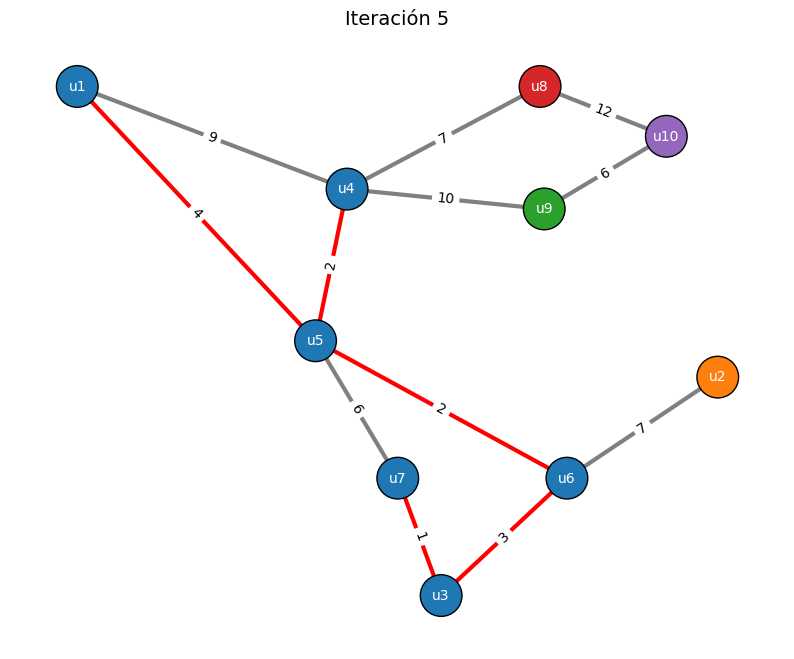

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'gray', 'gray', 'gray', 'gray']


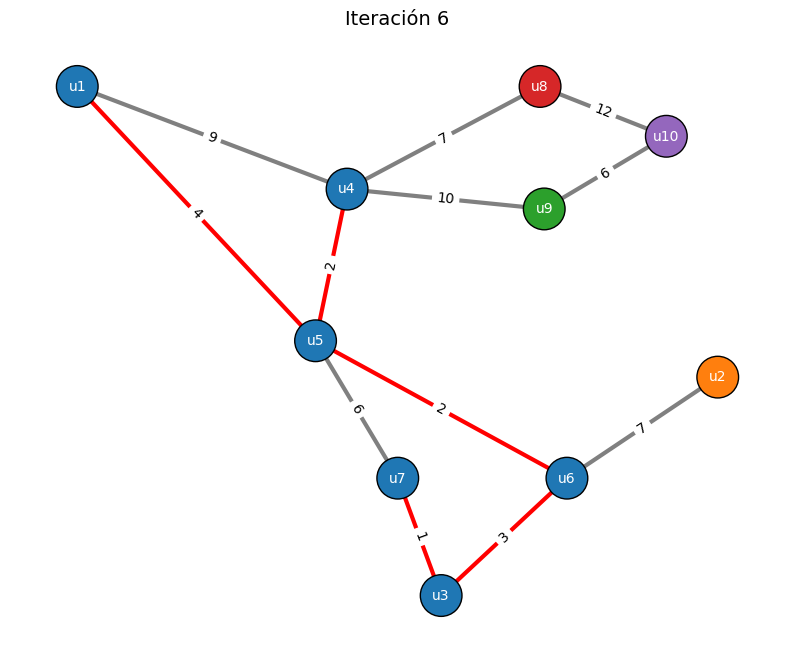

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u9', 'u10')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['gray', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'gray', 'gray', 'red', 'gray']


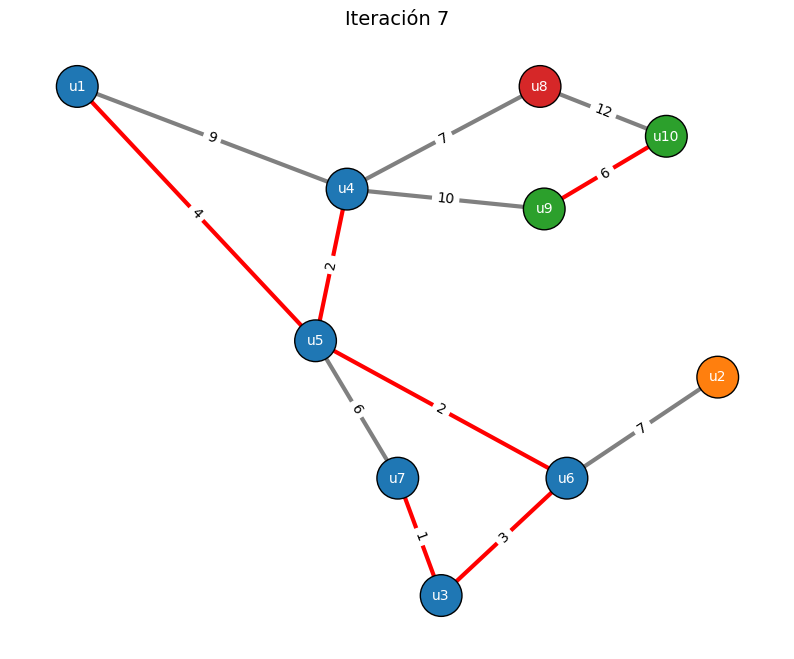

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u9', 'u10'), ('u6', 'u2')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['red', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'gray', 'gray', 'red', 'gray']


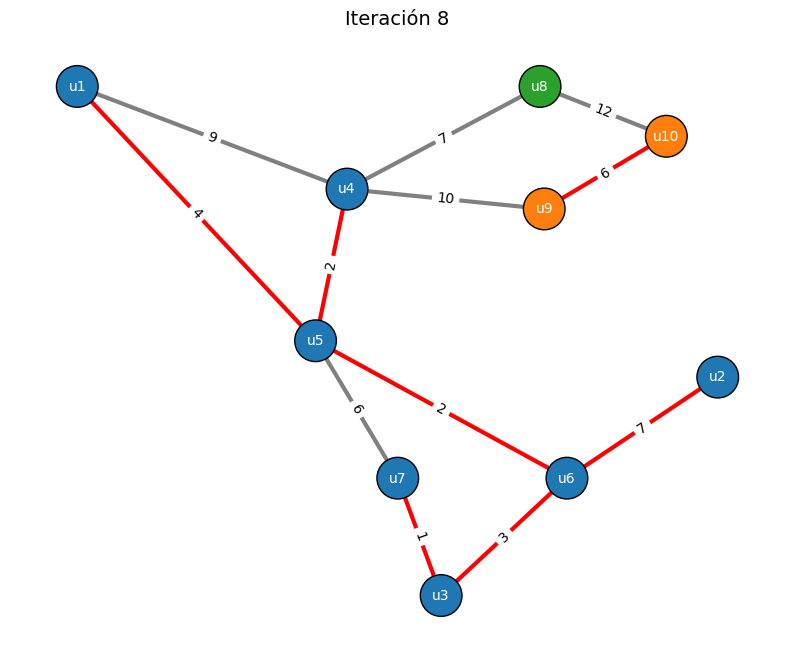

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u9', 'u10'), ('u6', 'u2'), ('u4', 'u8')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['red', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'gray', 'red', 'red', 'gray']


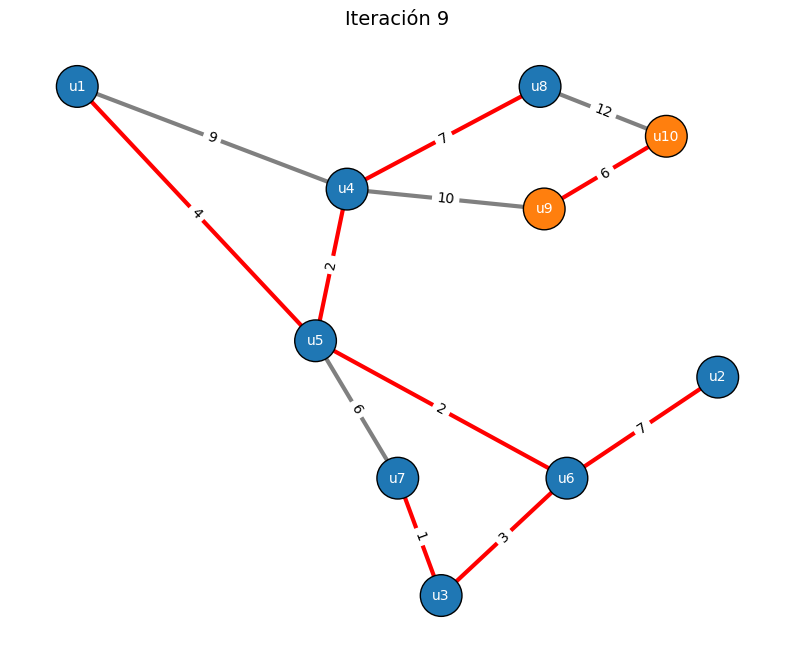

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u9', 'u10'), ('u6', 'u2'), ('u4', 'u8')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['red', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'gray', 'red', 'red', 'gray']


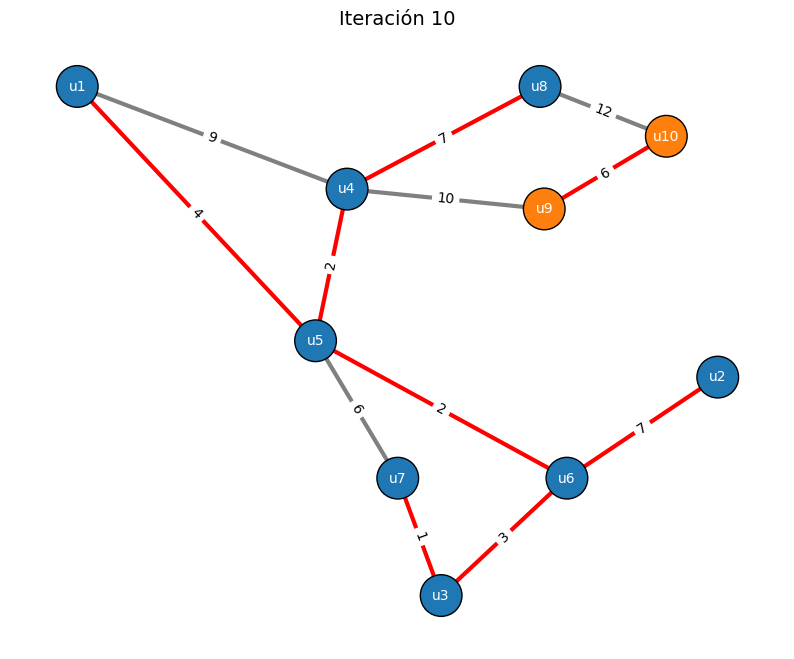

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u9', 'u10'), ('u6', 'u2'), ('u4', 'u8'), ('u4', 'u9')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['red', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'red', 'red', 'red', 'gray']


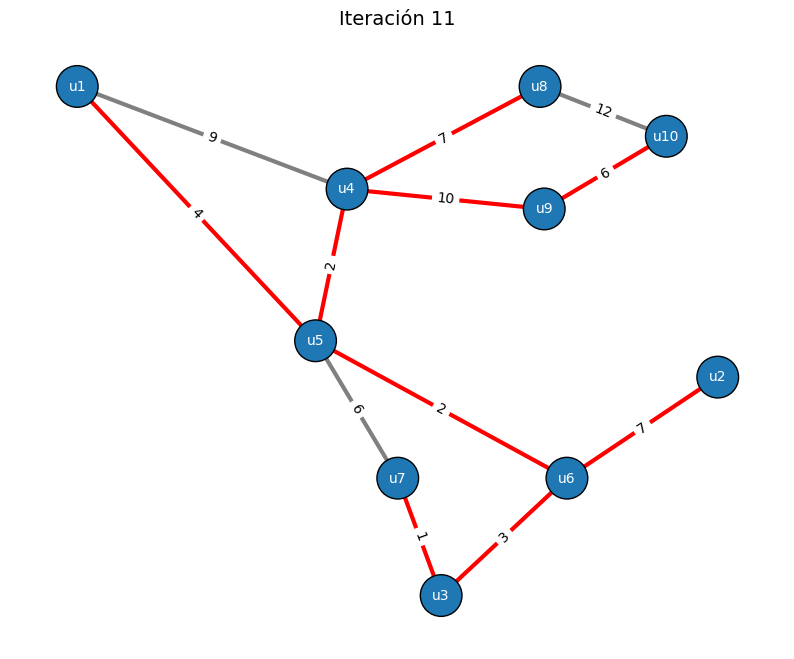

A: [('u7', 'u3'), ('u5', 'u6'), ('u4', 'u5'), ('u6', 'u3'), ('u5', 'u1'), ('u9', 'u10'), ('u6', 'u2'), ('u4', 'u8'), ('u4', 'u9')]
node_list: ['u6', 'u2', 'u3', 'u7', 'u5', 'u1', 'u4', 'u9', 'u8', 'u10']
edgelist : [('u6', 'u2'), ('u6', 'u3'), ('u6', 'u5'), ('u3', 'u7'), ('u7', 'u5'), ('u5', 'u1'), ('u5', 'u4'), ('u1', 'u4'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edges: [('u6', 'u2'), ('u6', 'u3'), ('u7', 'u3'), ('u5', 'u7'), ('u5', 'u1'), ('u5', 'u6'), ('u4', 'u5'), ('u4', 'u1'), ('u4', 'u9'), ('u4', 'u8'), ('u9', 'u10'), ('u8', 'u10')]
edge_colors: ['red', 'red', 'red', 'red', 'gray', 'red', 'red', 'gray', 'red', 'red', 'red', 'gray']


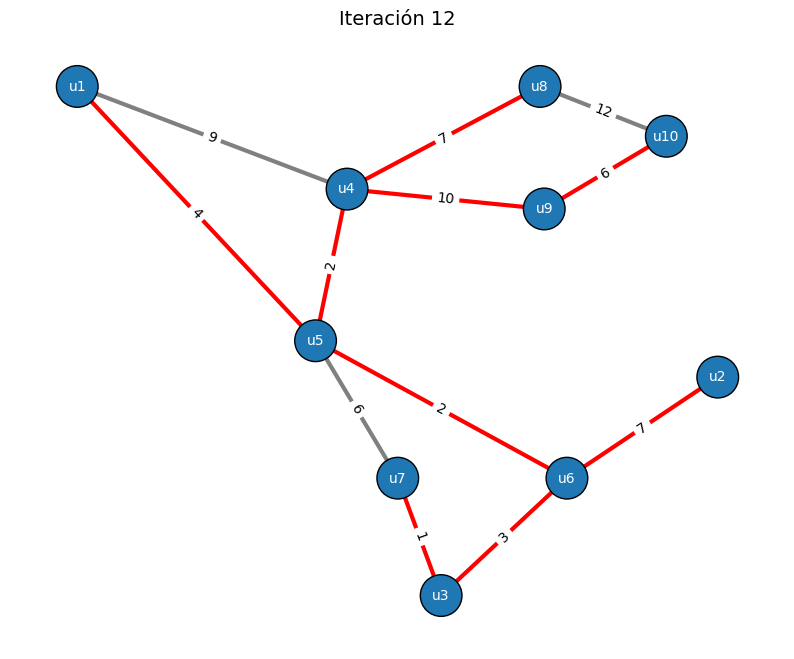

Árbol de expansión mínima (MST) usando Kruskal:
('u7', 'u3')  peso=1
('u5', 'u6')  peso=2
('u4', 'u5')  peso=2
('u6', 'u3')  peso=3
('u5', 'u1')  peso=4
('u9', 'u10')  peso=6
('u6', 'u2')  peso=7
('u4', 'u8')  peso=7
('u4', 'u9')  peso=10

Costo total del MST: 42


In [132]:
# ===========================================================
#          IMPLEMENTACIÓN DEL ALGORITMO DE KRUSKAL
# ===========================================================

# ------------------------------
#      DISJOINT SET (UFDS)
# ------------------------------
class DisjointSet:
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def make_set(self, v):
        self.parent[v] = v
        self.rank[v] = 0

    def find_set(self, v):
        if self.parent[v] != v:
            self.parent[v] = self.find_set(self.parent[v])   # compresión de caminos
        return self.parent[v]

    def union(self, u, v):
        ru = self.find_set(u)
        rv = self.find_set(v)
        if ru != rv:
            # unión por rango
            if self.rank[ru] < self.rank[rv]:
                self.parent[ru] = rv
            elif self.rank[ru] > self.rank[rv]:
                self.parent[rv] = ru
            else:
                self.parent[rv] = ru
                self.rank[ru] += 1


# ------------------------------
#         KRUSKAL
# ------------------------------
def MST_Kruskal(G, w):
    """
    G = (V, E)
    G["V"] = lista de vértices
    G["E"] = lista de aristas (u,v)
    w: diccionario con pesos  w[(u,v)]
    """

    A = []                          # conjunto solución
    ds = DisjointSet()
    
    # MAKE-SET para cada vértice
    for v in G["V"]:
        ds.make_set(v)

    # ordenar aristas por peso no decreciente
    edges_sorted = sorted(G["E"], key=lambda e: w[e])
    print(f"edges_sorted:{edges_sorted}")

    dibujar_grafo(G, w, A, ds, title=f"Inicio")

    ite = 1
    # elegir aristas en ese orden
    for (u, v) in edges_sorted:
        if ds.find_set(u) != ds.find_set(v):
            A.append((u, v))        # añadir a MST
            ds.union(u, v)
        print(f"A: {A}")
        dibujar_grafo(G, w, A, ds, title=f"Iteración {ite}")
        ite += 1

    return A


# ===========================================================
#                 EJEMPLO DE USO
# ===========================================================

if __name__ == "__main__":
    # Grafo de ejemplo
    G = {
        "V": ["u1","u2","u3","u4","u5","u6","u7","u8","u9","u10"],
        "E": [
            ("u6","u2"),
            ("u6","u3"),
            ("u7","u3"),
            ("u5","u7"),
            ("u5","u1"),
            ("u5","u6"),
            ("u4","u5"),
            ("u4","u1"),
            ("u4","u9"),
            ("u4","u8"),
            ("u9","u10"),
            ("u8","u10")
        ]
    }

    w = {
        ("u6","u2"): 7,
        ("u6","u3"): 3,
        ("u7","u3"): 1,
        ("u5","u7"): 6,
        ("u5","u1"): 4,
        ("u5","u6"): 2,
        ("u4","u5"): 2,
        ("u4","u1"): 9,
        ("u4","u9"): 10,
        ("u4","u8"): 7,
        ("u9","u10"): 6,
        ("u8","u10"): 12
    }

    mst = MST_Kruskal(G, w)

    print("Árbol de expansión mínima (MST) usando Kruskal:")
    costo = sum(w[e] for e in mst)
    for e in mst:
        print(f"{e}  peso={w[e]}")

    print("\nCosto total del MST:", costo)


## Prim

In [145]:
def graficar_estado(G, Q, w, titulo="Grafo — estado"):
    import matplotlib.pyplot as plt
    import networkx as nx
    import math

    # nodes: lista de objetos Vertex
    nodes = list(G.keys())
    name_of = {v: v.name for v in nodes}
    obj_of = {v.name: v for v in nodes}
    node_names = [v.name for v in nodes]

    # Q puede ser heap/list --> normalizar a conjunto de objetos Vertex
    try:
        Q_list = list(Q)
    except Exception:
        Q_list = []
    Q_set = set(Q_list)

    # construir grafo (no dirigido) usando nombres
    G_nx = nx.Graph()
    for u in nodes:
        u_name = u.name
        G_nx.add_node(u_name)
        for v in G[u]:
            v_name = v.name
            G_nx.add_node(v_name)
            if not G_nx.has_edge(u_name, v_name):
                G_nx.add_edge(u_name, v_name)

    # determinar aristas pi: (pi -> v) sólo para v que ya NO están en Q (G-Q)
    pi_edges = []
    for v in nodes:
        if v.pi is not None and v not in Q_set:
            p = v.pi
            # confirmar que la arista existe en el grafo de visualización
            if G_nx.has_edge(p.name, v.name):
                pi_edges.append((p.name, v.name))

    # colores nodos: en Q vs fuera de Q
    color_in_Q = "#FFA500"    # naranja -> nodos que aún están en Q
    color_out_Q = "#808080"   # gris -> nodos en G - Q
    nodelist = list(G_nx.nodes())
    print(f"nodelist {nodelist}")
    Qlist = [obj.name for obj in Q_list]
    print(f"qset {Qlist}")
    node_colors = [color_in_Q if v in Qlist else color_out_Q for v in nodelist]

    # preparar etiquetas de nodos: nombre + key si existe
    labels = {}
    for v in nodes:
        k = getattr(v, "key", None)
        if isinstance(k, float) and k == math.inf:
            ktxt = "∞"
        elif k is None:
            ktxt = "-"
        else:
            ktxt = str(k)
        labels[v.name] = f"{v.name}\nkey={ktxt}"

    # preparar etiquetas de peso para cada arista (usar w(u_obj, v_obj))
    edge_labels = {}
    for (a, b) in G_nx.edges():
        u_obj = obj_of.get(a)
        v_obj = obj_of.get(b)
        peso = None
        try:
            if callable(w) and u_obj is not None and v_obj is not None:
                peso = w(u_obj, v_obj)
        except Exception:
            peso = None
        if peso is None:
            edge_labels[(a, b)] = ""
        else:
            edge_labels[(a, b)] = str(peso)

    # dibujo
    plt.figure(figsize=(11, 8))
    pos = nx.spring_layout(G_nx, seed=42)
    print(f"pos: {pos}")

    pos2 = {
        "u1":  (-0.93452791,  0.80182164),
        "u5":  (-0.36041391, -0.09830535),
        "u4":  (-0.28447425,  0.43847719),
        "u2":  ( 0.60852263, -0.22693411),
        "u6":  ( 0.24521190, -0.58457109),
        "u3":  (-0.05782809, -1.00000000),
        "u7":  (-0.16237657, -0.58457109),
        "u9":  ( 0.19048848,  0.36829081),
        "u8":  ( 0.18048848,  0.80182164),
        "u10": ( 0.48467156,  0.62551130)
    }

    nx.draw_networkx_nodes(G_nx, pos,
                           node_color=node_colors,
                           node_size=1000,
                           edgecolors="black")

    # aristas normales (excluir pi_edges)
    pi_edge_set = set(pi_edges)
    normal_edges = [e for e in G_nx.edges() if (e not in pi_edge_set and (e[1], e[0]) not in pi_edge_set)]
    nx.draw_networkx_edges(G_nx, pos, edgelist=normal_edges, width=2, edge_color="#C0C0C0")

    # aristas pi resaltadas (rojo)
    if pi_edges:
        nx.draw_networkx_edges(G_nx, pos, edgelist=pi_edges, width=4, edge_color="red")

    # etiquetas nodos y de aristas
    nx.draw_networkx_labels(G_nx, pos, labels=labels, font_color="black", font_size=9)
    nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=edge_labels, font_color="black")

    plt.title(titulo, fontsize=14)

    # tabla debajo: columnas = nodos, filas = [pi, key]
    col_labels = node_names
    pi_row = [ (v.pi.name if v.pi is not None else "-") for v in nodes ]
    key_row = [ ("∞" if (isinstance(v.key, float) and v.key == math.inf) else ("-" if v.key is None else str(v.key))) for v in nodes ]

    the_table = plt.table(cellText=[pi_row, key_row],
                          colLabels=col_labels,
                          rowLabels=["π", "key"],
                          loc="bottom",
                          cellLoc="center")
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(9)
    the_table.scale(1, 1.2)

    plt.subplots_adjust(left=0.05, bottom=0.25)
    plt.axis("off")
    plt.show()

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u4', 'u10', 'u7', 'u9', 'u5', 'u6', 'u3', 'u8', 'u2', 'u1']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


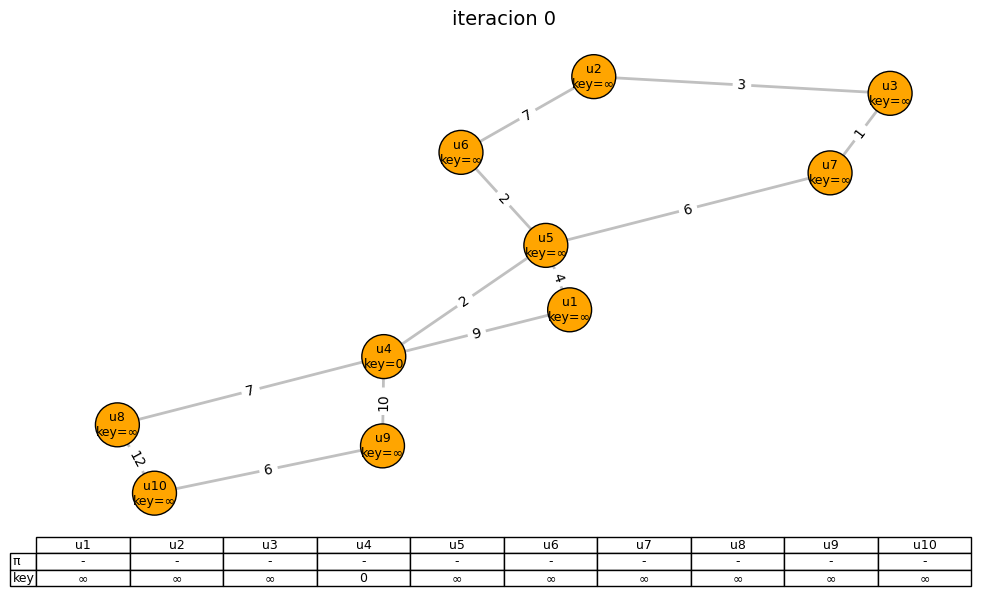

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u5', 'u8', 'u10', 'u1', 'u7', 'u3', 'u6', 'u2', 'u9']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


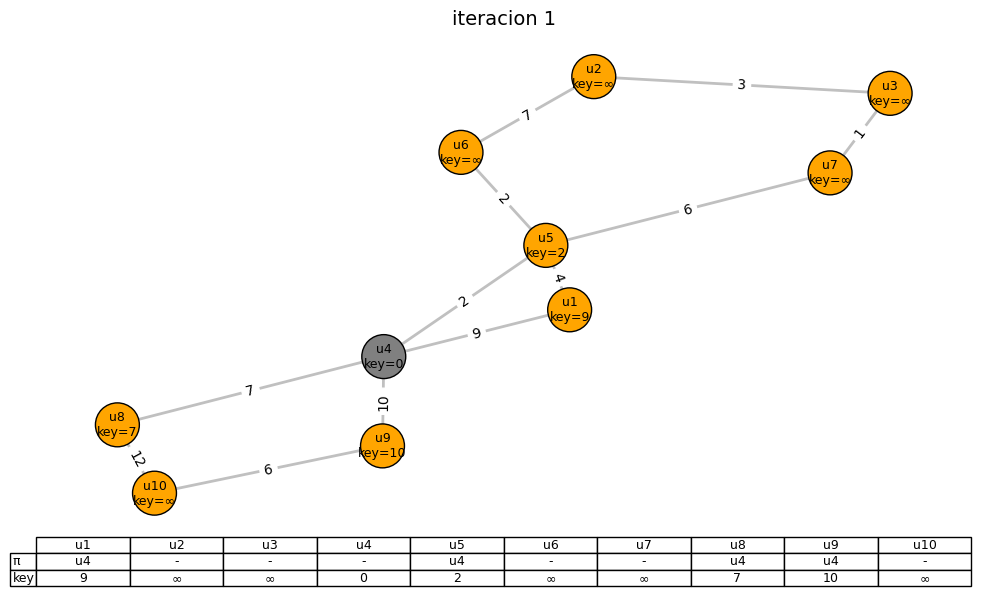

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u6', 'u1', 'u9', 'u7', 'u10', 'u2', 'u3', 'u8']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


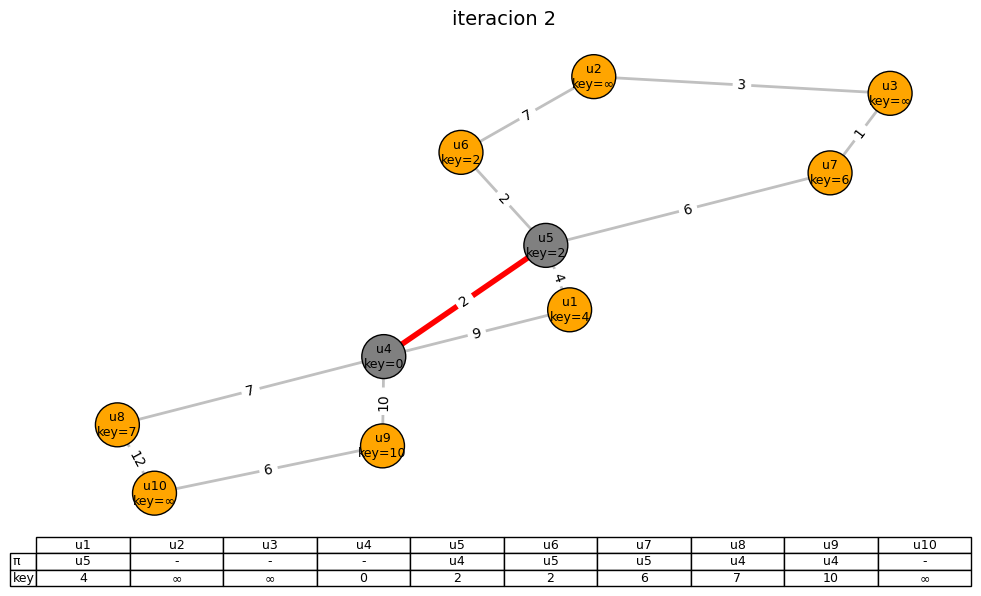

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u1', 'u7', 'u2', 'u8', 'u10', 'u3', 'u9']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


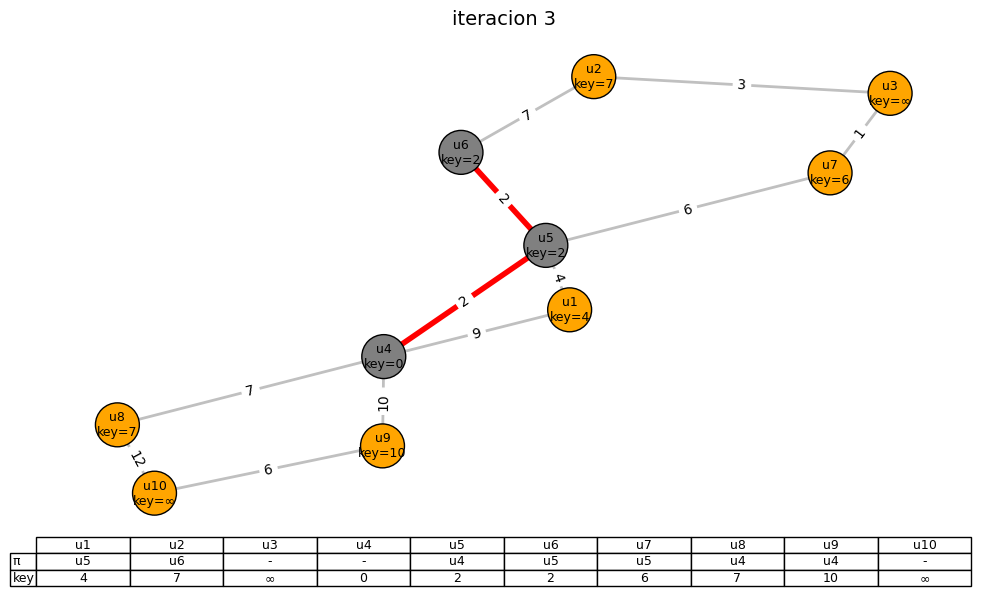

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u7', 'u8', 'u2', 'u9', 'u10', 'u3']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


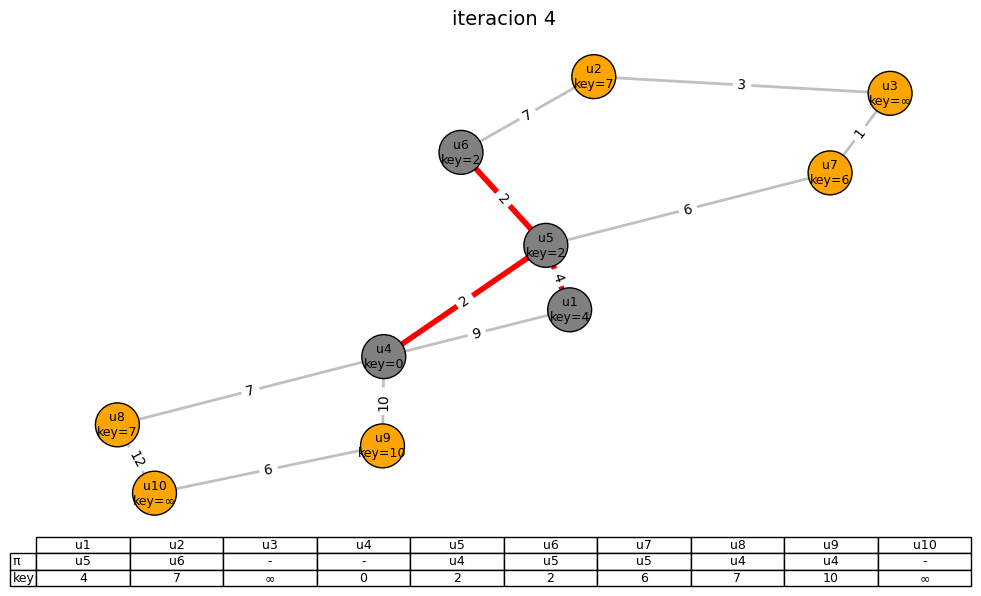

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u3', 'u8', 'u9', 'u10', 'u2']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


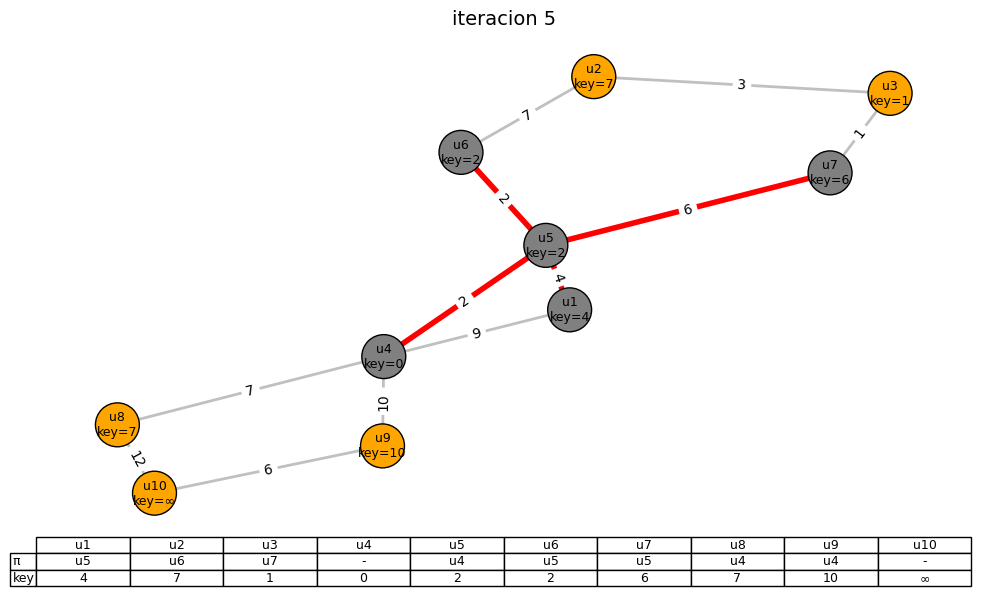

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u2', 'u8', 'u10', 'u9']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


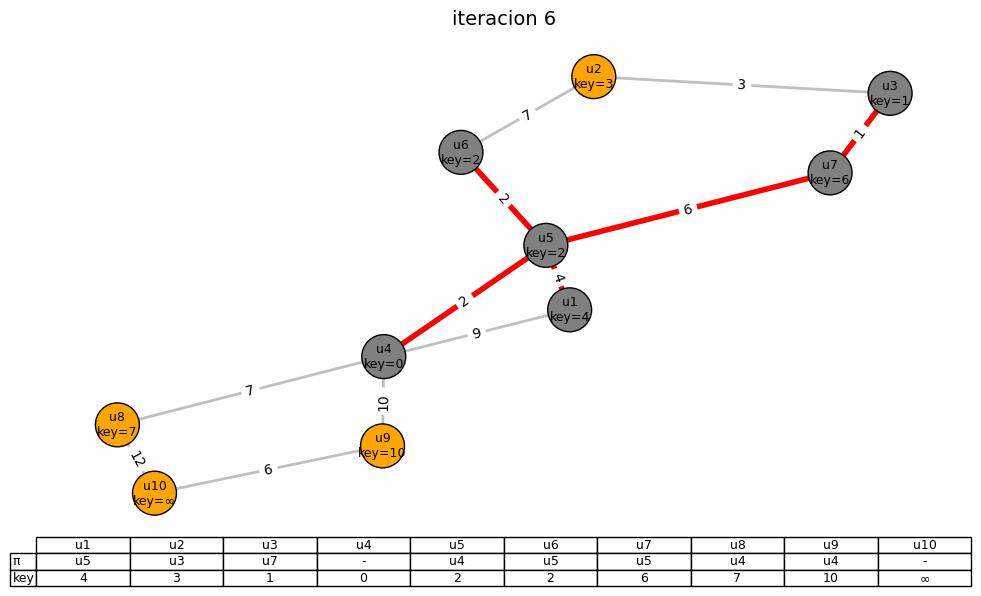

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u8', 'u9', 'u10']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


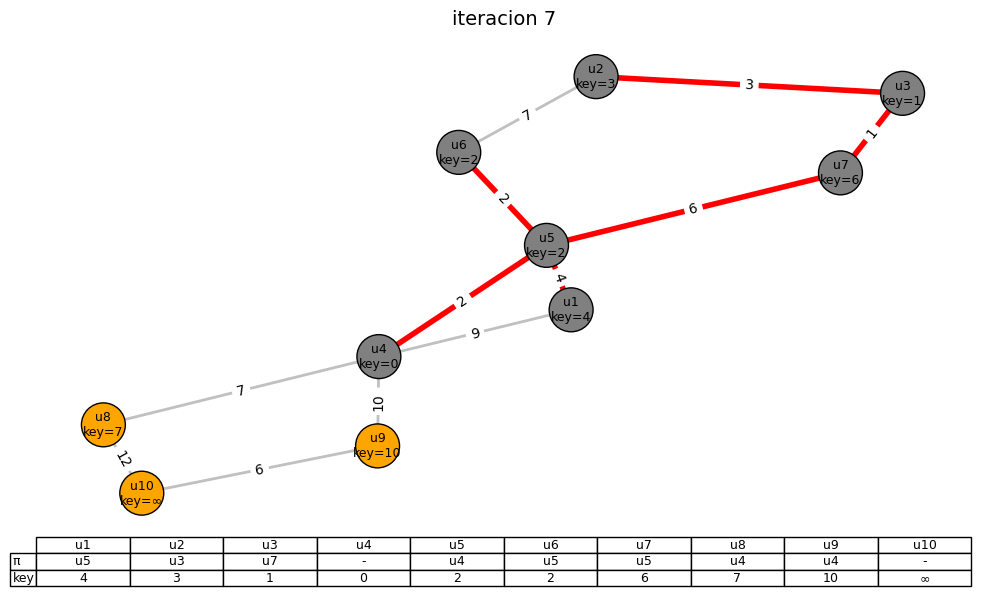

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u9', 'u10']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


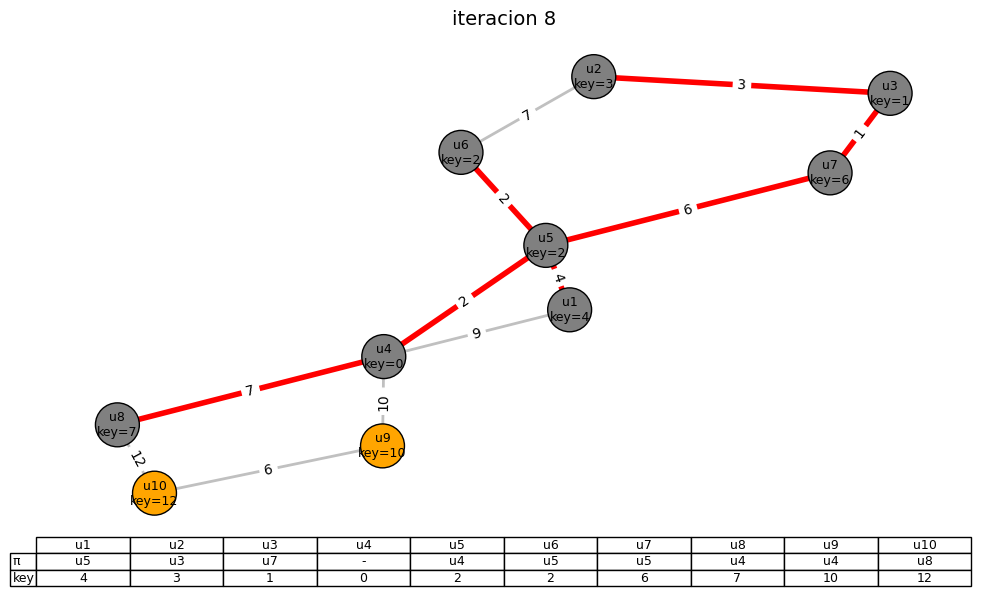

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset ['u10']
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


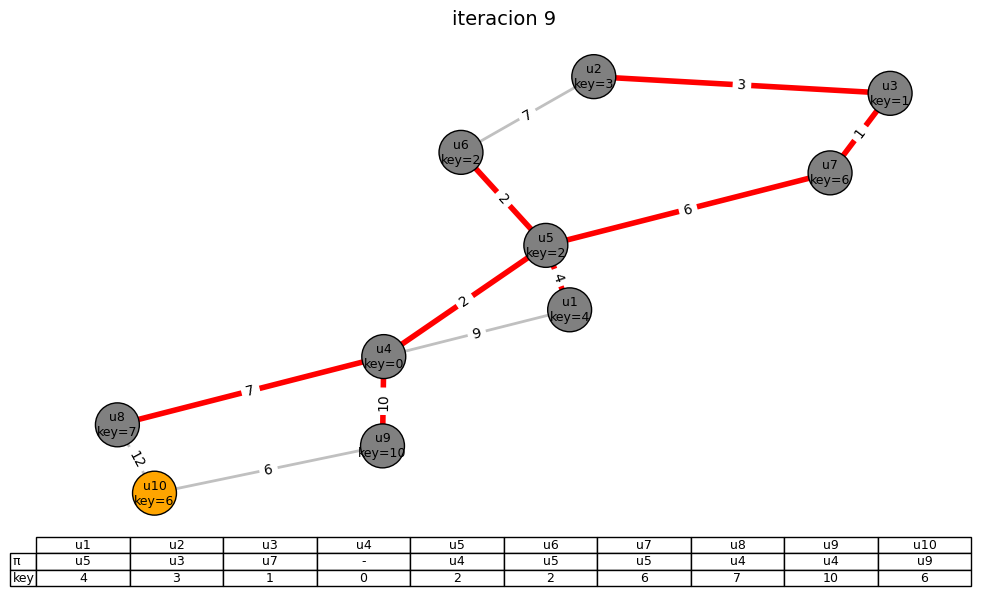

nodelist ['u1', 'u5', 'u4', 'u2', 'u6', 'u3', 'u7', 'u9', 'u8', 'u10']
qset []
pos: {'u1': array([ 0.07711599, -0.15144401]), 'u5': array([0.0532153 , 0.14675987]), 'u4': array([-0.10956381, -0.36795759]), 'u2': array([0.1013656 , 0.92764485]), 'u6': array([-0.03200853,  0.57720588]), 'u3': array([0.39899358, 0.85041139]), 'u7': array([0.33868935, 0.48232905]), 'u9': array([-0.11084258, -0.78121391]), 'u8': array([-0.37712024, -0.68373553]), 'u10': array([-0.33984466, -1.        ])}


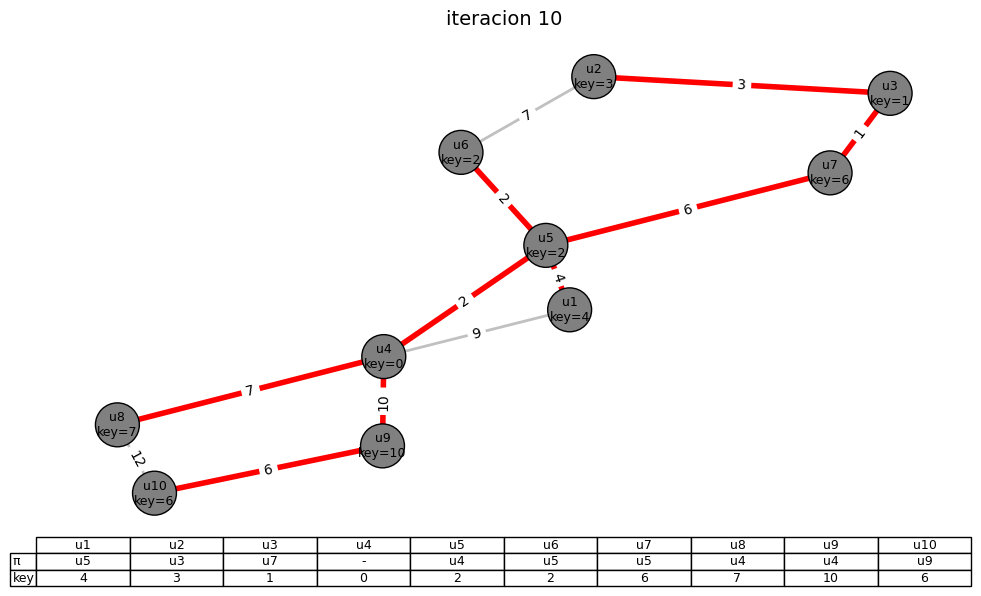

Aristas del MST:
u5 -- u1  (peso 4)
u3 -- u2  (peso 3)
u7 -- u3  (peso 1)
u4 -- u5  (peso 2)
u5 -- u6  (peso 2)
u5 -- u7  (peso 6)
u4 -- u8  (peso 7)
u4 -- u9  (peso 10)
u9 -- u10  (peso 6)


In [146]:
import heapq
import math

class Vertex:
    def __init__(self, name):
        self.name = name
        self.key = math.inf
        self.pi = None   # padre en el MST

    def __lt__(self, other):
        # necesario para heapq
        return self.key < other.key


def prim_mst(G, w, r):
    """
    G: diccionario con listas de adyacencia {u: [v1, v2, ...]}
    w: función peso: w(u, v)
    r: vértice raíz
    """

    # Inicialización (líneas 1–4)
    for u in G:
        u.key = math.inf
        u.pi = None

    r.key = 0

    # Cola de prioridad Q (líneas 5–7)
    Q = list(G.keys())
    heapq.heapify(Q)

    graficar_estado(G, Q, w, titulo="iteracion 0")

    ite = 1
    # Mientras Q no esté vacía (línea 8)
    while Q:
        # Extract-Min (línea 9)
        u = heapq.heappop(Q)

        # Relajar aristas (líneas 10–14)
        for v in G[u]:
            if v in Q and w(u, v) < v.key:
                v.pi = u
                v.key = w(u, v)
                Q.remove(v)
                heapq.heapify(Q)
                heapq.heappush(Q, v)
        
        graficar_estado(G, Q, w, titulo=f"iteracion {ite}")
        ite += 1
    
    # Retornar los bordes del MST
    mst_edges = []
    for u in G:
        if u.pi is not None:
            mst_edges.append((u.pi.name, u.name, w(u.pi, u)))

    return mst_edges

# Crear vértices
u1 = Vertex("u1")
u2 = Vertex("u2")
u3 = Vertex("u3")
u4 = Vertex("u4")
u5 = Vertex("u5")
u6 = Vertex("u6")
u7 = Vertex("u7")
u8 = Vertex("u8")
u9 = Vertex("u9")
u10 = Vertex("u10")


# Grafo no dirigido
G = {
    u1: [u5, u4],
    u2: [u6, u3],
    u3: [u2, u7],
    u4: [u5, u1, u9, u8],
    u5: [u7, u1, u6, u4],
    u6: [u2, u5],
    u7: [u3, u5],
    u8: [u4, u10],
    u9: [u4, u10],
    u10: [u9, u8]
}


# Función de pesos
import math

def w(u, v):

    pesos = {
        ("u2","u6"): 7,
        ("u3","u2"): 3,
        ("u7","u3"): 1,
        ("u7","u5"): 6,
        ("u1","u5"): 4,
        ("u6","u5"): 2,
        ("u4","u5"): 2,
        ("u4","u1"): 9,
        ("u4","u9"): 10,
        ("u4","u8"): 7,
        ("u9","u10"): 6,
        ("u8","u10"): 12
    }

    # grafo no dirigido → permitir ambas direcciones
    if (u.name, v.name) in pesos:
        return pesos[(u.name, v.name)]
    if (v.name, u.name) in pesos:
        return pesos[(v.name, u.name)]

    return math.inf


mst = prim_mst(G, w, u4)

print("Aristas del MST:")
for u, v, peso in mst:
    print(f"{u} -- {v}  (peso {peso})")


## Dijkstra

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_graph_with_labels(G, d, pi, w, filename=None, figsize=(10,8), seed=42):
    # Crear grafo dirigido
    g = nx.DiGraph()
    g.add_nodes_from(G["V"])
    g.add_edges_from(G["E"])

    # Layout (reproducible)
    pos = nx.spring_layout(g, seed=seed)
    pos = {
        "u4":  (-0.28447425,  0.43847719),
        "u1":  (-0.93452791,  0.80182164),
        "u5":  (-0.36041391, -0.09830535),
        "u8":  ( 0.18048848,  0.80182164),
        "u9":  ( 0.19048848,  0.36829081),
        "u6":  ( 0.24521190, -0.58457109),
        "u7":  (-0.16237657, -0.58457109),
        "u2":  ( 0.60852263, -0.22693411),
        "u3":  (-0.05782809, -1.00000000),
        "u10": ( 0.48467156,  0.62551130)
    }

    fig, ax = plt.subplots(figsize=figsize)

    # Dibujar nodos (sin etiquetas por ahora)
    nx.draw_networkx_nodes(g, pos, node_size=800, ax=ax)
    nx.draw_networkx_edges(g, pos, arrows=True, arrowstyle='-|>', arrowsize=18, ax=ax)

    # Preparar etiquetas de nodos: nombre en la primera línea, (d, pi) en la segunda
    def pretty_distance(val):
        if val is None:
            return "None"
        try:
            if val == float("inf"):
                return "∞"
        except Exception:
            pass
        return str(val)

    node_labels = {}
    for v in G["V"]:
        dv = d.get(v, float("inf"))
        piv = pi.get(v, None)
        label = f"{v}\n(d={pretty_distance(dv)}, π={pretty_distance(piv)})"
        node_labels[v] = label

    nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=9, ax=ax)

    # Etiquetas de arista (pesos). Si falta un peso, se muestra '?'
    edge_labels = {}
    for (u, v) in G["E"]:
        edge_labels[(u, v)] = str(w.get((u, v), "?"))

    # Ajustar desplazamiento de las etiquetas de arista para que no se sobrepongan demasiado
    nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_size=9, label_pos=0.5, ax=ax)

    ax.set_axis_off()
    plt.tight_layout()

    # if filename:
    #     plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.title(filename)
    plt.show()
    return fig, ax


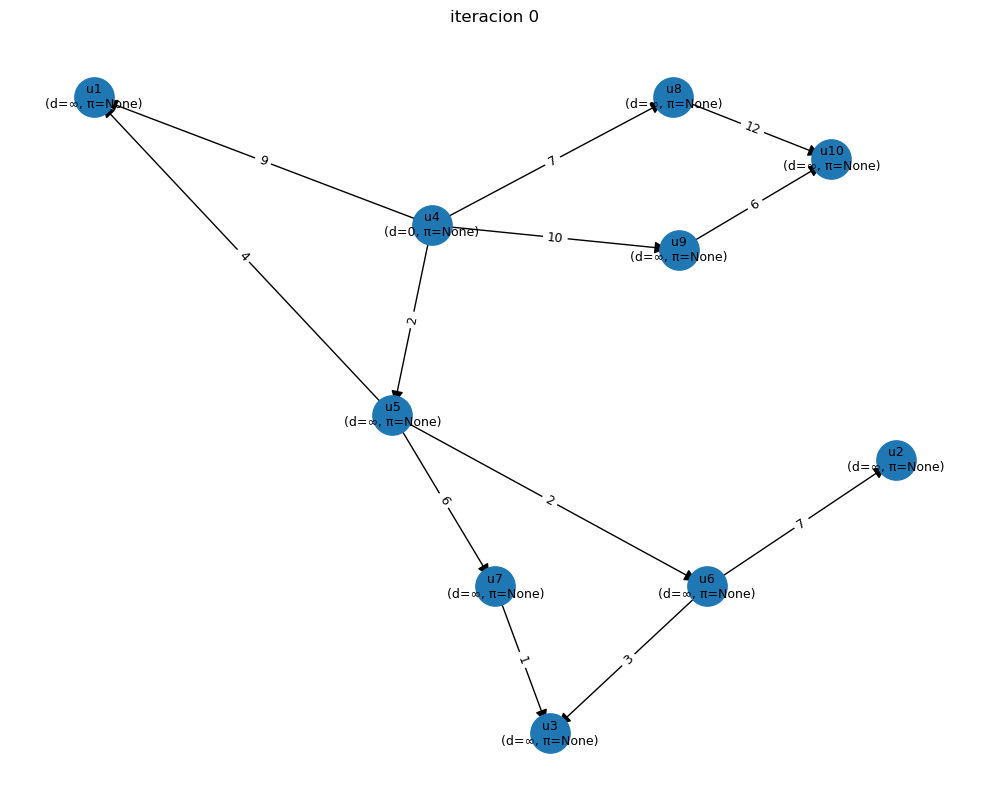

S: set()


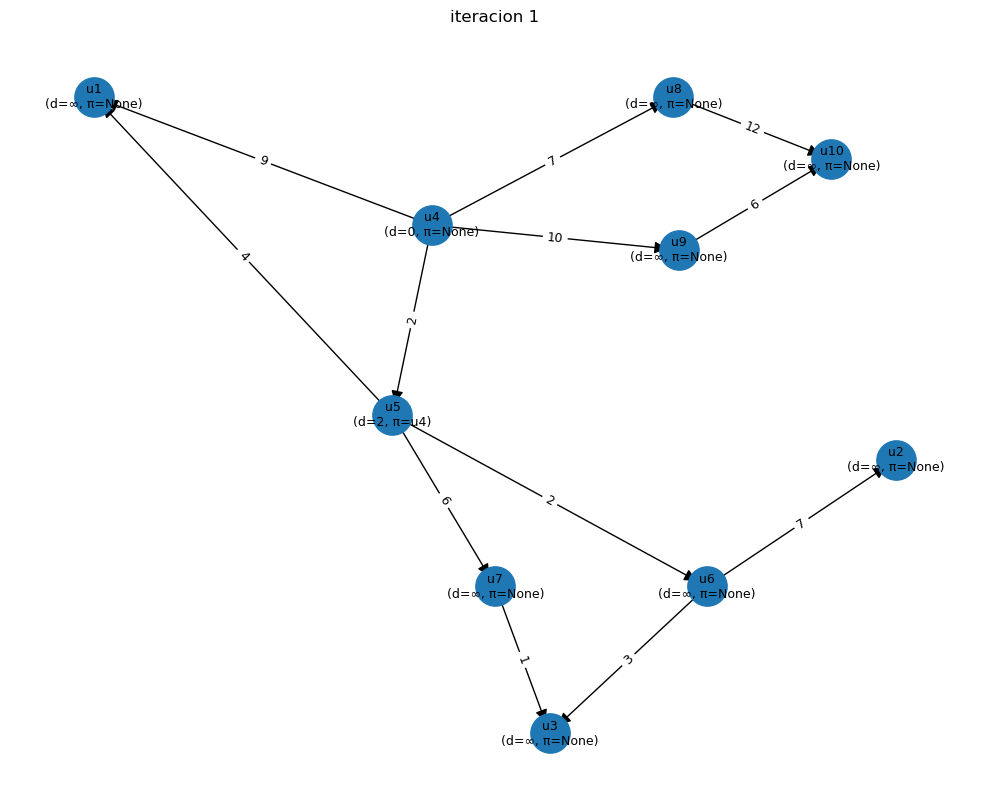

S: {'u4'}


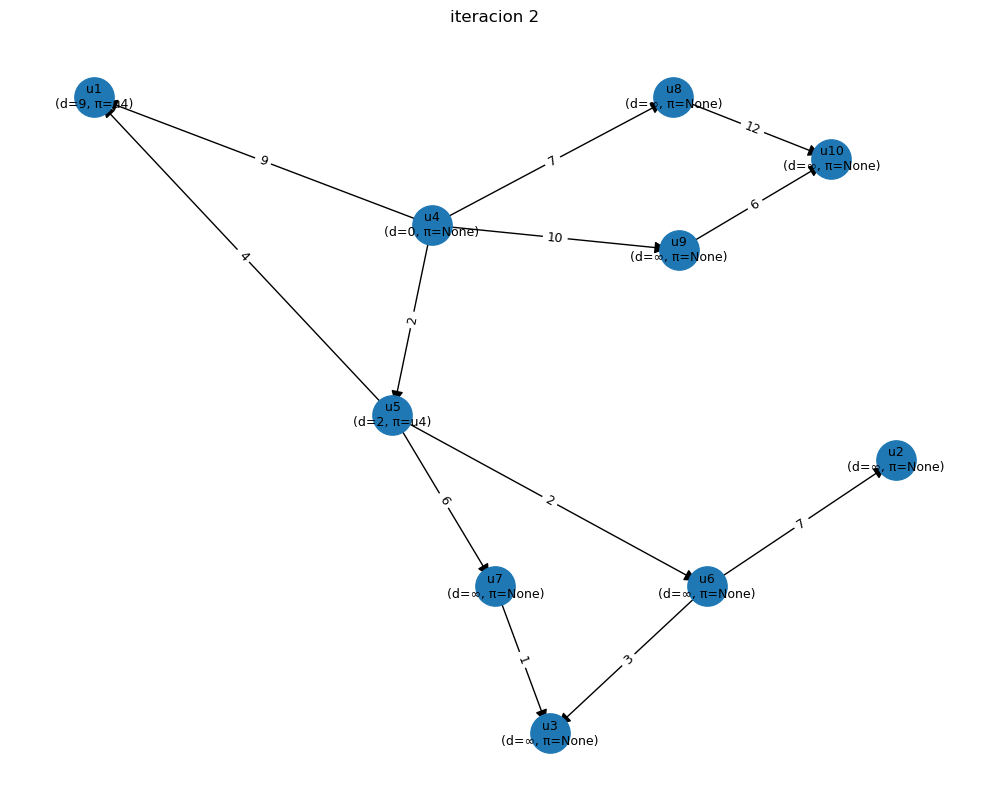

S: {'u4'}


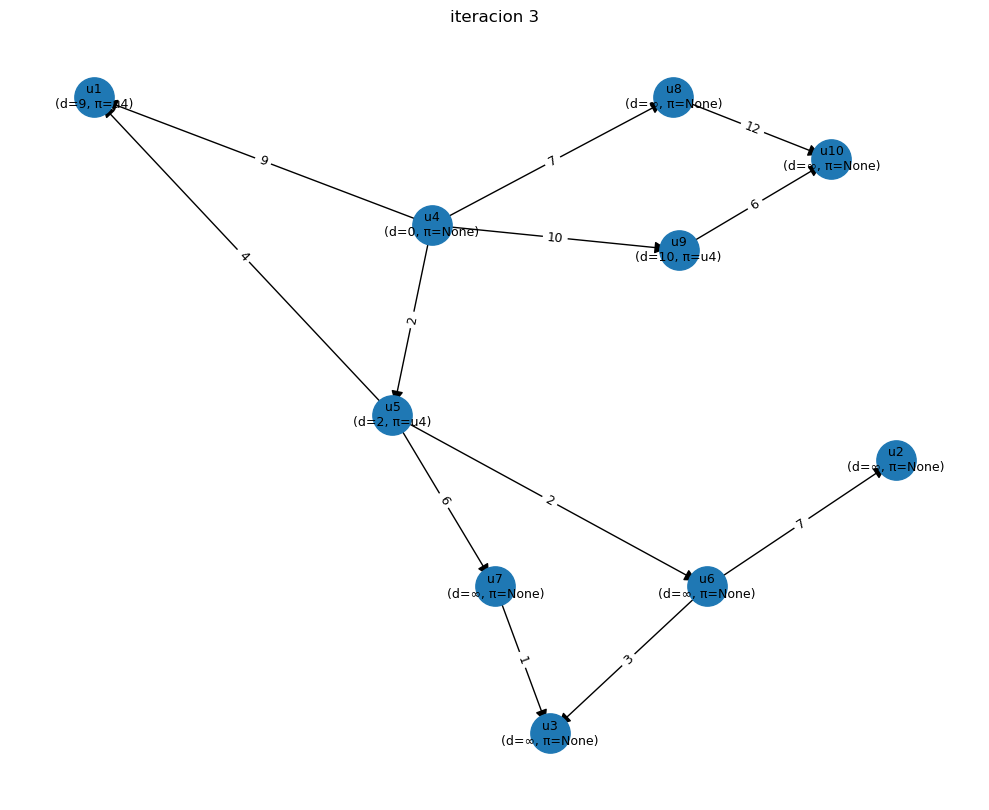

S: {'u4'}


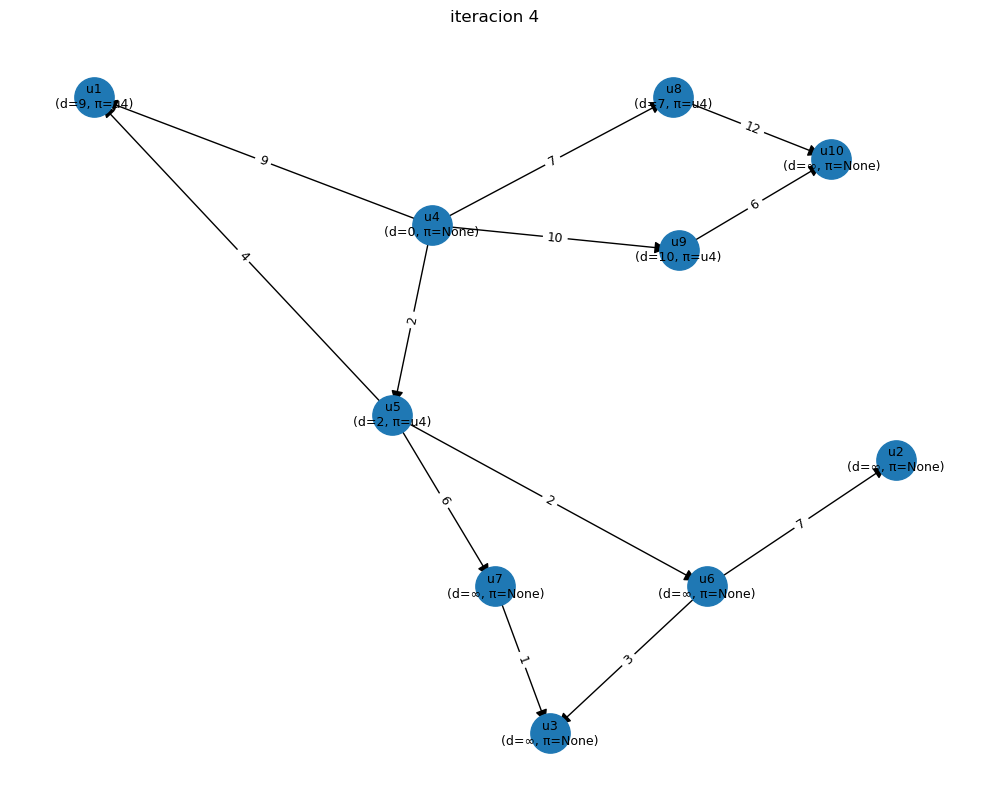

S: {'u4'}


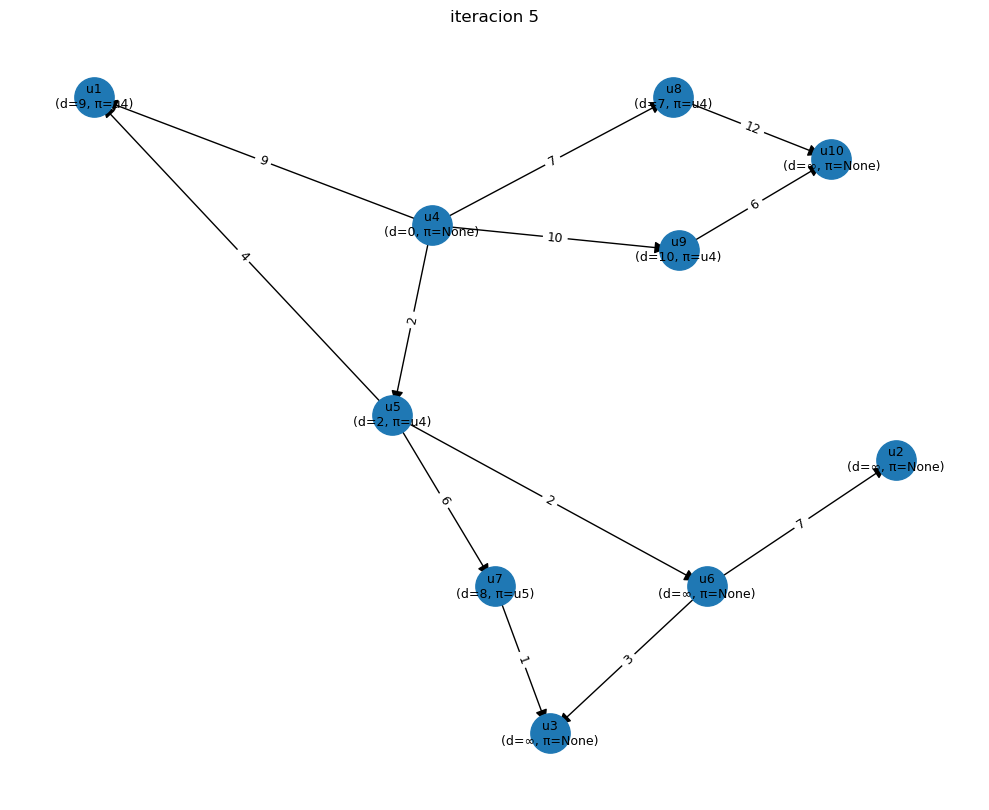

S: {'u5', 'u4'}


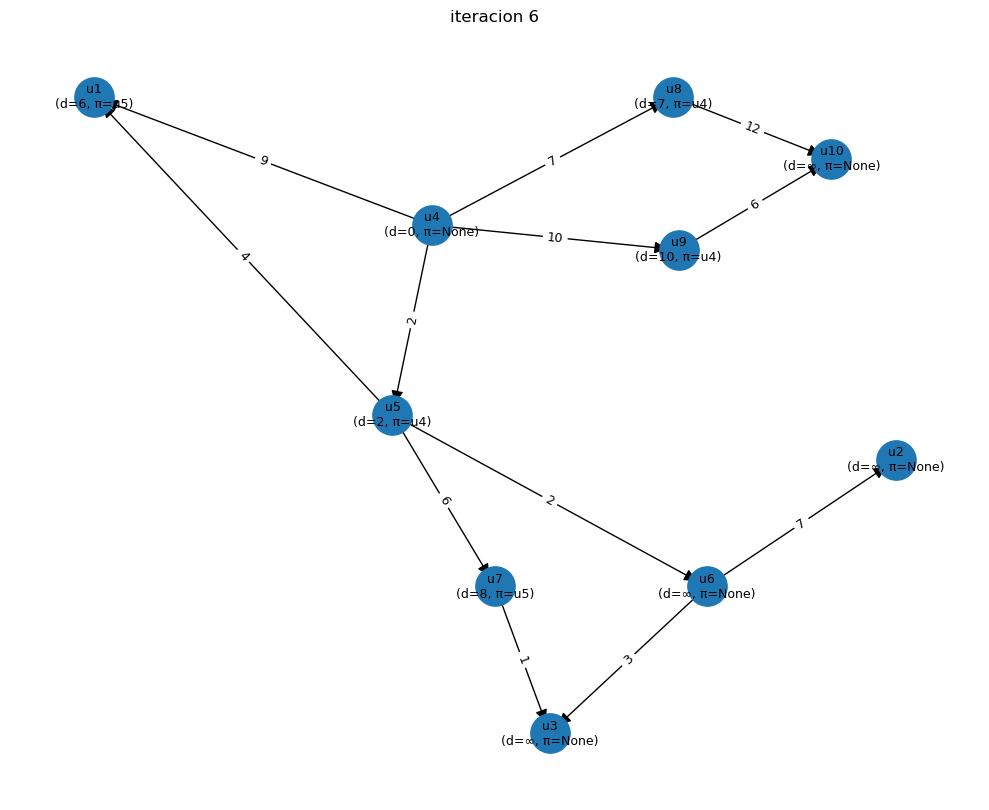

S: {'u5', 'u4'}


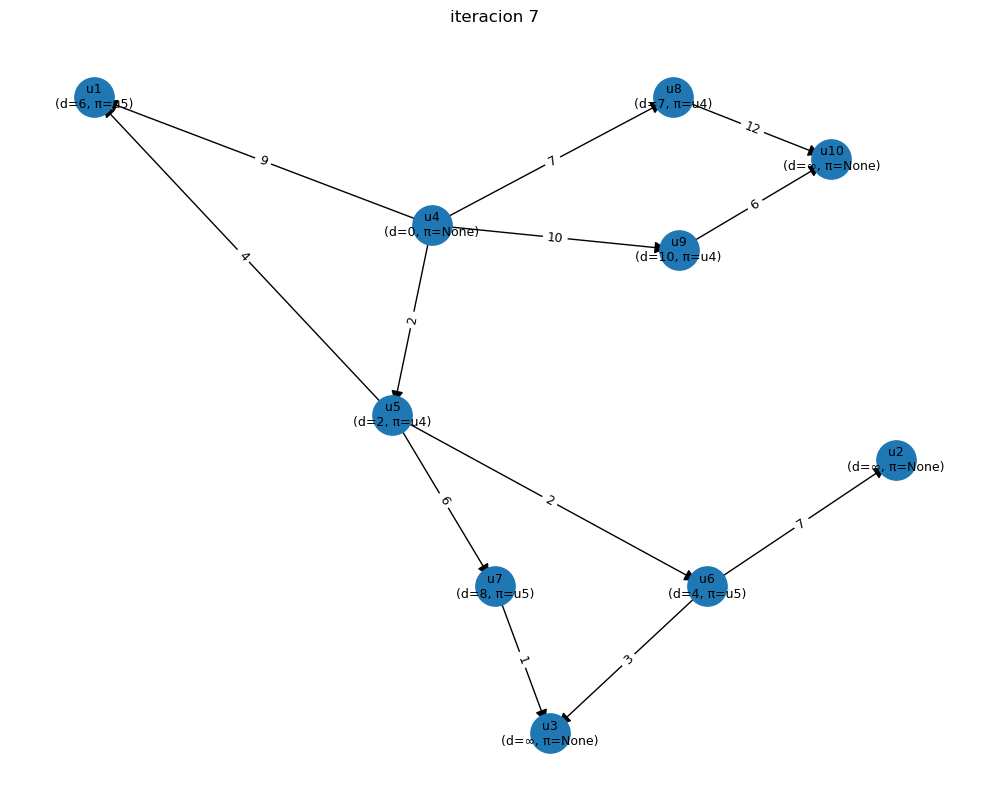

S: {'u5', 'u4'}


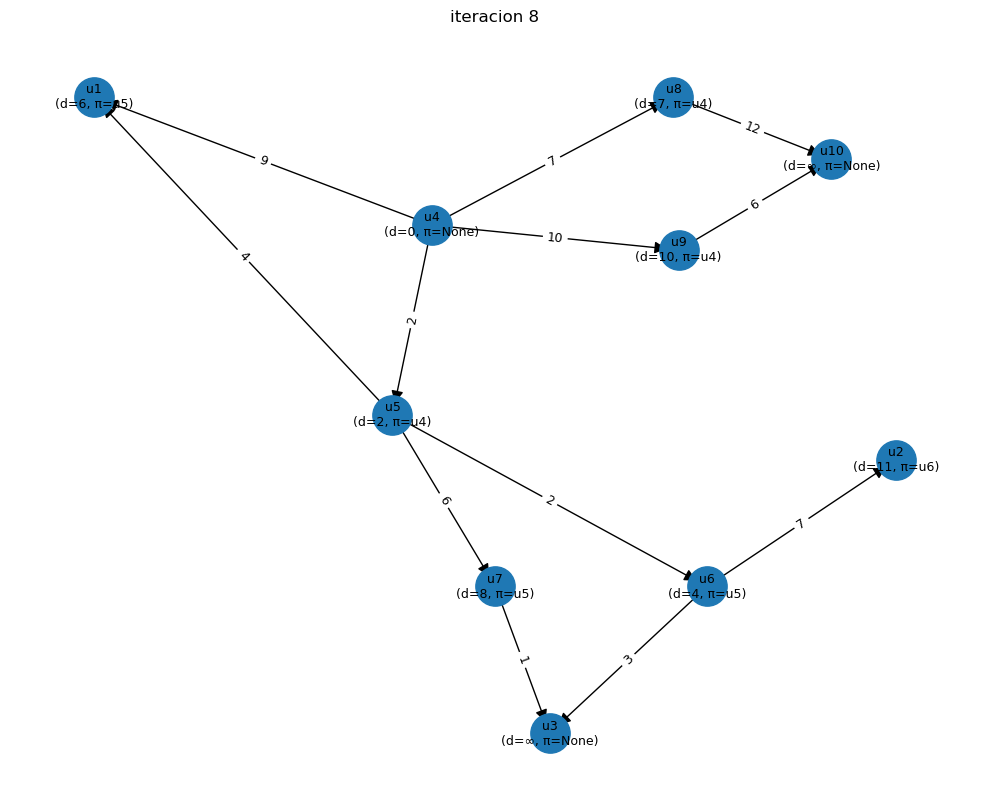

S: {'u5', 'u4', 'u6'}


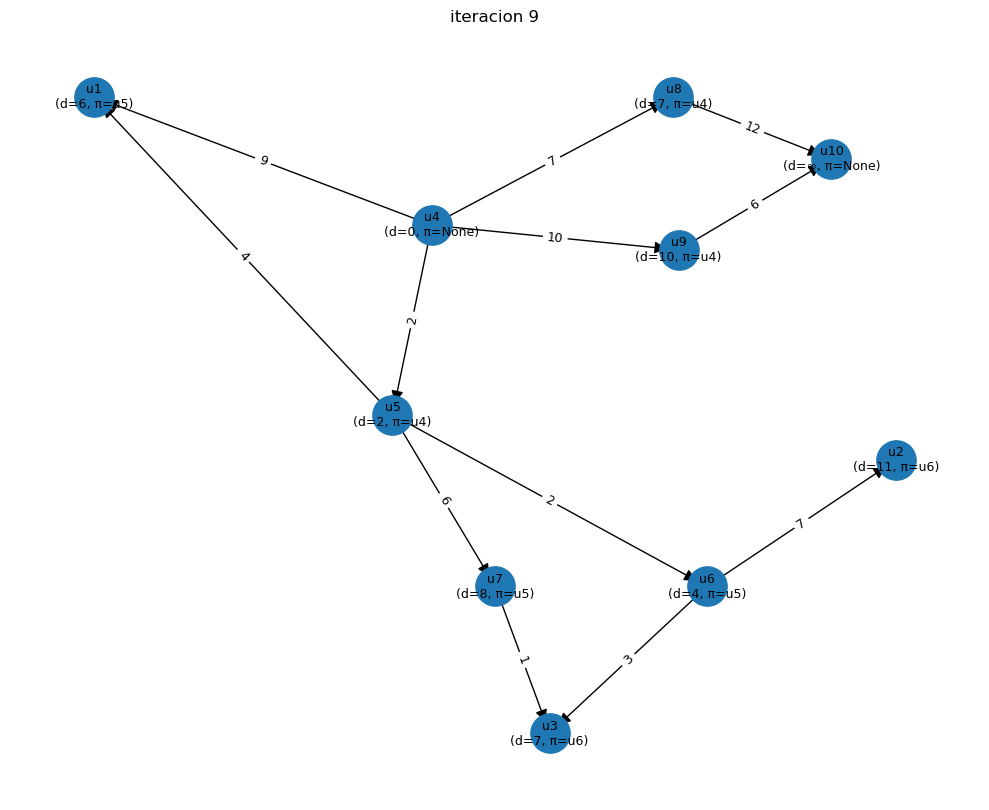

S: {'u5', 'u4', 'u6'}


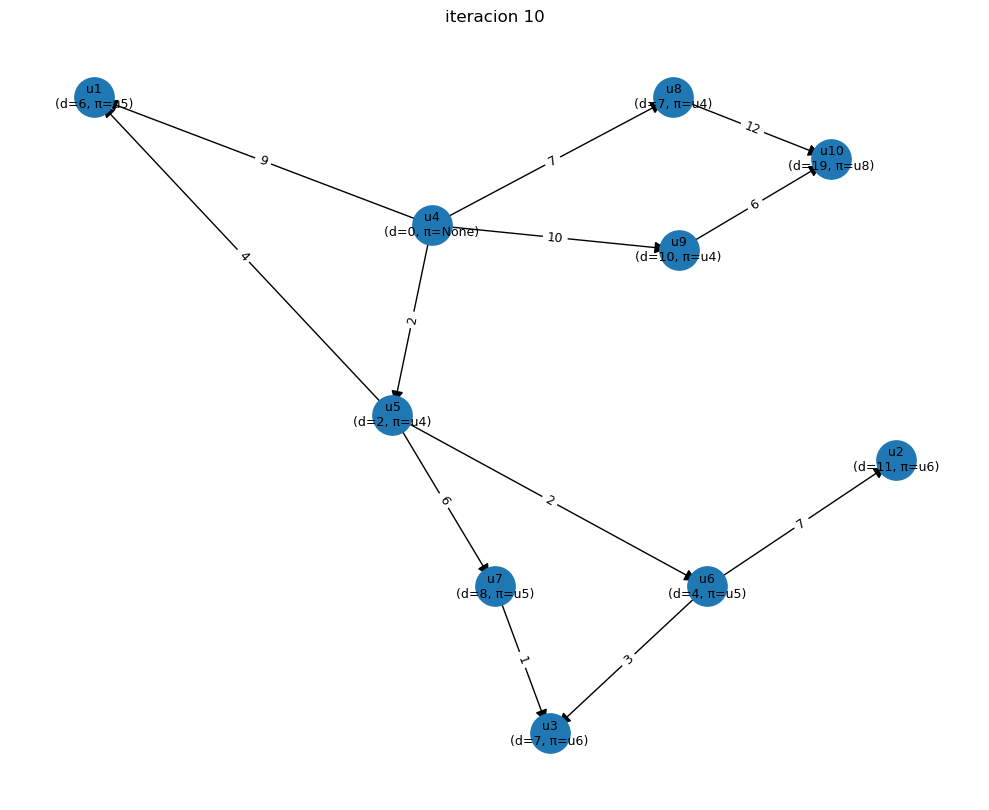

S: {'u8', 'u1', 'u3', 'u4', 'u5', 'u6'}


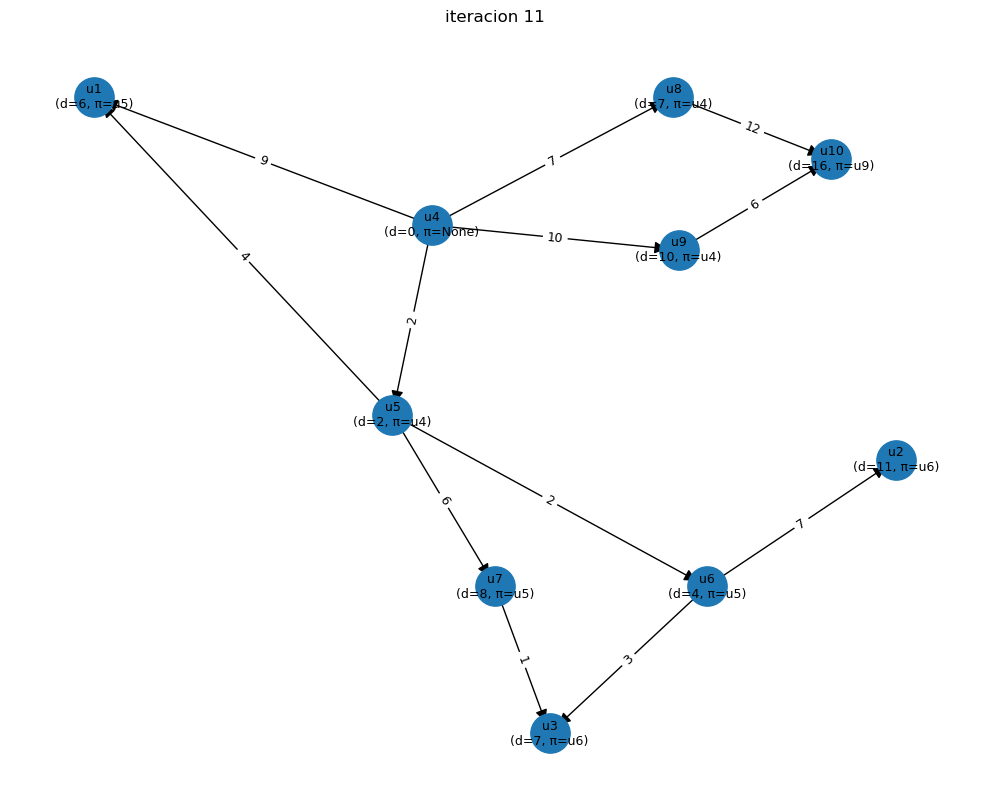

S: {'u8', 'u1', 'u3', 'u4', 'u5', 'u7', 'u6', 'u9'}
Distancias d:
u1 : 6
u2 : 11
u3 : 7
u4 : 0
u5 : 2
u6 : 4
u7 : 8
u8 : 7
u9 : 10
u10 : 16

Predecesores pi:
u1 : u5
u2 : u6
u3 : u6
u4 : None
u5 : u4
u6 : u5
u7 : u5
u8 : u4
u9 : u4
u10 : u9


In [8]:
import heapq

def initialize_single_source(G, s):
    d = {v: float("inf") for v in G["V"]}
    pi = {v: None for v in G["V"]}
    d[s] = 0
    return d, pi

def relax(u, v, w, d, pi):
    if d[v] > d[u] + w[(u, v)]:
        d[v] = d[u] + w[(u, v)]
        pi[v] = u
        return True  # hubo cambio
    return False

def dijkstra(G, w, s):
    d, pi = initialize_single_source(G, s)
    
    S = set()
    Q = []   # priority queue
    entry_finder = {}  

    draw_graph_with_labels(G, d, pi, w, "iteracion 0")
    print(f"S: {S}")
    # Insert(Q, u)
    for u in G["V"]:
        heapq.heappush(Q, (d[u], u))
        entry_finder[u] = d[u]

    ite = 1
    while Q:
        du, u = heapq.heappop(Q)

        if u in S:
            continue
        
        S.add(u)

        # for each v in G.Adj[u]
        for (x, v) in G["E"]:
            if x == u:
                changed = relax(u, v, w, d, pi)
                if changed:
                    # DECREASE-KEY: insertar de nuevo con nuevo valor
                    heapq.heappush(Q, (d[v], v))
                    entry_finder[v] = d[v]
                    draw_graph_with_labels(G, d, pi, w, f"iteracion {ite}")
                    print(f"S: {S}")
                    ite += 1

    return d, pi

G = {
    "V": ["u1","u2","u3","u4","u5","u6","u7","u8","u9","u10"],
    "E": [
        ("u6","u2"),
        ("u6","u3"),
        ("u7","u3"),
        ("u5","u7"),
        ("u5","u1"),
        ("u5","u6"),
        ("u4","u5"),
        ("u4","u1"),
        ("u4","u9"),
        ("u4","u8"),
        ("u9","u10"),
        ("u8","u10")
    ]
}

w = {
    ("u6","u2"): 7,
    ("u6","u3"): 3,
    ("u7","u3"): 1,
    ("u5","u7"): 6,
    ("u5","u1"): 4,
    ("u5","u6"): 2,
    ("u4","u5"): 2,
    ("u4","u1"): 9,
    ("u4","u9"): 10,
    ("u4","u8"): 7,
    ("u9","u10"): 6,
    ("u8","u10"): 12
}

d, pi = dijkstra(G, w, s="u4")

print("Distancias d:")
for v in G["V"]:
    print(v, ":", d[v])

print("\nPredecesores pi:")
for v in G["V"]:
    print(v, ":", pi[v])


## Bellman Ford


In [11]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_graph_with_labels(G, d, pi, w, filename=None, figsize=(10,8), seed=42):
    # Crear grafo dirigido
    g = nx.DiGraph()
    g.add_nodes_from(G["V"])
    g.add_edges_from(G["E"])

    # Layout (reproducible)
    pos = {
        "u4":  (-0.28447425,  0.43847719),
        "u1":  (-0.93452791,  0.80182164),
        "u5":  (-0.36041391, -0.09830535),
        "u8":  ( 0.18048848,  0.80182164),
        "u9":  ( 0.19048848,  0.36829081),
        "u6":  ( 0.24521190, -0.58457109),
        "u7":  (-0.16237657, -0.58457109),
        "u2":  ( 0.60852263, -0.22693411),
        "u3":  (-0.05782809, -1.00000000),
        "u10": ( 0.48467156,  0.62551130)
    }

    fig, ax = plt.subplots(figsize=figsize)

    # Dibujar nodos (sin etiquetas por ahora)
    nx.draw_networkx_nodes(g, pos, node_size=800, ax=ax)
    nx.draw_networkx_edges(g, pos, arrows=True, arrowstyle='-|>', arrowsize=18, ax=ax)

    # Preparar etiquetas de nodos: nombre en la primera línea, (d, pi) en la segunda
    def pretty_distance(val):
        if val is None:
            return "None"
        try:
            if val == float("inf"):
                return "∞"
        except Exception:
            pass
        return str(val)

    node_labels = {}
    for v in G["V"]:
        dv = d.get(v, float("inf"))
        piv = pi.get(v, None)
        label = f"{v}\n(d={pretty_distance(dv)}, π={pretty_distance(piv)})"
        node_labels[v] = label

    nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=9, ax=ax)

    # Etiquetas de arista (pesos). Si falta un peso, se muestra '?'
    edge_labels = {}
    for (u, v) in G["E"]:
        edge_labels[(u, v)] = str(w.get((u, v), "?"))

    # Ajustar desplazamiento de las etiquetas de arista para que no se sobrepongan demasiado
    nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_size=9, label_pos=0.5, ax=ax)

    ax.set_axis_off()
    plt.tight_layout()

    # if filename:
    #     plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.title(filename)
    plt.show()
    return fig, ax


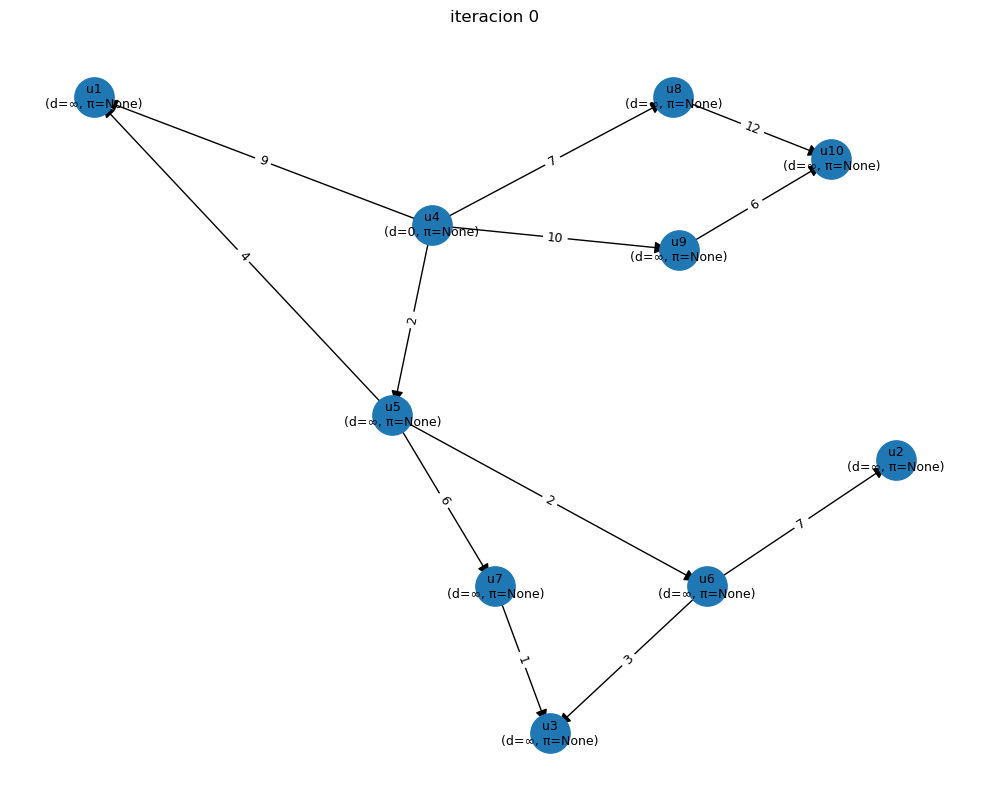

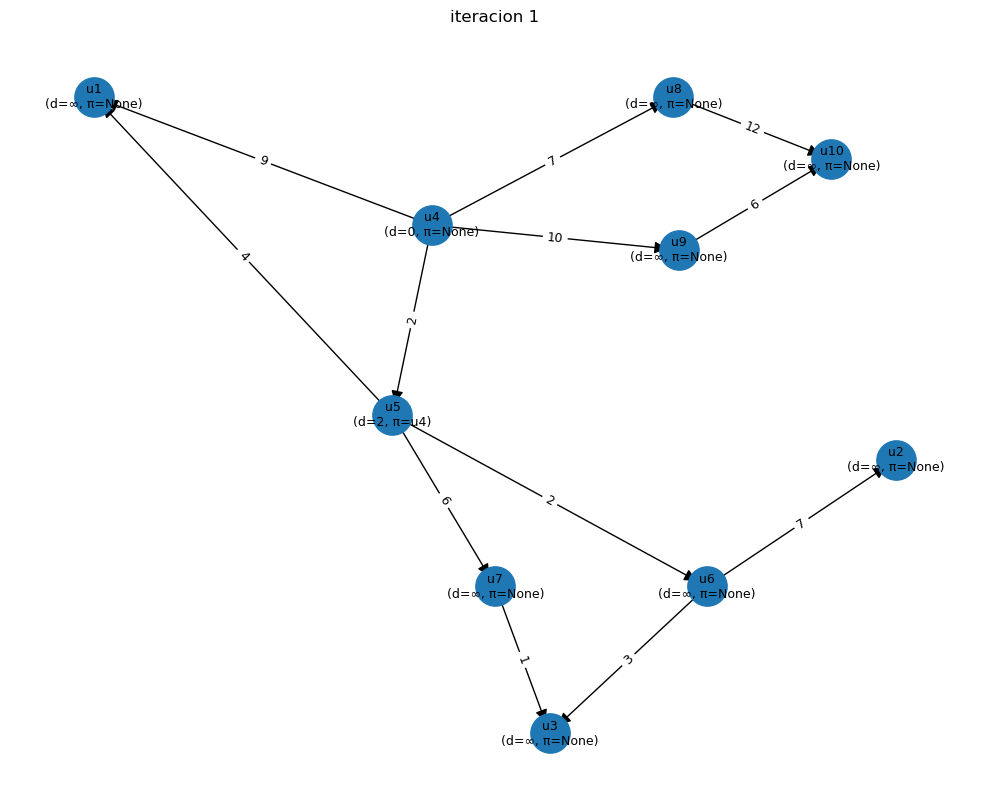

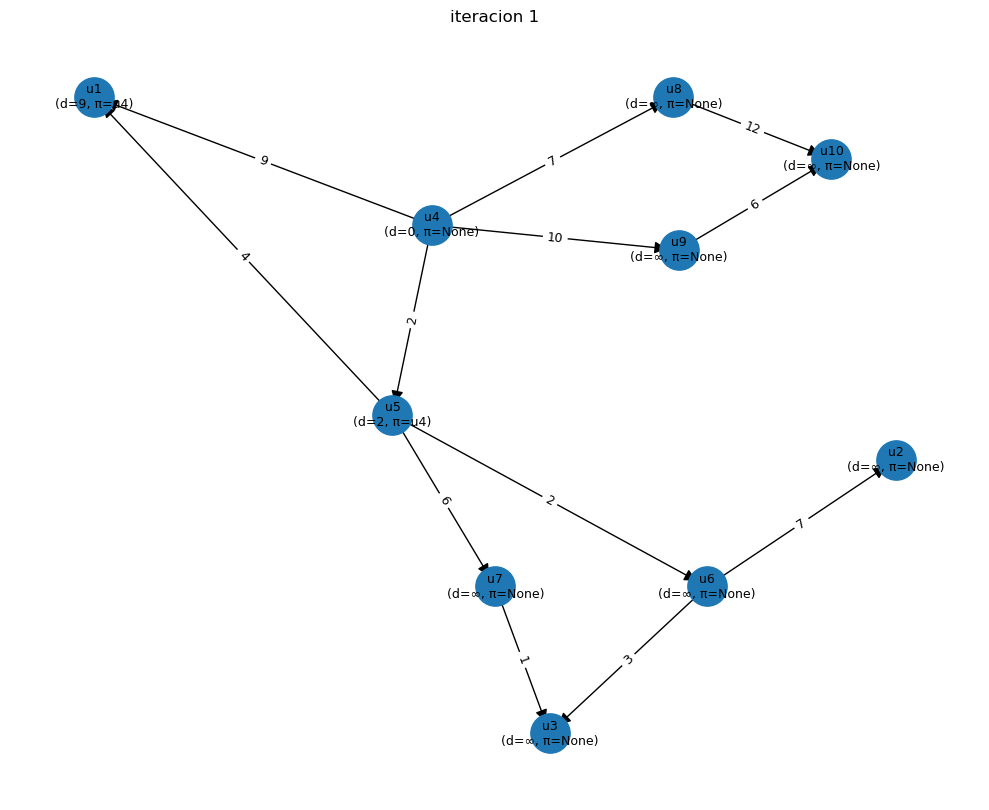

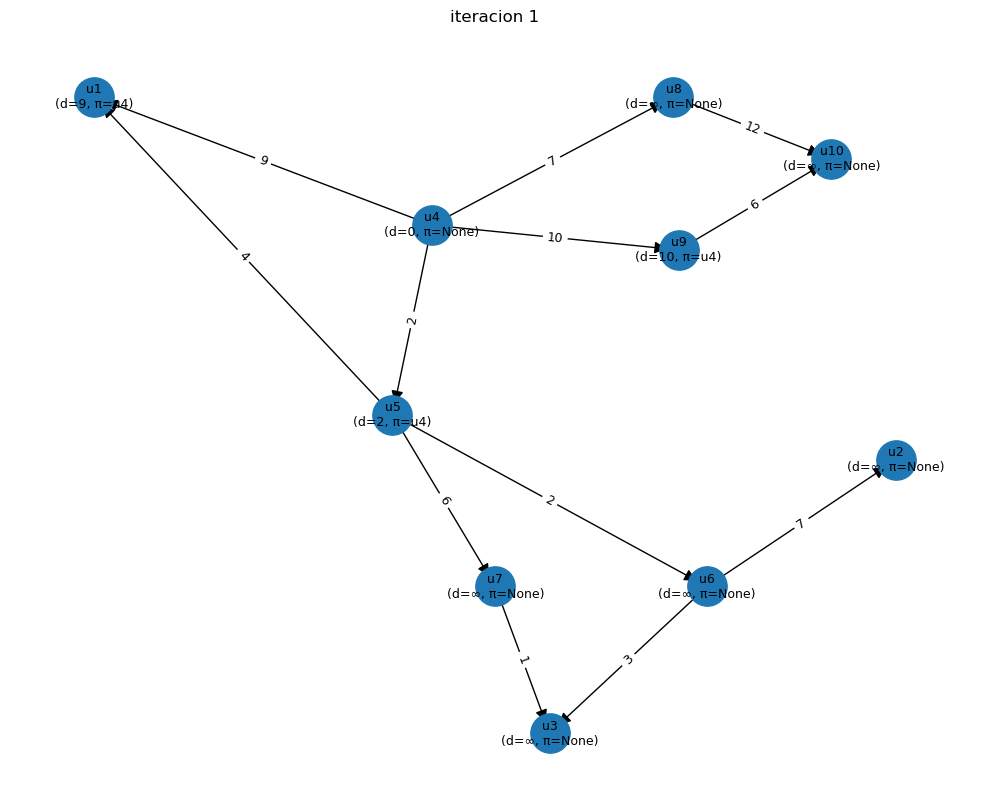

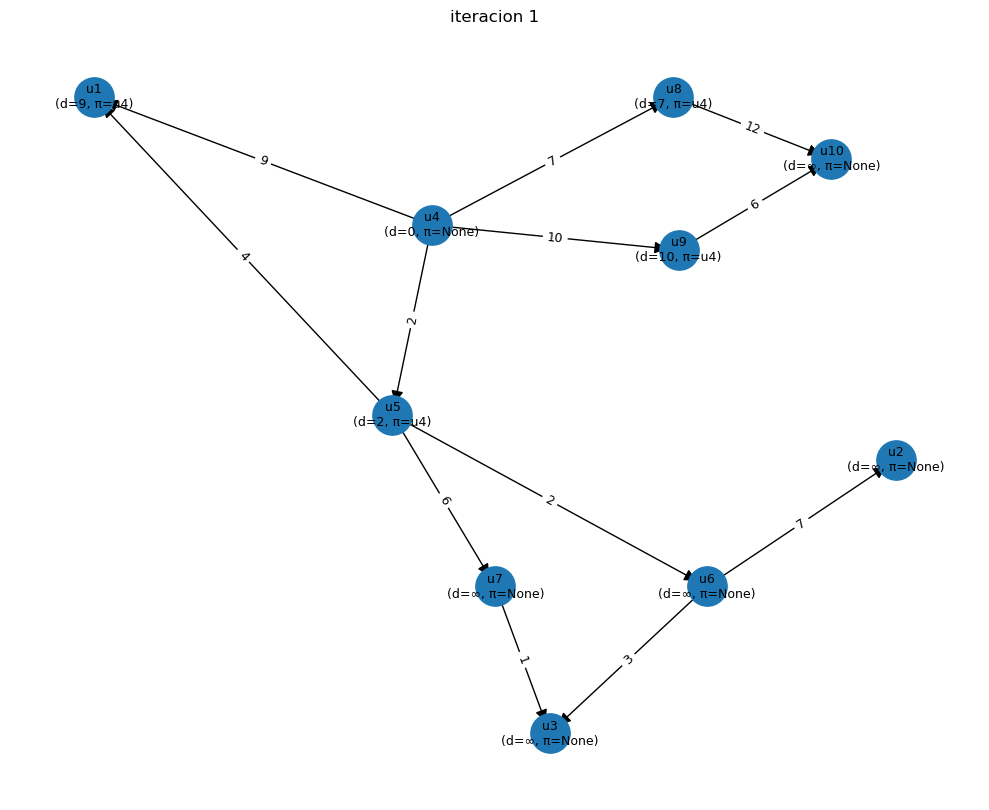

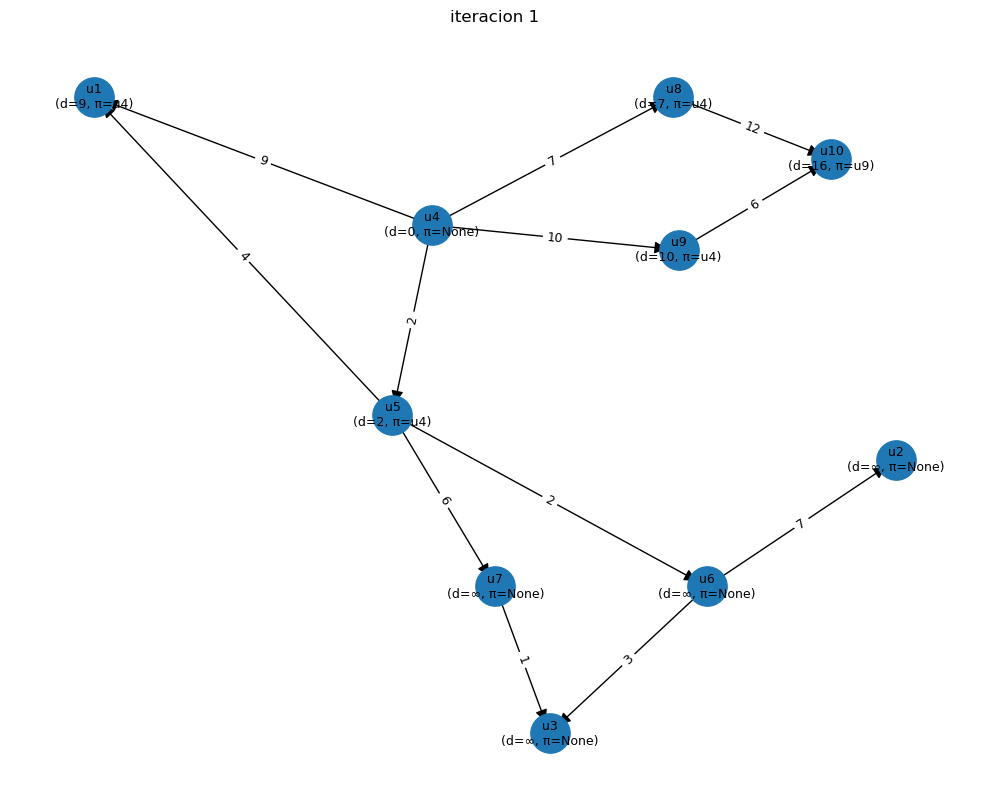

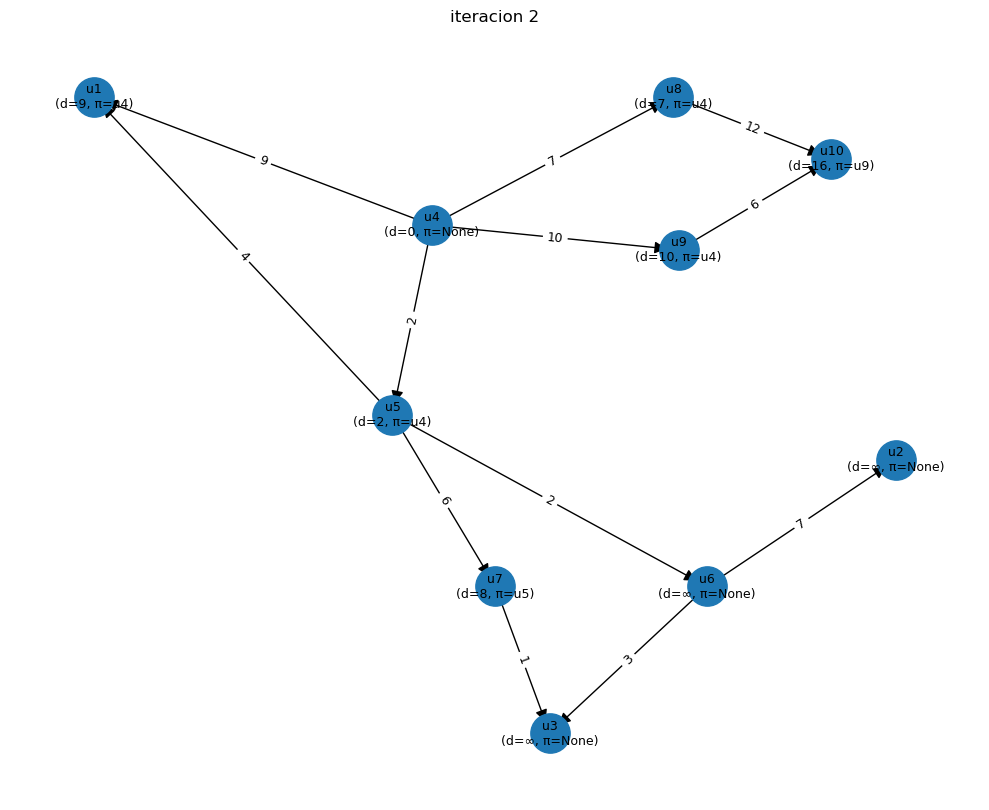

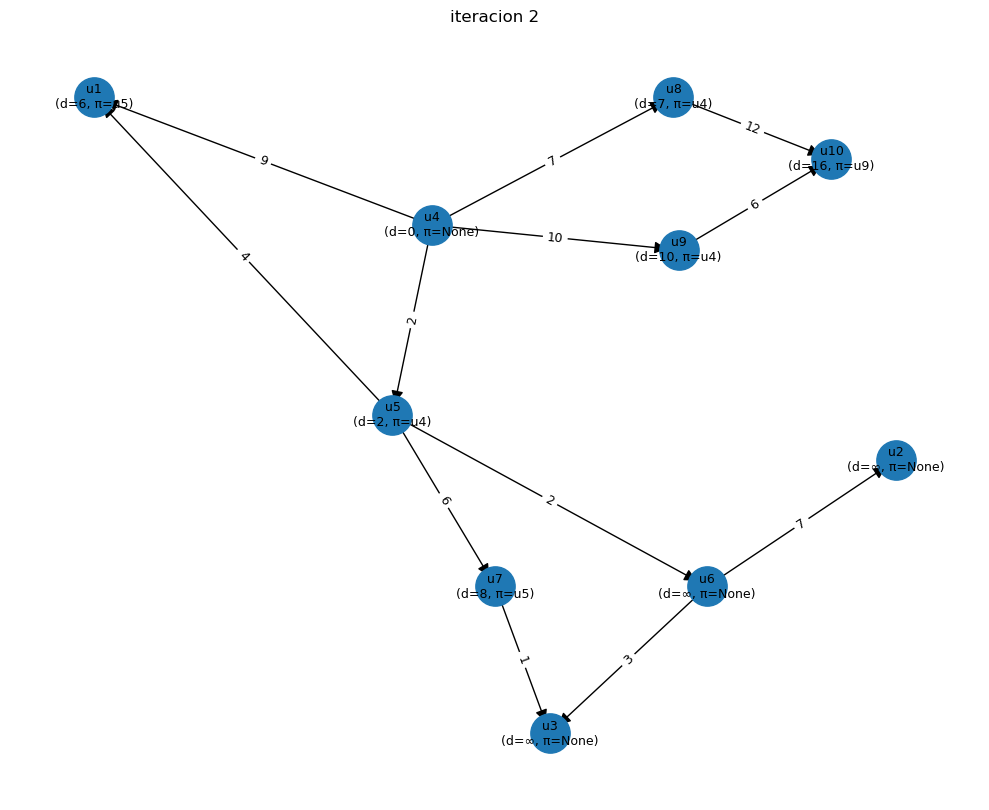

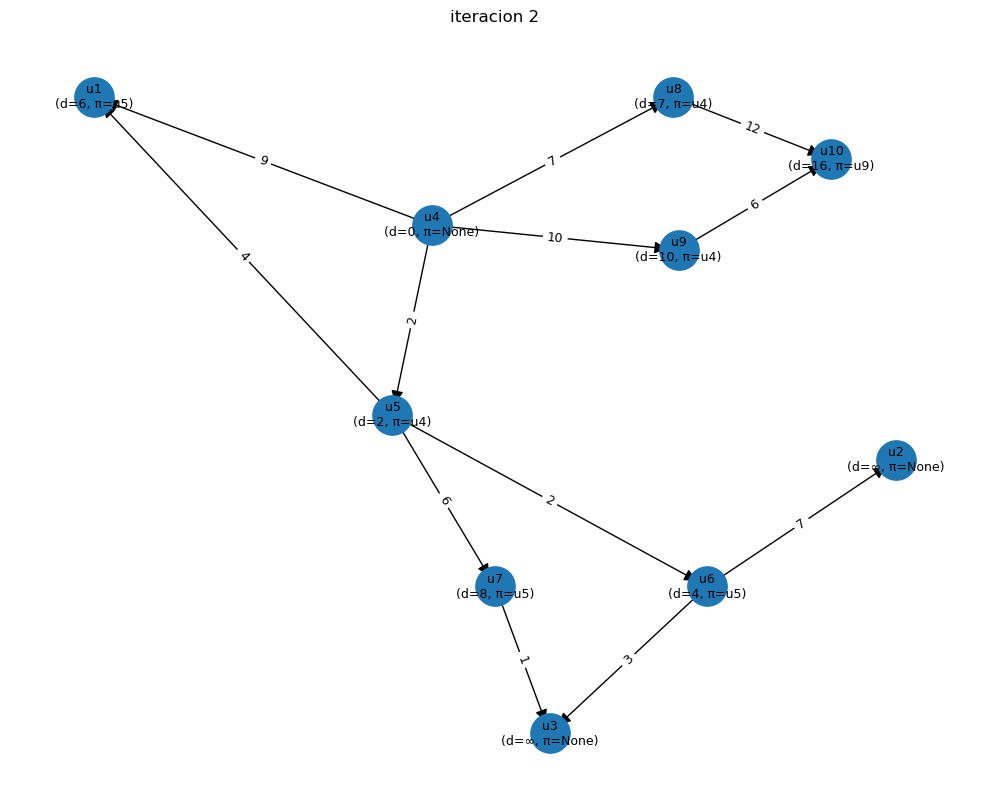

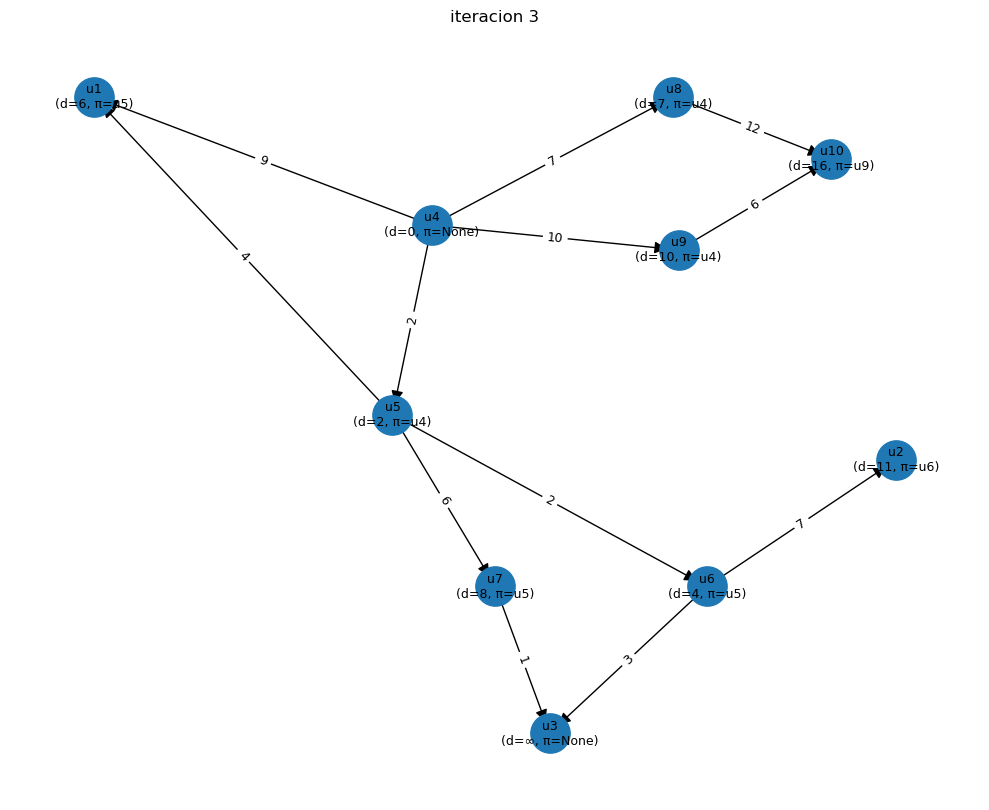

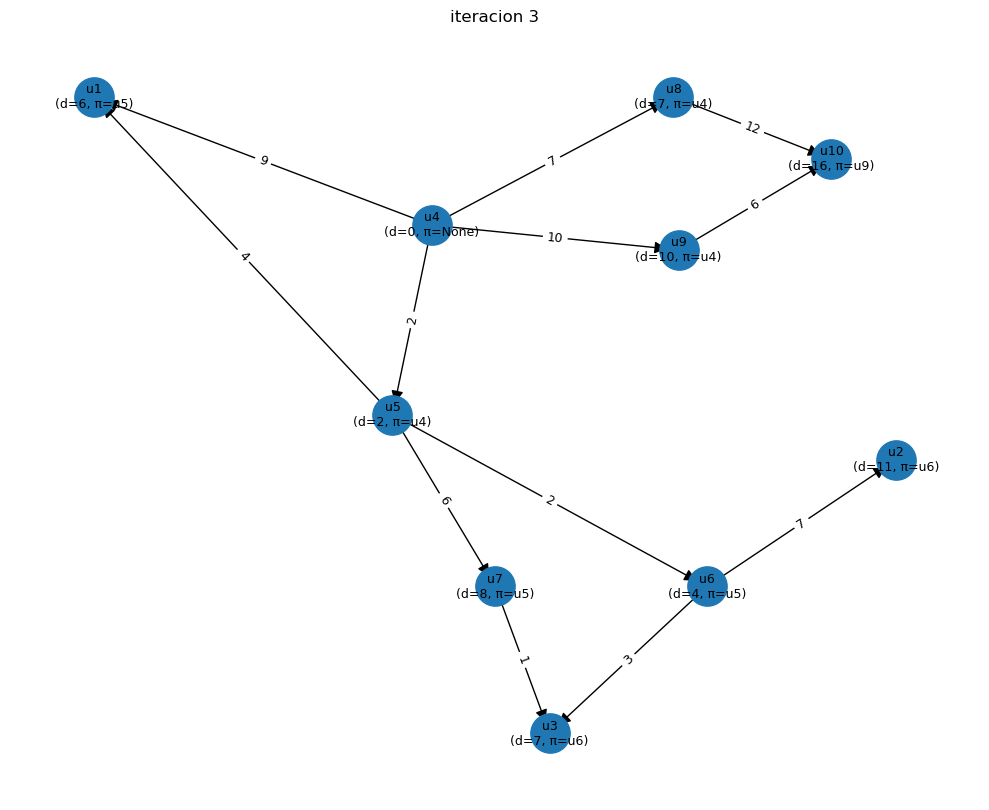

¿No hay ciclos negativos?: True
Distancias desde u4:
u1 = 6
u2 = 11
u3 = 7
u4 = 0
u5 = 2
u6 = 4
u7 = 8
u8 = 7
u9 = 10
u10 = 16
shortest path from u4 to u1: u1 u5 u4 
shortest path from u4 to u2: u2 u6 u5 u4 
shortest path from u4 to u3: u3 u6 u5 u4 
shortest path from u4 to u4: u4 
shortest path from u4 to u5: u5 u4 
shortest path from u4 to u6: u6 u5 u4 
shortest path from u4 to u7: u7 u5 u4 
shortest path from u4 to u8: u8 u4 
shortest path from u4 to u9: u9 u4 
shortest path from u4 to u10: u10 u9 u4 


In [12]:
def bellman_ford(G, w, s):
    # ---- Inicializar distancias ----
    dist = {v: float("inf") for v in G["V"]}
    dist[s] = 0
    pi ={v: None for v in G["V"]}
    draw_graph_with_labels(G, dist, pi, w, "iteracion 0")
    # ---- |V| - 1 iteraciones ----
    ite = 1
    for _ in range(len(G["V"]) - 1):
        for (u, v) in G["E"]:
            if dist[u] + w[(u, v)] < dist[v]:
                dist[v] = dist[u] + w[(u, v)]
                pi[v] = u
                draw_graph_with_labels(G, dist, pi, w, f"iteracion {ite}")
        ite += 1    

    # ---- Detección de ciclos negativos ----
    for (u, v) in G["E"]:
        if dist[u] + w[(u, v)] < dist[v]:
            return False, dist  # ciclo negativo detectado
            

    return True, dist, pi

G = {
    "V": ["u1","u2","u3","u4","u5","u6","u7","u8","u9","u10"],
    "E": [
        ("u6","u2"),
        ("u6","u3"),
        ("u7","u3"),
        ("u5","u7"),
        ("u5","u1"),
        ("u5","u6"),
        ("u4","u5"),
        ("u4","u1"),
        ("u4","u9"),
        ("u4","u8"),
        ("u9","u10"),
        ("u8","u10")
    ]
}

w = {
    ("u6","u2"): 7,
    ("u6","u3"): 3,
    ("u7","u3"): 1,
    ("u5","u7"): 6,
    ("u5","u1"): 4,
    ("u5","u6"): 2,
    ("u4","u5"): 2,
    ("u4","u1"): 9,
    ("u4","u9"): 10,
    ("u4","u8"): 7,
    ("u9","u10"): 6,
    ("u8","u10"): 12
}


ok, dist, pi = bellman_ford(G, w, "u4")

print("¿No hay ciclos negativos?:", ok)
print("Distancias desde u4:")
for nodo in dist:
    print(nodo, "=", dist[nodo])
for v in G["V"]:
    child = v
    print(f"shortest path from u4 to {child}: {child}", end = " ")
    while pi[child] is not None:
        print(pi[child], end = " ")
        child = pi[child]
    print()


## Johnson

In [44]:
import heapq

# ==========================================================
#   BELLMAN–FORD (permite pesos negativos)
# ==========================================================
def bellman_ford(G, w, s):
    V = G["V"]
    E = G["E"]
    
    # distancia inicial
    dist = {v: float("inf") for v in V}
    dist[s] = 0

    # relajación |V|-1 veces
    for _ in range(len(V)-1):
        updated = False
        for (u,v) in E:
            if dist[u] + w[(u,v)] < dist[v]:
                dist[v] = dist[u] + w[(u,v)]
                updated = True
        if not updated:
            break

    # detección de ciclo negativo
    for (u,v) in E:
        if dist[u] + w[(u,v)] < dist[v]:
            return None   # ciclo negativo

    return dist


# ==========================================================
#   DIJKSTRA (sin pesos negativos)
# ==========================================================
def dijkstra(G, w, s):
    V = G["V"]
    adj = {u: [] for u in V}
    for (u,v) in G["E"]:
        adj[u].append(v)

    dist = {v: float("inf") for v in V}
    dist[s] = 0

    pq = [(0, s)]

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue

        for v in adj[u]:
            cost = w[(u,v)]
            if dist[u] + cost < dist[v]:
                dist[v] = dist[u] + cost
                heapq.heappush(pq, (dist[v], v))

    return dist


# ==========================================================
#   JOHNSON(G, w) — basado EXACTAMENTE en tu pseudocódigo
# ==========================================================
def johnson(G, w):
    # 1. Construcción de G′
    Gp = {
        "V": G["V"] + ["s"],       # vértice adicional
        "E": G["E"].copy()
    }

    wp = w.copy()

    # aristas (s,v) con peso 0
    for v in G["V"]:
        Gp["E"].append(("s", v))
        wp[("s", v)] = 0

    # 2. Bellman-Ford desde s
    h = bellman_ford(Gp, wp, "s")

    if h is None:
        print("El grafo contiene un ciclo negativo")
        return None

    # 6–7. Reponderación
    w_hat = {}
    for (u,v) in G["E"]:
        w_hat[(u,v)] = w[(u,v)] + h[u] - h[v]

    # 8. Matriz resultado
    V = G["V"]
    D = {u: {v: None for v in V} for u in V}

    # 9. Dijkstra desde cada u
    for u in V:
        dist_hat = dijkstra(G, w_hat, u)

        # 11–12. Recuperar distancias verdaderas
        for v in V:
            if dist_hat[v] < float("inf"):
                D[u][v] = dist_hat[v] + h[v] - h[u]
            else:
                D[u][v] = float("inf")

    return D


# ==========================================================
#   EJEMPLO EXACTO QUE PEDISTE
# ==========================================================
G = {
    "V": ["u1","u2","u3","u4","u5","u6","u7","u8","u9","u10"],
    "E": [
        ("u6","u2"),
        ("u6","u3"),
        ("u7","u3"),
        ("u5","u7"),
        ("u5","u1"),
        ("u5","u6"),
        ("u4","u5"),
        ("u4","u1"),
        ("u4","u9"),
        ("u4","u8"),
        ("u9","u10"),
        ("u8","u10")
    ]
}

w = {
    ("u6","u2"): 7,
    ("u6","u3"): 3,
    ("u7","u3"): 1,
    ("u5","u7"): 6,
    ("u5","u1"): 4,
    ("u5","u6"): 2,
    ("u4","u5"): 2,
    ("u4","u1"): 9,
    ("u4","u9"): 10,
    ("u4","u8"): 7,
    ("u9","u10"): 6,
    ("u8","u10"): 12
}


# ==========================================================
#   EJECUCIÓN
# ==========================================================
D = johnson(G, w)

print("\nMatriz de distancias obtenida con Johnson:\n")
for u in G["V"]:
    print(u, D[u])



Matriz de distancias obtenida con Johnson:

u1 {'u1': 0, 'u2': inf, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u2 {'u1': inf, 'u2': 0, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u3 {'u1': inf, 'u2': inf, 'u3': 0, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u4 {'u1': 6, 'u2': 11, 'u3': 7, 'u4': 0, 'u5': 2, 'u6': 4, 'u7': 8, 'u8': 7, 'u9': 10, 'u10': 16}
u5 {'u1': 4, 'u2': 9, 'u3': 5, 'u4': inf, 'u5': 0, 'u6': 2, 'u7': 6, 'u8': inf, 'u9': inf, 'u10': inf}
u6 {'u1': inf, 'u2': 7, 'u3': 3, 'u4': inf, 'u5': inf, 'u6': 0, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u7 {'u1': inf, 'u2': inf, 'u3': 1, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': 0, 'u8': inf, 'u9': inf, 'u10': inf}
u8 {'u1': inf, 'u2': inf, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': 0, 'u9': inf, 'u10': 12}
u9 {'u1': inf, 'u2': inf, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u

In [45]:
import heapq

# ==========================================================
#   BELLMAN–FORD (permite pesos negativos)
# ==========================================================
def bellman_ford(G, w, s):
    V = G["V"]
    E = G["E"]
    
    dist = {v: float("inf") for v in V}
    dist[s] = 0

    for _ in range(len(V)-1):
        changed = False
        for (u, v) in E:
            if dist[u] + w[(u, v)] < dist[v]:
                dist[v] = dist[u] + w[(u, v)]
                changed = True
        if not changed:
            break

    for (u, v) in E:
        if dist[u] + w[(u, v)] < dist[v]:
            return None

    return dist


# ==========================================================
#   DIJKSTRA (devuelve distancias y predecesores)
# ==========================================================
def dijkstra(G, w, s):
    V = G["V"]

    # construir lista de adyacencia
    adj = {u: [] for u in V}
    for (u,v) in G["E"]:
        adj[u].append(v)

    dist = {v: float("inf") for v in V}
    pred = {v: None for v in V}     # predecesores

    dist[s] = 0
    pq = [(0, s)]

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue

        for v in adj[u]:
            cost = w[(u,v)]
            if dist[u] + cost < dist[v]:
                dist[v] = dist[u] + cost
                pred[v] = u
                heapq.heappush(pq, (dist[v], v))

    return dist, pred


# ==========================================================
#   JOHNSON(G, w) — versión con matriz de predecesores
# ==========================================================
def johnson(G, w):
    # 1. Construir G'
    Gp = {
        "V": G["V"] + ["s"],
        "E": G["E"].copy()
    }
    wp = w.copy()

    # añadir aristas (s,v) con peso 0
    for v in G["V"]:
        Gp["E"].append(("s", v))
        wp[("s", v)] = 0

    # 2. Bellman–Ford desde s
    h = bellman_ford(Gp, wp, "s")
    if h is None:
        print("El grafo contiene un ciclo negativo.")
        return None, None

    # 6. Reponderación
    w_hat = {}
    for (u,v) in G["E"]:
        w_hat[(u, v)] = w[(u,v)] + h[u] - h[v]

    V = G["V"]

    # matrices de resultado
    D  = {u: {v: float("inf") for v in V} for u in V}
    PI = {u: {v: None          for v in V} for u in V}

    # 9. Dijkstra desde cada nodo
    for u in V:
        dist_hat, pred_hat = dijkstra(G, w_hat, u)

        for v in V:
            # reconstruir distancia real
            D[u][v] = dist_hat[v] + h[v] - h[u] if dist_hat[v] < float("inf") else float("inf")
            PI[u][v] = pred_hat[v]

    return D, PI


# ==========================================================
#   GRAFO DE EJEMPLO EXACTO QUE PEDISTE
# ==========================================================
G = {
    "V": ["u1","u2","u3","u4","u5","u6","u7","u8","u9","u10"],
    "E": [
        ("u6","u2"),
        ("u6","u3"),
        ("u7","u3"),
        ("u5","u7"),
        ("u5","u1"),
        ("u5","u6"),
        ("u4","u5"),
        ("u4","u1"),
        ("u4","u9"),
        ("u4","u8"),
        ("u9","u10"),
        ("u8","u10")
    ]
}

w = {
    ("u6","u2"): 7,
    ("u6","u3"): 3,
    ("u7","u3"): 1,
    ("u5","u7"): 6,
    ("u5","u1"): 4,
    ("u5","u6"): 2,
    ("u4","u5"): 2,
    ("u4","u1"): 9,
    ("u4","u9"): 10,
    ("u4","u8"): 7,
    ("u9","u10"): 6,
    ("u8","u10"): 12
}

# ==========================================================
#   EJECUCIÓN
# ==========================================================
D, PI = johnson(G, w)

print("\nMatriz de distancias D:")
for u in G["V"]:
    print(u, D[u])

print("\nMatriz de predecesores PI:")
for u in G["V"]:
    print(u, PI[u])



Matriz de distancias D:
u1 {'u1': 0, 'u2': inf, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u2 {'u1': inf, 'u2': 0, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u3 {'u1': inf, 'u2': inf, 'u3': 0, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u4 {'u1': 6, 'u2': 11, 'u3': 7, 'u4': 0, 'u5': 2, 'u6': 4, 'u7': 8, 'u8': 7, 'u9': 10, 'u10': 16}
u5 {'u1': 4, 'u2': 9, 'u3': 5, 'u4': inf, 'u5': 0, 'u6': 2, 'u7': 6, 'u8': inf, 'u9': inf, 'u10': inf}
u6 {'u1': inf, 'u2': 7, 'u3': 3, 'u4': inf, 'u5': inf, 'u6': 0, 'u7': inf, 'u8': inf, 'u9': inf, 'u10': inf}
u7 {'u1': inf, 'u2': inf, 'u3': 1, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': 0, 'u8': inf, 'u9': inf, 'u10': inf}
u8 {'u1': inf, 'u2': inf, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': 0, 'u9': inf, 'u10': 12}
u9 {'u1': inf, 'u2': inf, 'u3': inf, 'u4': inf, 'u5': inf, 'u6': inf, 'u7': inf, 'u8': inf, 'u9': 0, 'u

## Floyd Warshall

In [13]:
import matplotlib.pyplot as plt

def mostrar_tablas_floyd_warshall(D, pi, V, titulo):
    """
    Muestra las matrices D y π en tablas usando matplotlib.
    
    D  -> matriz de distancias mínimas
    pi -> matriz de predecesores
    V  -> lista de vértices en orden
    """
    n = len(V)

    # Convertimos π a string para imprimir None correctamente
    pi_str = [[str(pi[i][j]) for j in range(n)] for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))


    # -------------------------
    #       Tabla D
    # -------------------------
    axes[0].axis("off")
    table_D = axes[0].table(
        cellText=D,
        rowLabels=V,
        colLabels=V,
        loc="center"
    )
    table_D.auto_set_font_size(False)
    table_D.set_fontsize(10)
    table_D.scale(1.2, 1.2)
    axes[0].set_title("Matriz D (distancias mínimas)", fontsize=12)

    # -------------------------
    #       Tabla π
    # -------------------------
    axes[1].axis("off")
    table_pi = axes[1].table(
        cellText=pi_str,
        rowLabels=V,
        colLabels=V,
        loc="center"
    )
    table_pi.auto_set_font_size(False)
    table_pi.set_fontsize(10)
    table_pi.scale(1.2, 1.2)
    axes[1].set_title("Matriz π (predecesores)", fontsize=12)

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


In [14]:
import math

def floyd_warshall_with_pi(W, V):
    n = len(W)

    # D^(0) ← W
    D = [row[:] for row in W]

    # Inicializar π
    pi = [[None]*n for _ in range(n)]
    
    mostrar_tablas_floyd_warshall(D, pi, V, "Iteracion 0")
    ite = 1 
    for i in range(n):
        for j in range(n):
            if i == j:
                pi[i][j] = None
            elif W[i][j] != math.inf:
                pi[i][j] = f"u{i+1}"      # predecesor inmediato
            else:
                pi[i][j] = None
    mostrar_tablas_floyd_warshall(D, pi, V, "Iteracion 0.5")


    # Algoritmo Floyd–Warshall
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if D[i][k] + D[k][j] < D[i][j]:
                    D[i][j] = D[i][k] + D[k][j]
                    pi[i][j] = pi[k][j]   # heredamos el predecesor por k
                    mostrar_tablas_floyd_warshall(D, pi, V, f"Iteracion {ite}")
                    ite += 1


    return D, pi


In [15]:
V = ["u1","u2","u3","u4","u5","u6","u7","u8","u9","u10"]
index = {v:i for i,v in enumerate(V)}

w = {
    ("u6","u2"): 7,
    ("u6","u3"): 3,
    ("u7","u3"): 1,
    ("u5","u7"): 6,
    ("u5","u1"): 4,
    ("u5","u6"): 2,
    ("u4","u5"): 2,
    ("u4","u1"): 9,
    ("u4","u9"): 10,
    ("u4","u8"): 7,
    ("u9","u10"): 6,
    ("u8","u10"): 12,
}

n = len(V)
INF = math.inf

# Iniciamos la matriz
W = [[INF]*n for _ in range(n)]

# Diagonal en 0
for i in range(n):
    W[i][i] = 0

# Insertar aristas
for (u,v),weight in w.items():
    i = index[u]
    j = index[v]
    W[i][j] = weight


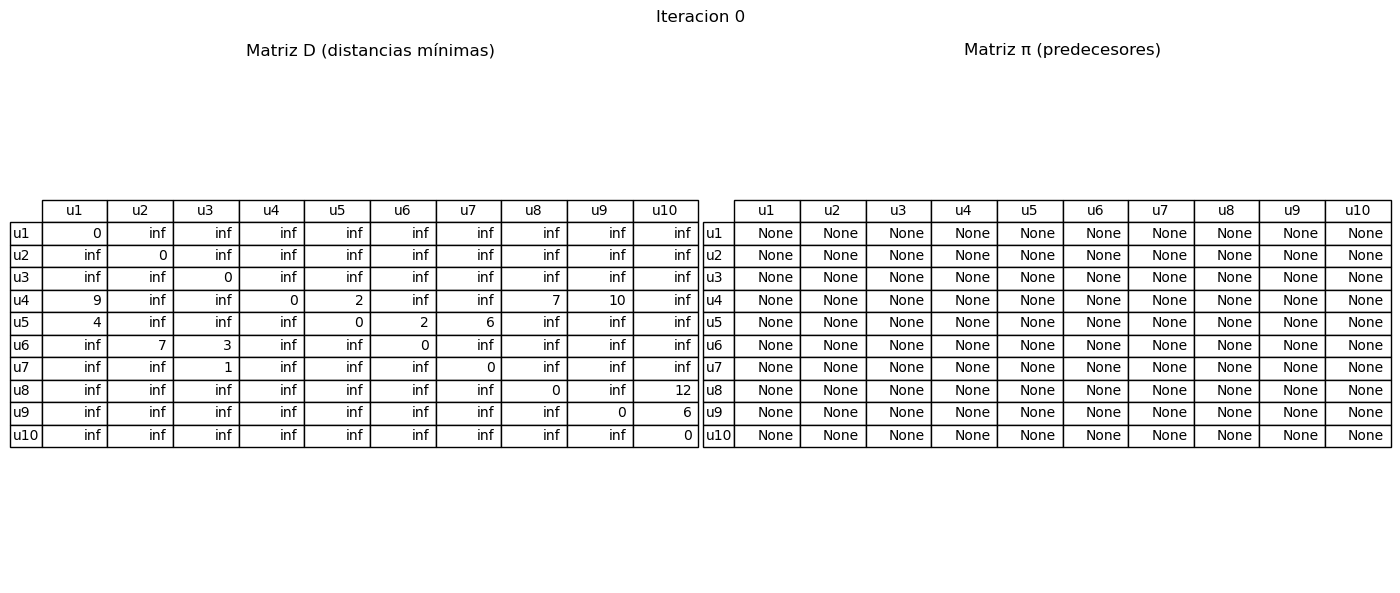

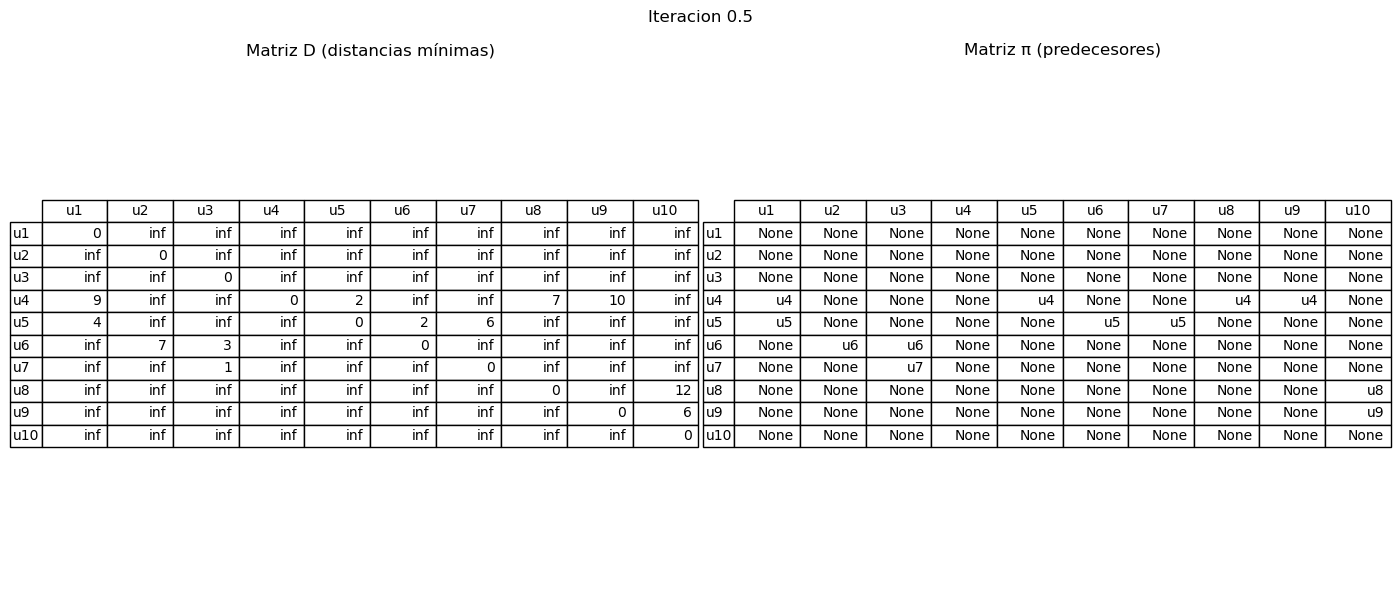

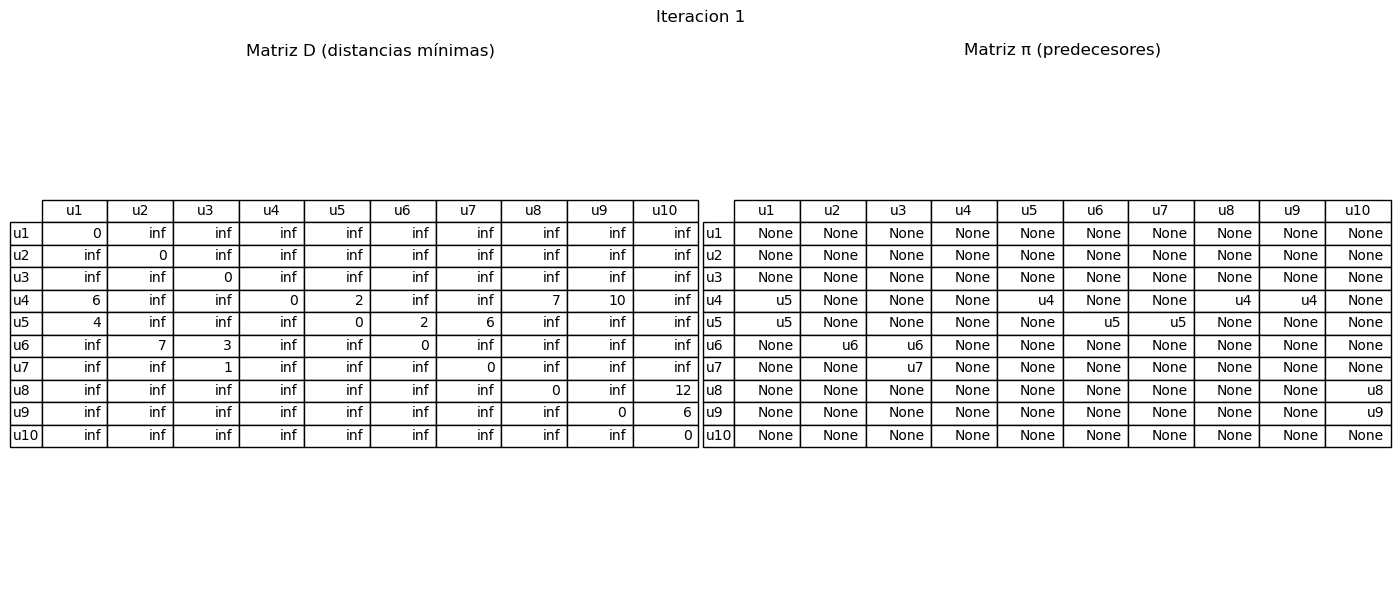

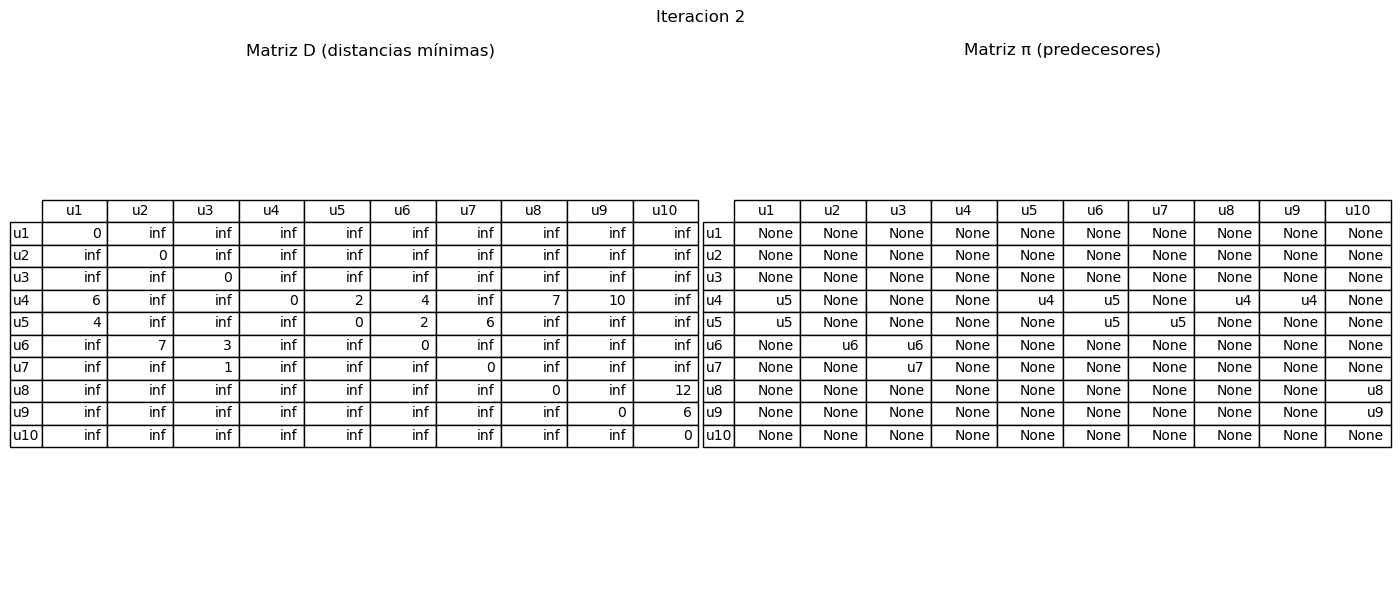

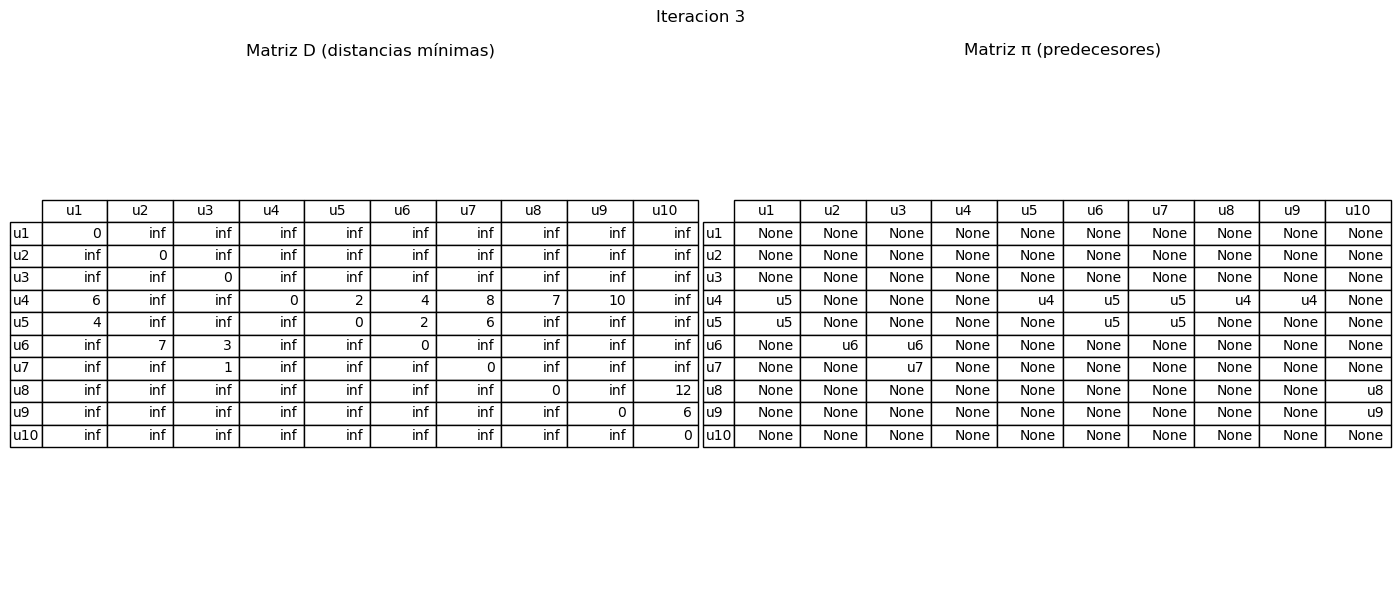

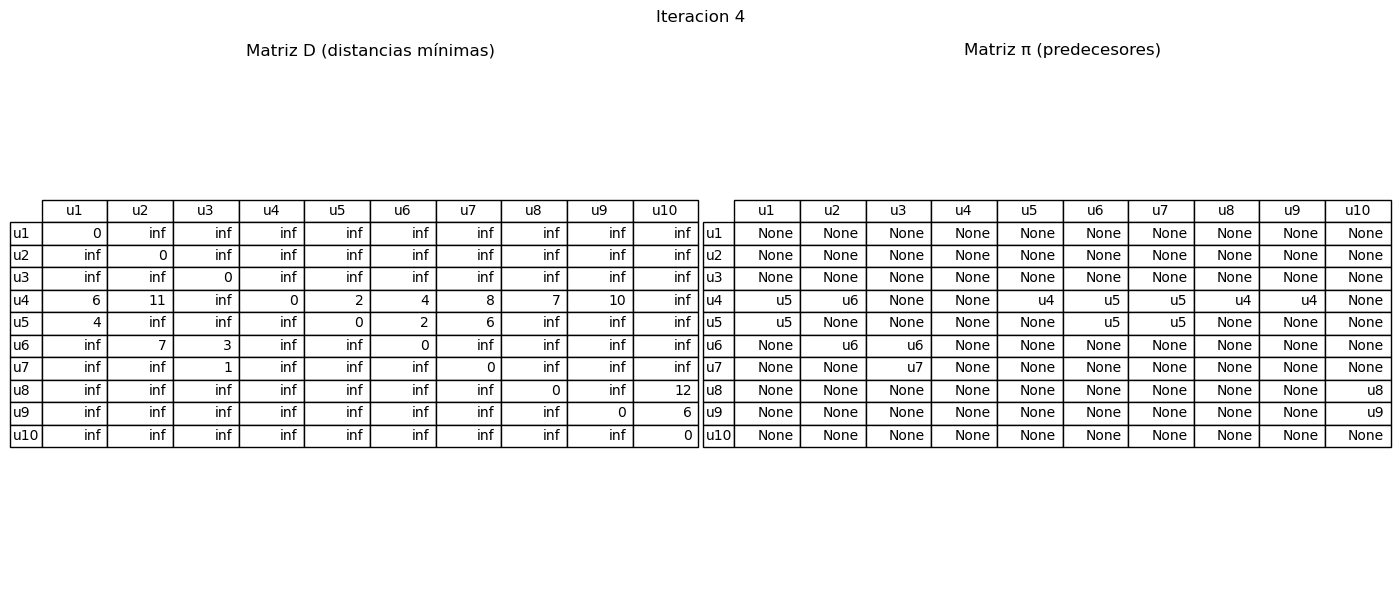

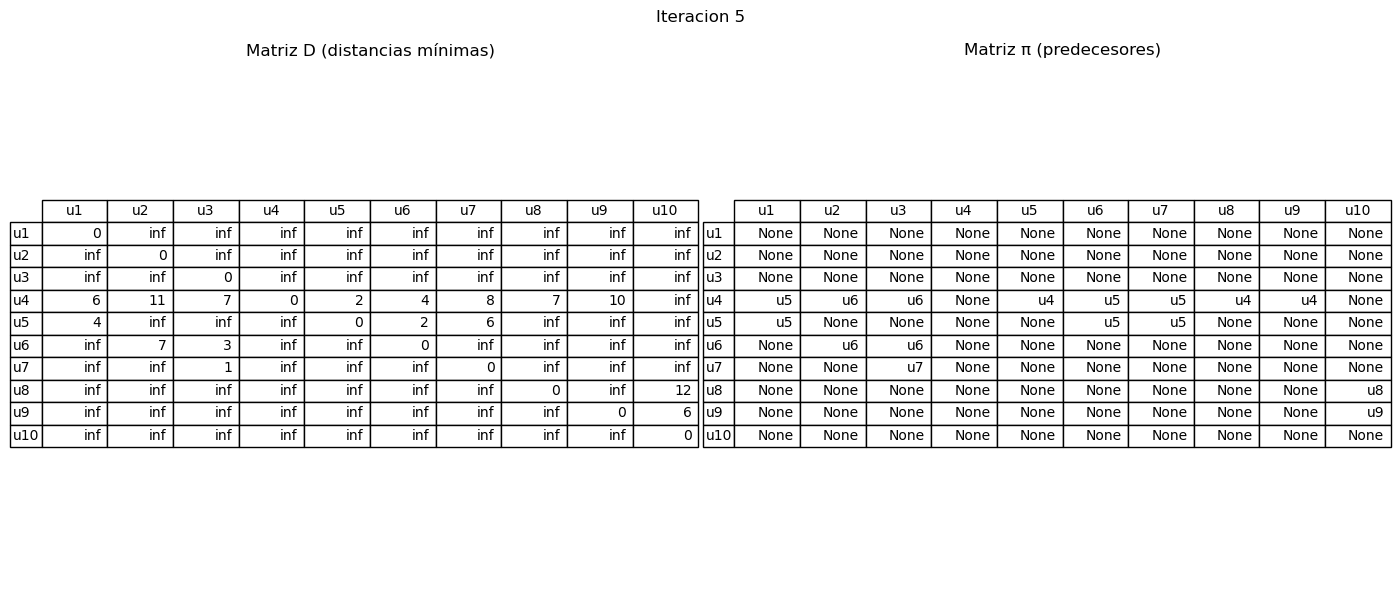

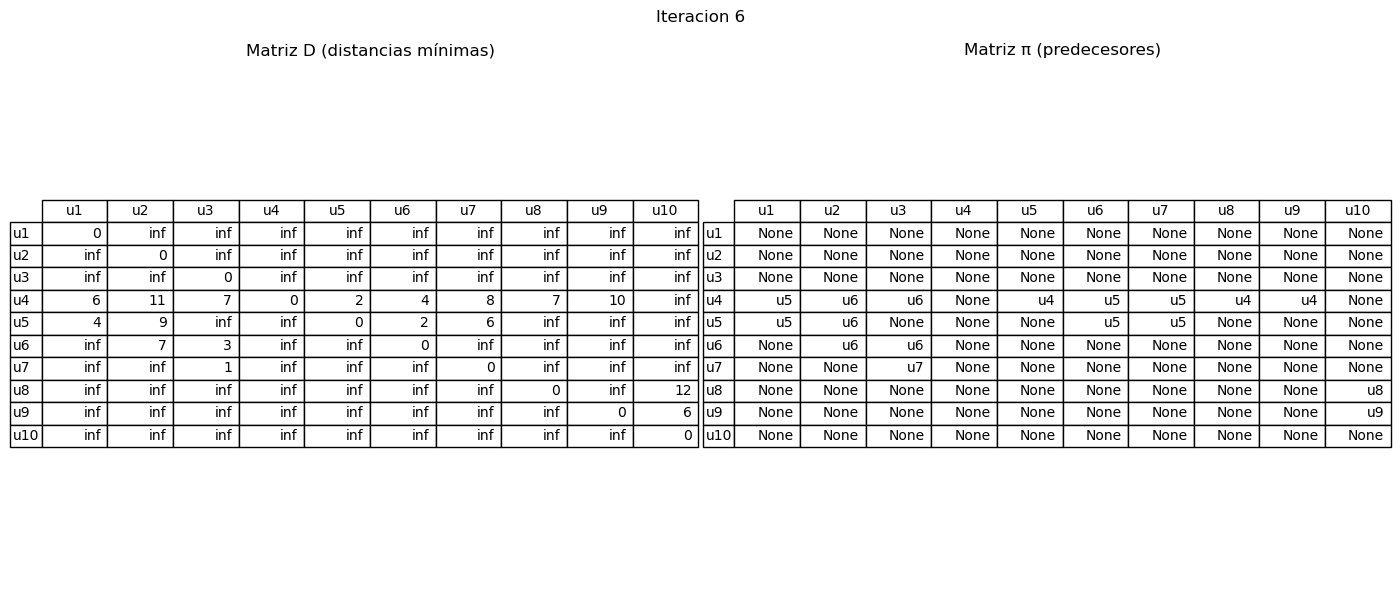

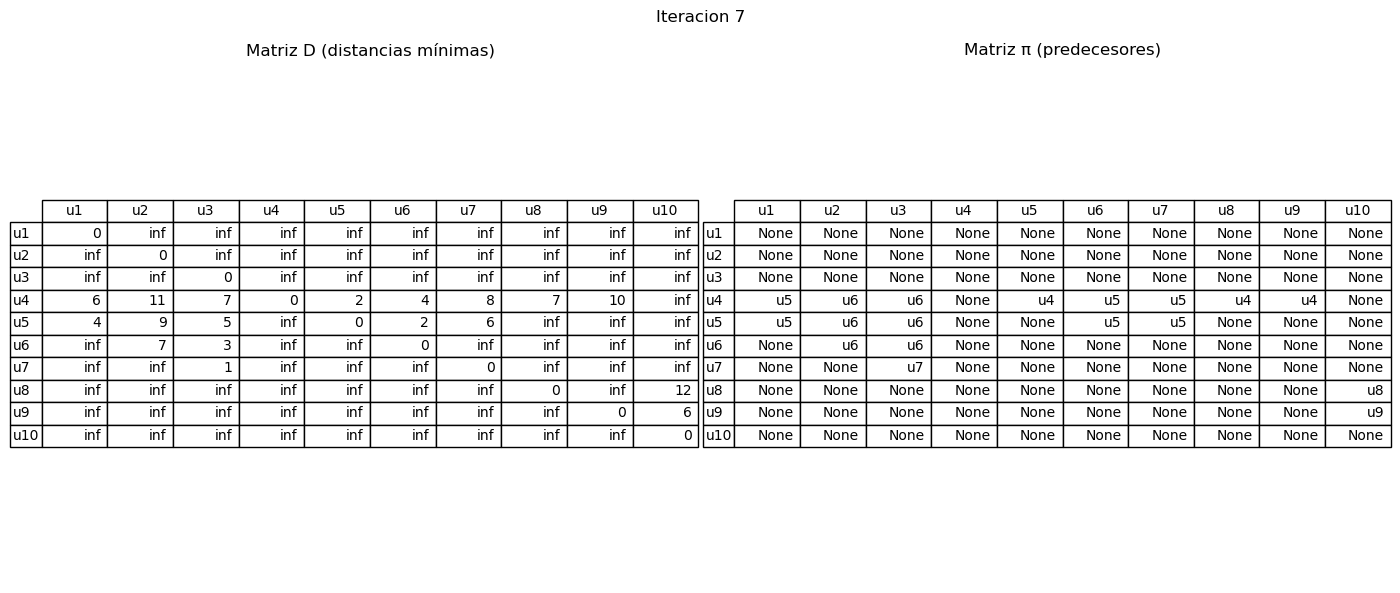

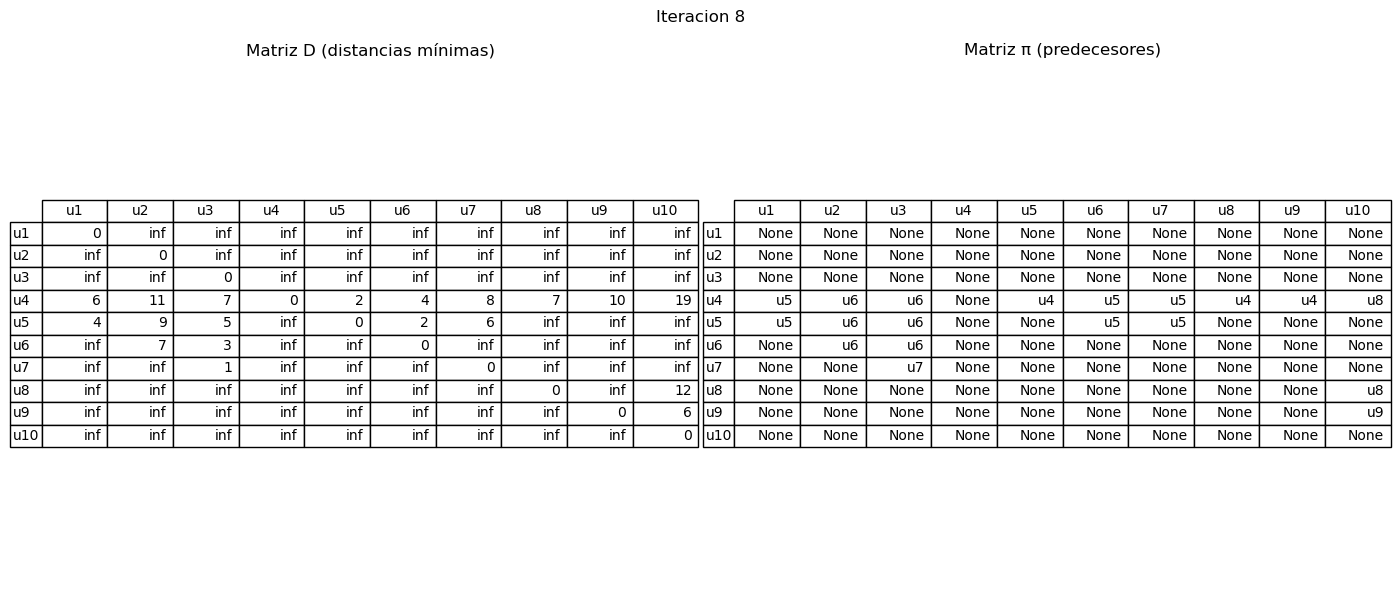

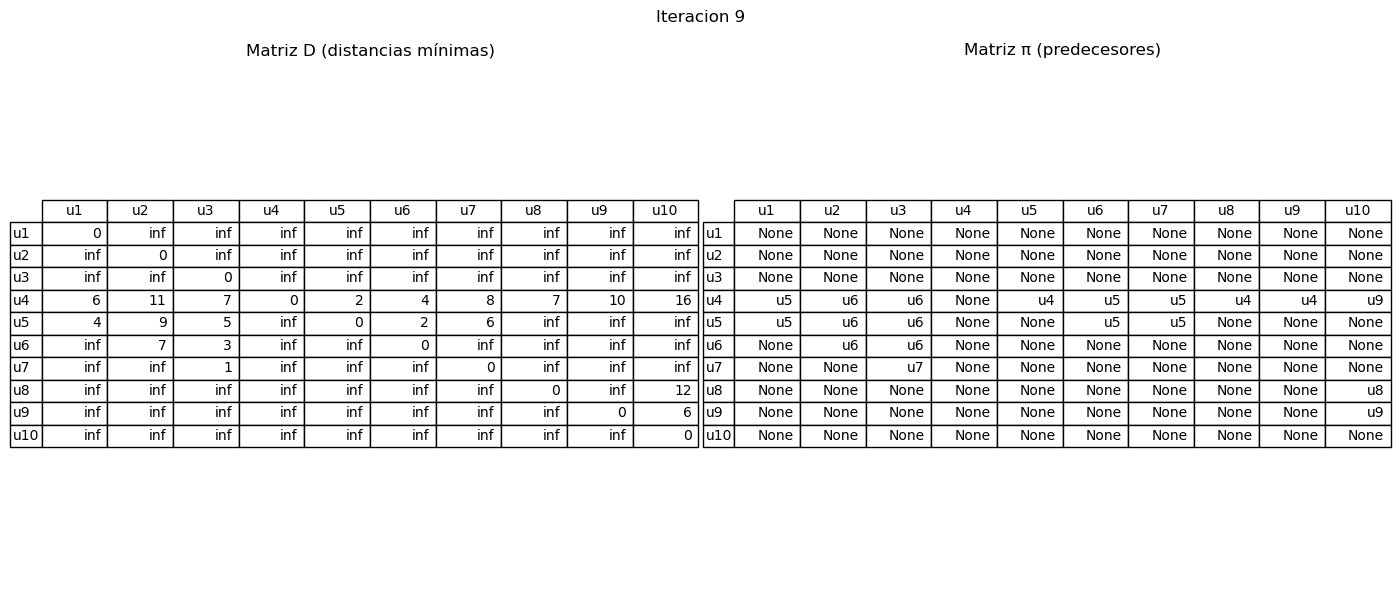

Matriz D (distancias mínimas):
[0, inf, inf, inf, inf, inf, inf, inf, inf, inf]
[inf, 0, inf, inf, inf, inf, inf, inf, inf, inf]
[inf, inf, 0, inf, inf, inf, inf, inf, inf, inf]
[6, 11, 7, 0, 2, 4, 8, 7, 10, 16]
[4, 9, 5, inf, 0, 2, 6, inf, inf, inf]
[inf, 7, 3, inf, inf, 0, inf, inf, inf, inf]
[inf, inf, 1, inf, inf, inf, 0, inf, inf, inf]
[inf, inf, inf, inf, inf, inf, inf, 0, inf, 12]
[inf, inf, inf, inf, inf, inf, inf, inf, 0, 6]
[inf, inf, inf, inf, inf, inf, inf, inf, inf, 0]

Matriz π (predecesores):
[None, None, None, None, None, None, None, None, None, None]
[None, None, None, None, None, None, None, None, None, None]
[None, None, None, None, None, None, None, None, None, None]
['u5', 'u6', 'u6', None, 'u4', 'u5', 'u5', 'u4', 'u4', 'u9']
['u5', 'u6', 'u6', None, None, 'u5', 'u5', None, None, None]
[None, 'u6', 'u6', None, None, None, None, None, None, None]
[None, None, 'u7', None, None, None, None, None, None, None]
[None, None, None, None, None, None, None, None, None, 'u8']

In [16]:
D, pi = floyd_warshall_with_pi(W,V)

print("Matriz D (distancias mínimas):")
for fila in D:
    print(fila)

print("\nMatriz π (predecesores):")
for fila in pi:
    print(fila)

